**Import the useful packages** 

In [1]:
import numpy as np
import xarray as xr
import glob
import matplotlib.pyplot as plt
import os,sys
import pandas as pd
import itertools

# To avoid problems with tensorflow, add the following lines before importing it
#import os
#os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
#os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
#import tensorflow as tf
#from tensorflow import keras

# To avoid problems with nn_functions, add the following lines before importing it 
import sys
sys.path.insert(1, '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt')

#from nn_functions.constants import *
#import nn_functions.diagnostic_functions as diag
#import nn_functions.data_formatting as dfmt
#import nn_functions.postprocessing_functions as pp
#from nn_functions.constants import *

#import define_params 

# For plotting things on the polar stereographic grid with lat and lon coordinates 
import cartopy.crs as ccrs
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()

In [2]:
from functions import load_test_data_whole_sim, load_model_nn, load_normalisation_metrics, regression_analysis, load_results_nn, \
ticks_labels, plot_monthly_trend, RMSE_R2, std_range, twosigfig

**Set the filepaths to the input and output data** 

In [3]:
path_model = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/NN_models/'
path_norm_metrics = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/'

models = glob.glob(path_model + '*.keras')
histories = glob.glob(path_model + 'history*.csv')

#fp_all_data = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Training_data/whole_dataset_not_yet_normalised.csv'


**Look at the results of the Neural Network**

In [4]:
# Check to see which combinations are actually available...
fp_ref_pred = glob.glob(path_model + 'applied_nn' + '_small_slope_front_' + '*' + '_' + '' + \
                                        '*' + '_extrap_std' + '*' + '.csv')
for i in range(len(fp_ref_pred)):
    simulations = fp_ref_pred[i].split('_small_slope_front_')[1].split('.csv')[0].split('_all_sims_extrap_std_special_lc_')
    #if simulations[0].split('_')[0] in ('OPM026','OPM031', 'OPM0263', 'Christoph'):
    if simulations[0] in ('OPM026','OPM031', 'OPM0263', 'Christoph', 'OPM026_OPM0262', 'OPM026_OPM031', 'OPM026_Christoph',\
                         'OPM0263_OPM031','OPM0263_Christoph', 'OPM031_Christoph'):
        if simulations[1] in ('OPM026_whole_dataset','OPM031_whole_dataset', 'OPM0263_whole_dataset', 'Christoph_v2_whole_dataset'):
            print(fp_ref_pred[i].split('_small_slope_front_')[1].split('.csv')[0].split('_all_sims_extrap_std_special_lc_'))

['OPM026', 'OPM026_whole_dataset']
['OPM0263', 'Christoph_v2_whole_dataset']
['OPM026', 'Christoph_v2_whole_dataset']
['OPM0263', 'OPM031_whole_dataset']
['OPM031', 'OPM0263_whole_dataset']
['OPM026_OPM031', 'Christoph_v2_whole_dataset']
['OPM031', 'OPM026_whole_dataset']
['OPM026_Christoph', 'OPM031_whole_dataset']
['OPM026', 'OPM031_whole_dataset']
['Christoph', 'OPM031_whole_dataset']
['OPM0263', 'OPM026_whole_dataset']
['OPM026', 'OPM0263_whole_dataset']
['Christoph', 'OPM0263_whole_dataset']
['OPM031', 'OPM031_whole_dataset']
['OPM031', 'Christoph_v2_whole_dataset']
['Christoph', 'Christoph_v2_whole_dataset']


### **Start here if you want to look at results which have already been processed**

In [5]:
#this_collection_NN = 'OPM031'
#this_collection_apply = 'OPM031_whole_dataset'
#exp_name = 'slope_front'
#keep_all_runs = True
#mod_size = 'small'
#TS_opt = 'extrap'
#norm_method = 'std'
#verbose = 1
#annual_only = False
#annual_f = ''
#quick_check = True

In [6]:
df = \
    load_results_nn(this_collection_NN = 'OPM031', this_collection_apply = 'OPM031_whole_dataset', path_model = path_model)
print('RMSE = {:.2f} m/yr'.format(df[5]))

RMSE = 7.47 m/yr


In [7]:
df2 = \
    load_results_nn(this_collection_NN = 'OPM026', this_collection_apply = 'OPM026_whole_dataset', path_model = path_model)
print('RMSE = {:.2f} m/yr'.format(df2[5]))

RMSE = 0.89 m/yr


In [8]:
df3 = \
    load_results_nn(this_collection_NN = 'Christoph', this_collection_apply = 'Christoph_v2_whole_dataset', path_model = path_model)
print('RMSE = {:.2f} m/yr'.format(df3[5]))

RMSE = 1.68 m/yr


In [9]:
# Calculate the years and ticks for the x axis to label model year 
ticks = np.arange(np.min(np.unique(df2[0].year)), np.min(np.unique(df2[0].year)) + int(np.ceil(len(np.unique(df2[0].year))/10))*10, 10)
labels = np.arange(0, int(np.ceil(len(np.unique(df2[0].year))/10))*10, 10)

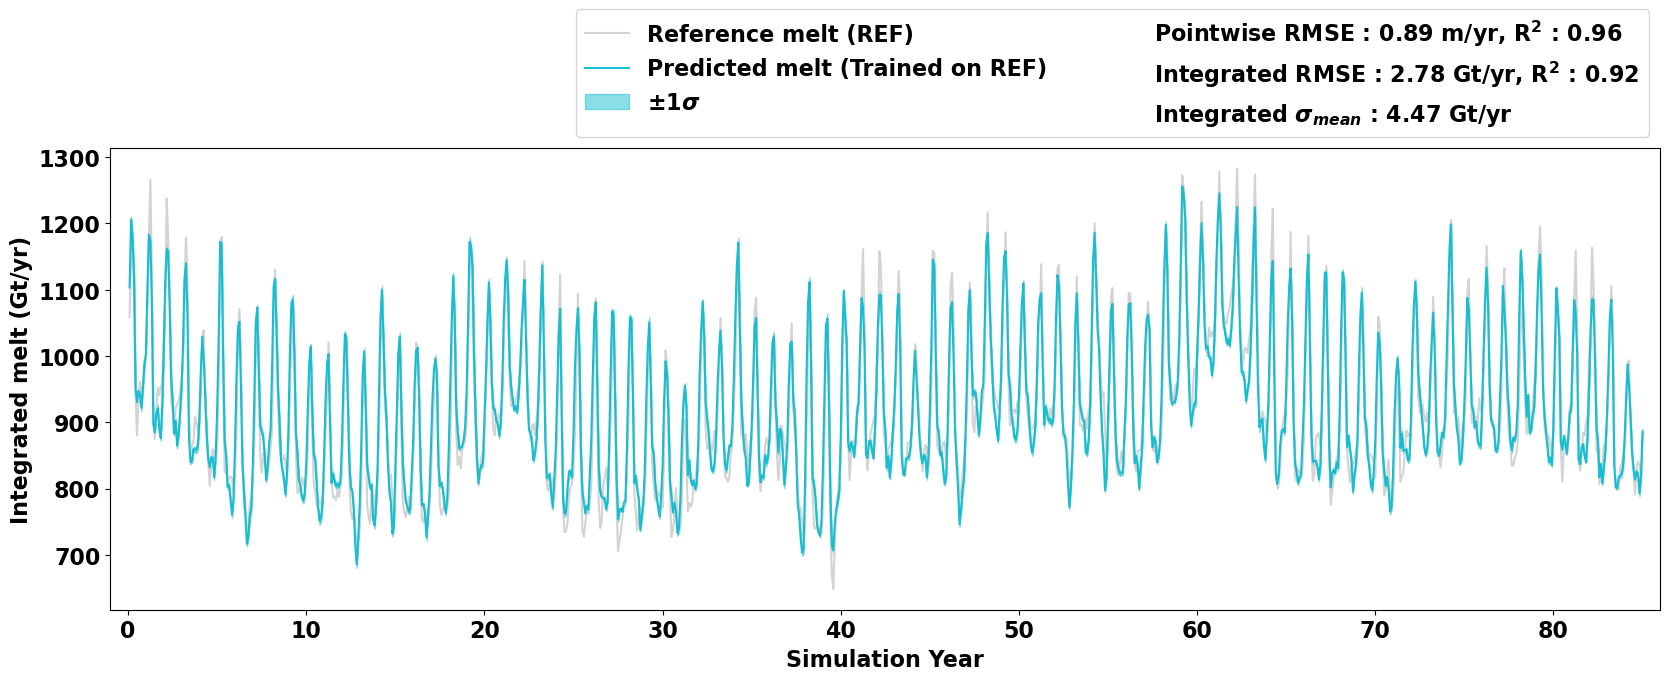

In [10]:
df_z = df2
RMSE = np.sqrt(np.mean((df_z[4].melt_Gt_per_y/12- df_z[4].melt_pred_Gt/12)**2))
R2 = regression_analysis(df_z[0].melt_m_ice_per_y, df_z[0].melt_pred_mean)[2]
R2_i = regression_analysis(df_z[4].melt_Gt_per_y/12, df_z[4].melt_pred_Gt/12)[2]
#ticks, labels = ticks_labels(df_z)    

with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, ax = plt.subplots(1,1, figsize = (20,6))
    ax.plot(df_z[4].year + df_z[4].month/12, -df_z[4].melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (REF)')
    ax.plot(df_z[4].year + df_z[4].month/12, -df_z[4].melt_pred_Gt, color = 'C9', label = 'Predicted melt (Trained on REF)')
    ax.fill_between(df_z[4].year + df_z[4].month/12, -df_z[4].melt_pred_Gt - df_z[4].std_Gt, \
                    -df_z[4].melt_pred_Gt + df_z[4].std_Gt, color = 'C9', alpha = 0.5, label = '$\\pm1\\sigma$')
    ax.scatter((1), (800), color = 'white', \
               label = "Pointwise RMSE : {:.2f} m/yr, R$^2$ : {:.2f} ".format(df_z[5], R2))
    ax.scatter((1), (800), color = 'white', \
               label = "Integrated RMSE : {:.2f} Gt/yr, R$^2$ : {:.2f} ".format(RMSE, R2_i))
    ax.scatter((1), (800), color = 'white', \
               label = "Integrated $\\sigma_{{mean}}$ : {:.2f} Gt/yr".format(df_z[4].std_Gt.mean()))
    ax.set_xlabel('Simulation Year', fontsize = 16)
    ax.set_ylabel('Integrated melt (Gt/yr)', fontsize = 16)
    ax.set_xlim(np.min(np.unique(df_z[0].year))-1, np.max(np.unique(df_z[0].year))+2)
    ax.set_xticks(ticks, labels)
    ax.legend(fontsize = 16, loc = 'lower right', bbox_to_anchor = [0,1,1,2], ncols = 2)
    plt.show()
    fig.savefig('FIGURES/Reference_experiment.pdf', bbox_inches = 'tight')
 #   ax.set_ylim(-9000,-500)

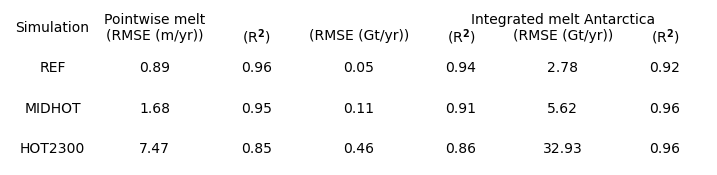

In [11]:
datasets = ('REF','MIDHOT','HOT2300')
titles =('Simulation', 'Pointwise melt\n(RMSE (m/yr))', '\n(R$^2$)', '\n(RMSE (Gt/yr))', '\n(R$^2$)', \
        'Integrated melt Antarctica\n(RMSE (Gt/yr))', '\n(R$^2$)') 
fig, ax = plt.subplots(4,7, figsize = (9,2))
df_s = (df2, df3, df)
for i, j in itertools.product(range(4), range(7)):
    ax[i,j].axis('off')
for i in range(len(datasets)):
    ax[i+1,0].annotate(datasets[i], xytext = (0.5,0.5), xy = (0.5,0.5), xycoords = 'axes fraction', va = 'center', ha = 'center')
    df_z = df_s[i]
    RMSE = df_z[5]
    RMSE_g = np.sqrt(np.mean((df_z[0].melt_Gt_per_y- df_z[0].melt_pred_Gt)**2))
    R2 = regression_analysis(df_z[0].melt_m_ice_per_y, df_z[0].melt_pred_mean)[2]
    R2_g = regression_analysis(df_z[0].melt_Gt_per_y, df_z[0].melt_pred_Gt)[2]
    ax[i+1,1].annotate('{:.2f}'.format(RMSE), xytext = (0.5,0.5), xy = (0.5,0.5), xycoords = 'axes fraction', va = 'center', ha = 'center')
    ax[i+1,2].annotate('{:.2f}'.format(R2), xytext = (0.5,0.5), xy = (0.5,0.5), xycoords = 'axes fraction', va = 'center', ha = 'center')
    ax[i+1,3].annotate('{:.2f}'.format(RMSE_g), xytext = (0.5,0.5), xy = (0.5,0.5), xycoords = 'axes fraction', va = 'center', ha = 'center')
    ax[i+1,4].annotate('{:.2f}'.format(R2_g), xytext = (0.5,0.5), xy = (0.5,0.5), xycoords = 'axes fraction', va = 'center', ha = 'center')
    RMSE = np.sqrt(np.mean((df_z[4].melt_Gt_per_y/12- df_z[4].melt_pred_Gt/12)**2))
    R2 = regression_analysis(df_z[4].melt_Gt_per_y/12, df_z[4].melt_pred_Gt/12)[2]
    ax[i+1,5].annotate('{:.2f}'.format(RMSE), xytext = (0.5,0.5), xy = (0.5,0.5), xycoords = 'axes fraction', va = 'center', ha = 'center')
    ax[i+1,6].annotate('{:.2f}'.format(R2), xytext = (0.5,0.5), xy = (0.5,0.5), xycoords = 'axes fraction', va = 'center', ha = 'center')
for i in range(7):
    ax[0,i].annotate(titles[i], xytext = (0.5,0.5), xy = (0.5,0.5), xycoords = 'axes fraction', va = 'center', ha = 'center')
plt.show()

In [12]:
df_an = \
    load_results_nn(this_collection_NN = 'OPM026_annual', this_collection_apply = 'OPM031_whole_dataset', path_model = path_model, \
                   load_ym_only = True)

In [13]:
#df = \
#    load_results_nn(this_collection_NN = 'OPM031', this_collection_apply = 'OPM031_whole_dataset', path_model = path_model, \
#                   load_ym_only = True)

In [14]:
df2 = \
    load_results_nn(this_collection_NN = 'OPM026', this_collection_apply = 'OPM031_whole_dataset', path_model = path_model, \
                   load_ym_only = True)

In [15]:
df_anc = \
    load_results_nn(this_collection_NN = 'Christoph_annual', this_collection_apply = 'OPM031_whole_dataset', path_model = path_model, \
                   load_ym_only = True)

In [16]:
df_c = \
    load_results_nn(this_collection_NN = 'Christoph', this_collection_apply = 'OPM031_whole_dataset', path_model = path_model, \
                   load_ym_only = True)

In [17]:
#df_an31 = \
#    load_results_nn(this_collection_NN = 'OPM031_annual', this_collection_apply = 'OPM031_whole_dataset', path_model = path_model, \
#                   load_ym_only = True)

(391.3935629939098, 9380.735177127894)


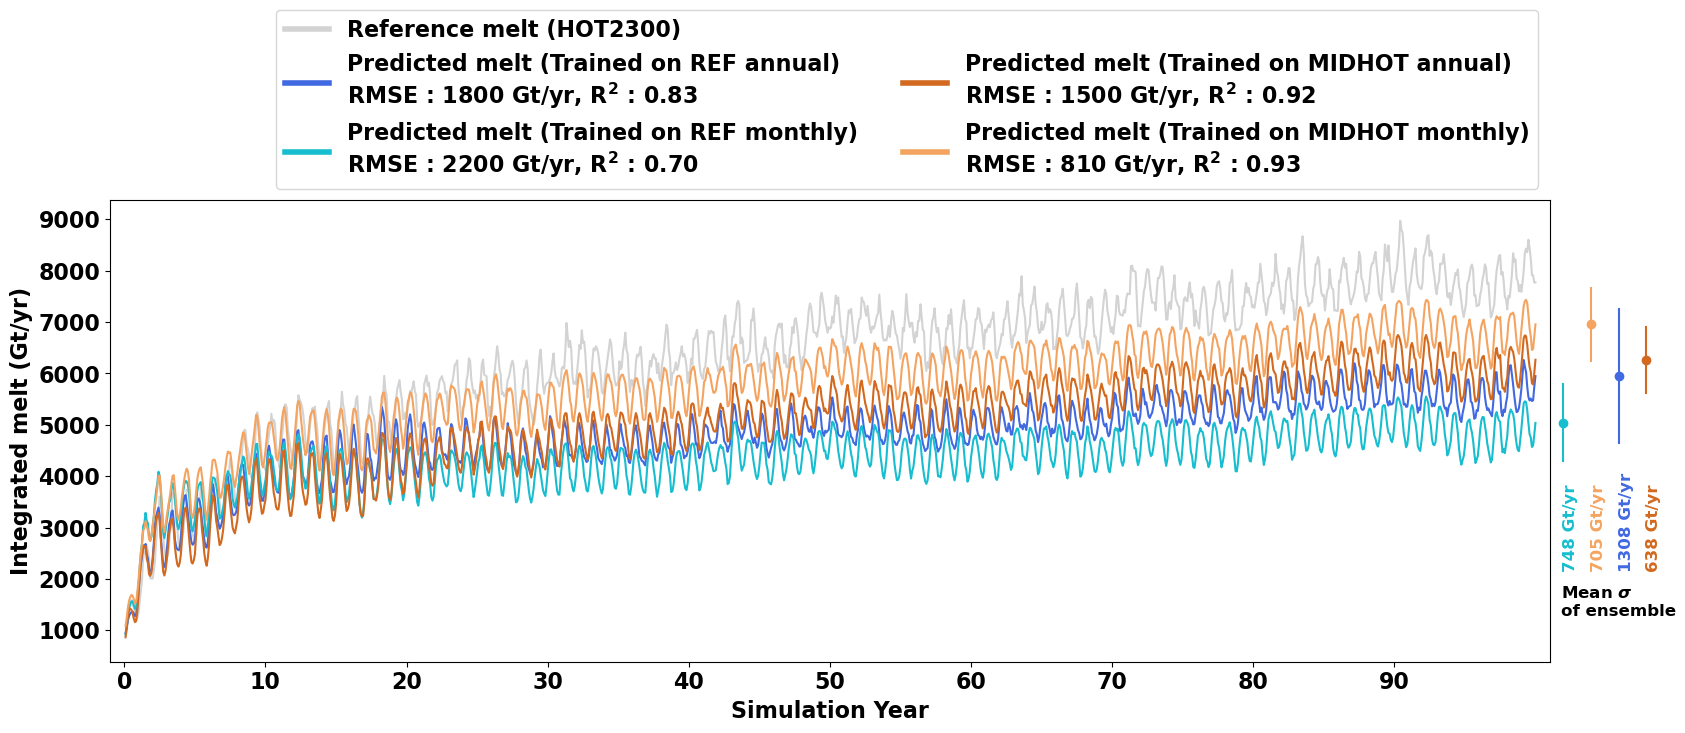

In [18]:
df_z = df_an
#RMSE = np.sqrt(np.mean((df_z[4].melt_Gt_per_y- df_z[4].melt_pred_Gt)**2))
#R2 = regression_analysis(df_z[0].melt_m_ice_per_y, df_z[0].melt_pred_mean)[2]
#R2_i = regression_analysis(df_z[4].melt_Gt_per_y, df_z[4].melt_pred_Gt)[2]
ticks, labels = ticks_labels(df_z)    

with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, axs = plt.subplots(1,2, figsize = (20,6), width_ratios = (19.5,1.5))
    fig.subplots_adjust(wspace=0, hspace=0)
    ax = axs[0]
    df_z = df_an
    ax.plot(df_z.year + df_z.month/12, -df_z.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (HOT2300)')
    plot_monthly_trend(df_an, 'royalblue', label = 'Predicted melt (Trained on REF annual)', ax = ax, std = False, label_std = '$\\pm1\\sigma$')
    plot_monthly_trend(df2, 'C9', label = 'Predicted melt (Trained on REF monthly)', ax = ax, std = False, label_std = '$\\pm1\\sigma$')
    ax.scatter((1), (800), color = 'white', \
               label = " ")
    plot_monthly_trend(df_anc, 'chocolate', label = 'Predicted melt (Trained on MIDHOT annual)', ax = ax, \
                       std = False, label_std = '$\\pm1\\sigma$', flip = True)
    plot_monthly_trend(df_c, 'sandybrown', label = 'Predicted melt (Trained on MIDHOT monthly)', ax = ax,\
                       std = False, label_std = '$\\pm1\\sigma$', flip = True)
    #ax.scatter((1), (800), color = 'white', \
    #           label = "Pointwise RMSE : {:.2f} m/yr, R$^2$ : {:.2f} ".format(df_z[5], R2))
    #ax.scatter((1), (800), color = 'white', \
    #           label = "Integrated RMSE : {:.2f} Gt/yr, R$^2$ : {:.2f} ".format(RMSE, R2_i))
    #ax.scatter((1), (800), color = 'white', \
    #           label = "Integrated $\\sigma_{{mean}}$ : {:.2f} Gt/yr".format(df_z[4].std_Gt.mean()))
    ax.set_xlabel('Simulation Year', fontsize = 16)
    ax.set_ylabel('Integrated melt (Gt/yr)', fontsize = 16)
    ax.set_xlim(np.min(np.unique(df_z.year))-1, np.max(np.unique(df_z.year))+2)
    ax.set_xticks(ticks, labels)
    leg = ax.legend(fontsize = 16, loc = 'lower right', bbox_to_anchor = [0,1,1,2], ncols = 2)
    for line in leg.get_lines():
        line.set_linewidth(4.0)
    ylims = ax.get_ylim()
    print(ylims)
    #ax.set_ylim(6000,8000)
    #ax.set_xlim(np.min(np.unique(df_z.year))+60,None)

    ax = axs[1]
    ax.axis('off')
    std_range(df2, 'C9', 1, 4, ax = ax)
    std_range(df_c, 'sandybrown', 2,4, ax = ax, flip = True)
    std_range(df_an, 'royalblue', 3,4, ax = ax)
    std_range(df_anc, 'chocolate', 4,4, ax = ax, flip = True)
    ax.set_ylim(ylims)
    ax.set_xlim(0,1)

    ax.annotate('Mean $\\sigma$\nof ensemble'.format(np.mean(df_z.std_Gt)), xytext = (0.1,0.1), \
                xy = (0.5,0.5), xycoords = 'axes fraction', \
                fontsize = 12)
    
    plt.show()
    fig.savefig('FIGURES/Monthly_or_Annual.pdf', bbox_inches = 'tight')
 #   ax.set_ylim(-9000,-500)

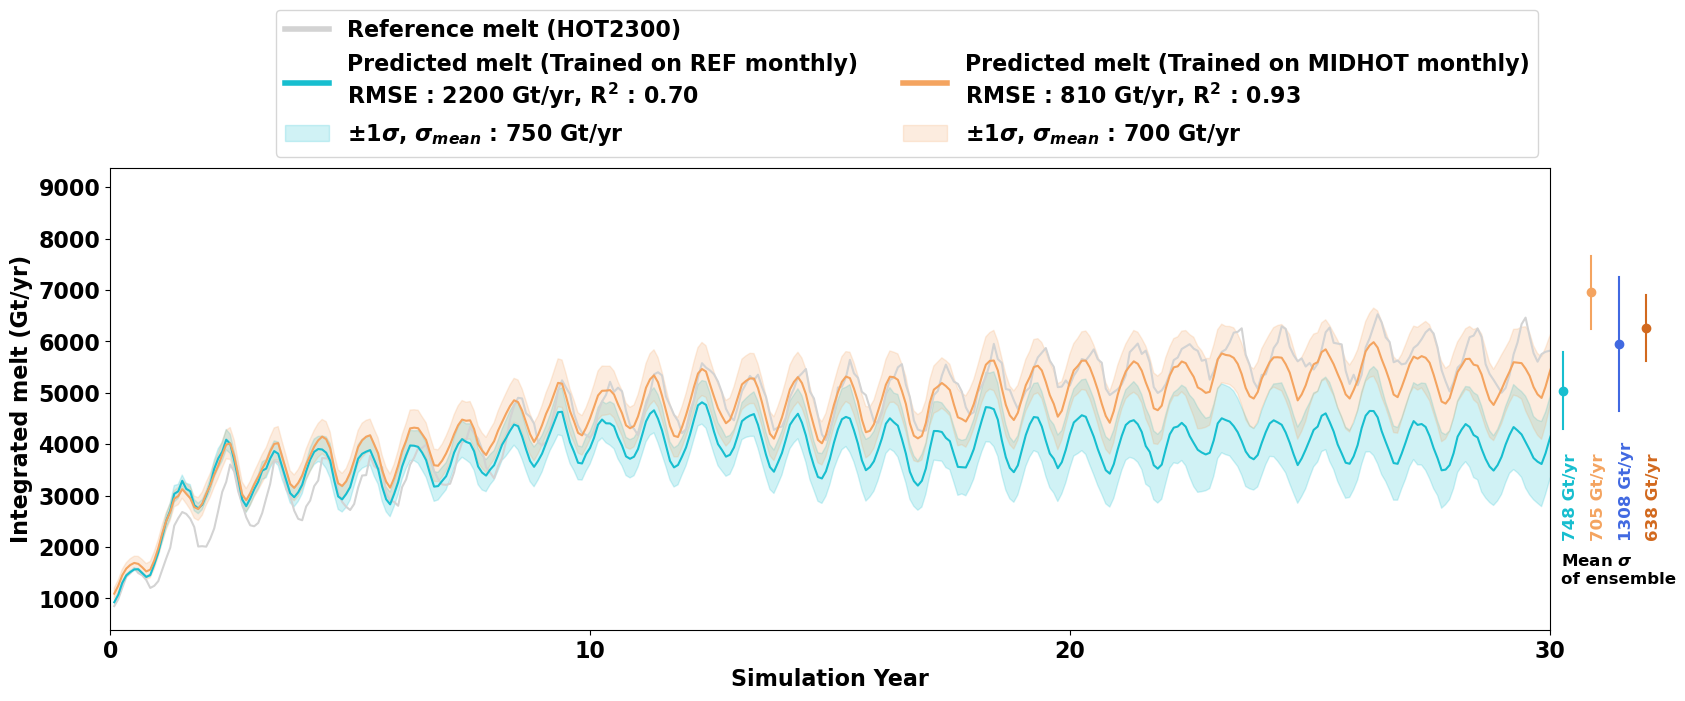

In [19]:
df_z = df_an
#RMSE = np.sqrt(np.mean((df_z[4].melt_Gt_per_y- df_z[4].melt_pred_Gt)**2))
#R2 = regression_analysis(df_z[0].melt_m_ice_per_y, df_z[0].melt_pred_mean)[2]
#R2_i = regression_analysis(df_z[4].melt_Gt_per_y, df_z[4].melt_pred_Gt)[2]
ticks, labels = ticks_labels(df_z)    

with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, axs = plt.subplots(1,2, figsize = (20,6), width_ratios = (19.5,1.5))
    fig.subplots_adjust(wspace=0, hspace=0)
    ax = axs[0]
    df_z = df_an
    ax.plot(df_z.year + df_z.month/12, -df_z.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (HOT2300)')
    plot_monthly_trend(df2, 'C9', label = 'Predicted melt (Trained on REF monthly)', ax = ax, std = True, label_std = '$\\pm1\\sigma$')
    ax.scatter((1), (800), color = 'white', \
               label = " ")
    plot_monthly_trend(df_c, 'sandybrown', label = 'Predicted melt (Trained on MIDHOT monthly)', ax = ax, \
                       std = True, label_std = '$\\pm1\\sigma$', flip = True)
    ax.set_xlabel('Simulation Year', fontsize = 16)
    ax.set_ylabel('Integrated melt (Gt/yr)', fontsize = 16)
    ax.set_xlim(np.min(np.unique(df_z.year))-1, np.max(np.unique(df_z.year))+2)
    ax.set_xticks(ticks, labels)
    leg = ax.legend(fontsize = 16, loc = 'lower right', bbox_to_anchor = [0,1,1,2], ncols = 2)
    for line in leg.get_lines():
        line.set_linewidth(4.0)
    ylims = ax.get_ylim()
    ax.set_xlim(np.min(np.unique(df_z.year)),np.min(np.unique(df_z.year))+ 30)
    
    ax = axs[1]
    ax.axis('off')
    std_range(df2, 'C9', 1, 4, ax = ax)
    std_range(df_c, 'sandybrown', 2,4, ax=ax, flip = True)
    std_range(df_an, 'royalblue', 3,4, ax = ax)
    std_range(df_anc, 'chocolate', 4,4, ax = ax, flip = True)
    ax.set_ylim(ylims)
    ax.set_xlim(0,1)

    ax.annotate('Mean $\\sigma$\nof ensemble'.format(np.mean(df_z.std_Gt)), xytext = (0.1,0.1), \
                xy = (0.5,0.5), xycoords = 'axes fraction', \
                fontsize = 12)
    
    plt.show()
    fig.savefig('FIGURES/Monthly_or_Annual.pdf', bbox_inches = 'tight')
 #   ax.set_ylim(-9000,-500)

In [20]:
df_an26 = \
    load_results_nn(this_collection_NN = 'OPM026_annual', this_collection_apply = 'Christoph_v2_whole_dataset', path_model = path_model, \
                   load_ym_only = True)

In [21]:
df_mn26 = \
    load_results_nn(this_collection_NN = 'OPM026', this_collection_apply = 'Christoph_v2_whole_dataset', path_model = path_model, \
                   load_ym_only = True)

In [22]:
df_mn31 = \
    load_results_nn(this_collection_NN = 'OPM031', this_collection_apply = 'Christoph_v2_whole_dataset', path_model = path_model, \
                   load_ym_only = True)

In [23]:
df_an31 = \
    load_results_nn(this_collection_NN = 'OPM031_annual', this_collection_apply = 'Christoph_v2_whole_dataset', path_model = path_model, \
                   load_ym_only = True)

(697.9596674955063, 2942.846982594366)


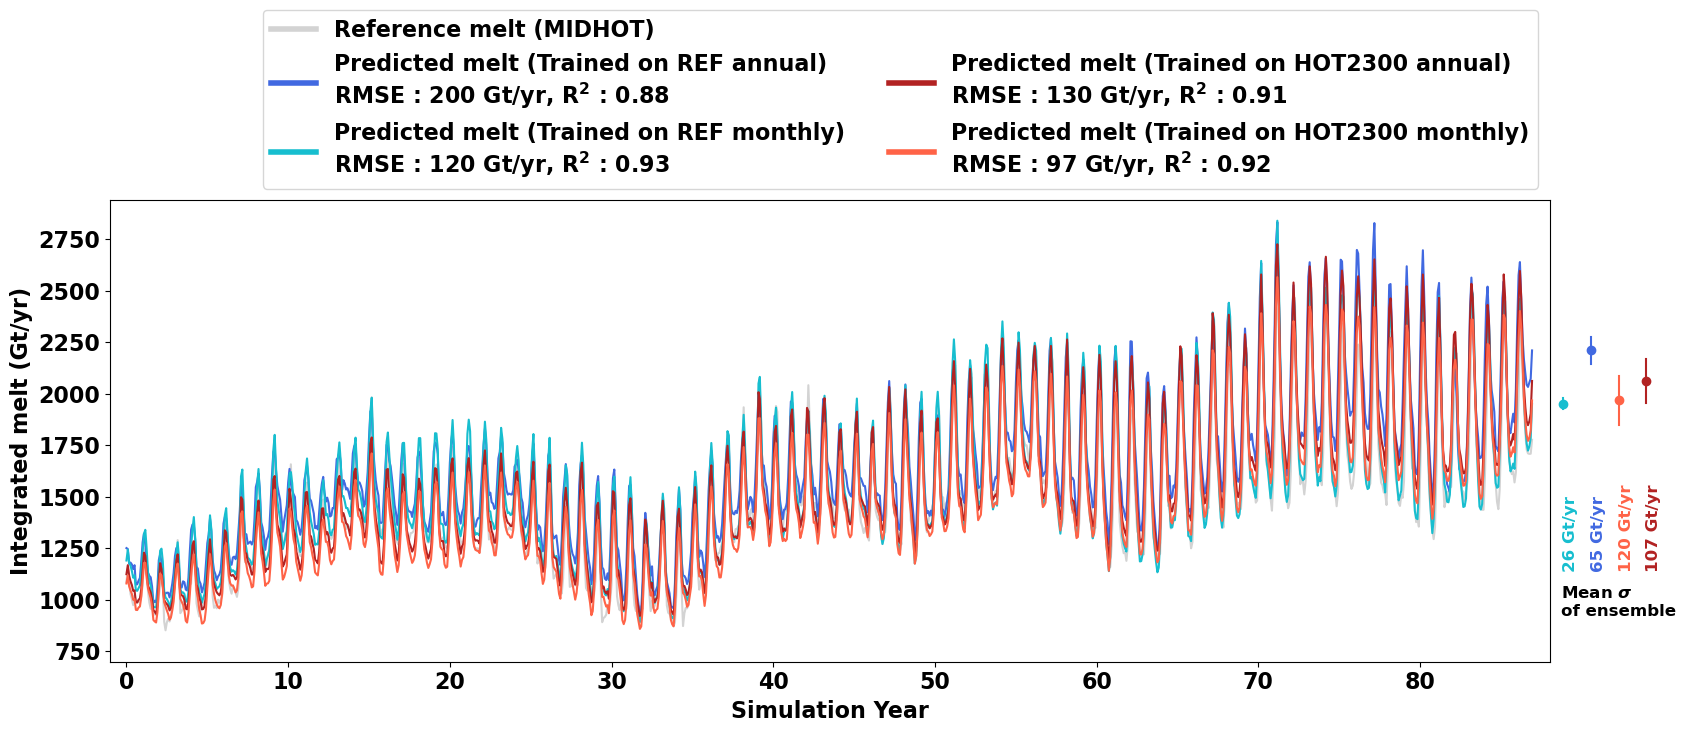

In [24]:
df_z = df_an26
#RMSE = np.sqrt(np.mean((df_z[4].melt_Gt_per_y- df_z[4].melt_pred_Gt)**2))
#R2 = regression_analysis(df_z[0].melt_m_ice_per_y, df_z[0].melt_pred_mean)[2]
#R2_i = regression_analysis(df_z[4].melt_Gt_per_y, df_z[4].melt_pred_Gt)[2]
ticks, labels = ticks_labels(df_z)    

with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, axs = plt.subplots(1,2, figsize = (20,6), width_ratios = (19.5,1.5))
    fig.subplots_adjust(wspace=0, hspace=0)
    ax = axs[0]
    df_z = df_an26
    ax.plot(df_z.year + df_z.month/12, df_z.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (MIDHOT)', zorder = 0)
    plot_monthly_trend(df_an26, 'royalblue', label = 'Predicted melt (Trained on REF annual)', ax = ax, \
                       std = False, label_std = '$\\pm1\\sigma$', flip = 'second')
    plot_monthly_trend(df_mn26, 'C9', label = 'Predicted melt (Trained on REF monthly)', ax = ax, \
                       std = False, label_std = '$\\pm1\\sigma$', flip = 'second')
    ax.scatter((1), (800), color = 'white', \
               label = " ")
    plot_monthly_trend(df_an31, 'firebrick', label = 'Predicted melt (Trained on HOT2300 annual)', ax= ax, \
                       std = False, label_std = '$\\pm1\\sigma$', flip = 'second')
    plot_monthly_trend(df_mn31, 'tomato', label = 'Predicted melt (Trained on HOT2300 monthly)', ax = ax, \
                       std = False, label_std = '$\\pm1\\sigma$', flip = 'second')
    ax.set_xlabel('Simulation Year', fontsize = 16)
    ax.set_ylabel('Integrated melt (Gt/yr)', fontsize = 16)
    ax.set_xlim(np.min(np.unique(df_z.year))-1, np.max(np.unique(df_z.year))+2)
    ax.set_xticks(ticks, labels)
    leg = ax.legend(fontsize = 16, loc = 'lower right', bbox_to_anchor = [0,1,1,2], ncols = 2)
    for line in leg.get_lines():
        line.set_linewidth(4.0)
    ylims = ax.get_ylim()
    print(ylims)
    #ax.set_ylim(6000,8000)
    #ax.set_xlim(np.min(np.unique(df_z.year))+60,None)

    ax = axs[1]
    ax.axis('off')
    std_range(df_mn26, 'C9', 1, 4, ax = ax)
    std_range(df_an26, 'royalblue', 2,4, ax = ax)
    std_range(df_mn31, 'tomato', 3, 4, ax = ax)
    std_range(df_an31, 'firebrick', 4, 4, ax = ax)
    ax.set_ylim(ylims)
    ax.set_xlim(0,1)

    ax.annotate('Mean $\\sigma$\nof ensemble'.format(np.mean(df_z.std_Gt)), xytext = (0.1,0.1), \
                xy = (0.5,0.5), xycoords = 'axes fraction', \
                fontsize = 12)
    
    plt.show()
    #fig.savefig('FIGURES/Monthly_or_Annual.pdf', bbox_inches = 'tight')
 #   ax.set_ylim(-9000,-500)

In [25]:
df_ANT2100 = pd.DataFrame({
    'year': df_an26.year - np.min(df_an26.year), 
    'month': df_an26.month,
    'melt_m_ice_per_y': df_an26.melt_Gt_per_y.values,
    'melt_an26': -df_an26.melt_pred_Gt.values,
    'melt_mn26': -df_mn26.melt_pred_Gt.values,
    'melt_an31': -df_an31.melt_pred_Gt.values,
    'melt_mn31': -df_mn31.melt_pred_Gt.values,
    'std_an26': np.mean(df_an26.std_Gt.values),
    'std_mn26': np.mean(df_mn26.std_Gt.values),
    'std_an31': np.mean(df_an31.std_Gt.values),
    'std_mn31': np.mean(df_mn31.std_Gt.values),
})
df_ANT2300 = pd.DataFrame({
    'year': df_an.year - np.min(df_an.year), 
    'month': df_an.month,
    'melt_m_ice_per_y': -df_an.melt_Gt_per_y.values,
    'melt_an26': -df_an.melt_pred_Gt.values,
    'melt_mn26': -df2.melt_pred_Gt.values,
    'melt_anc': df_anc.melt_pred_Gt.values,
    'melt_mnc': df_c.melt_pred_Gt.values,
    'std_an26': np.mean(df_an.std_Gt.values),
    'std_mn26': np.mean(df2.std_Gt.values),
    'std_anc': np.mean(df_anc.std_Gt.values),
    'std_mnc': np.mean(df_c.std_Gt.values),
})

In [26]:
fp_data = 'Figure_data/'
df_ANT2100.to_csv(fp_data + 'df_ANT2100.csv', index = False)
df_ANT2300.to_csv(fp_data + 'df_ANT2300.csv', index = False)
df_ANT2100 = pd.read_csv(fp_data+ 'df_ANT2100.csv')
df_ANT2300 = pd.read_csv(fp_data+ 'df_ANT2300.csv')

In [27]:
def std_range(melt, std, color, position, total, ax):
    fraction = (-1/(2*total))+(position/total)
    ax.scatter(fraction, melt[-1], color = color)
    ax.plot((fraction,fraction), \
           (melt[-1]+ std[0], melt[-1] - std[0]), 
           color = color)
    ax.annotate('{:.0f} Gt/yr'.format(std[0]), xytext = (fraction,0.2), xy = (0.5,0.5), xycoords = 'axes fraction', \
                rotation = 90, fontsize = 12, color = color)


In [28]:
std = df_ANT2100.std_an31.values
std

array([107.35669755, 107.35669755, 107.35669755, ..., 107.35669755,
       107.35669755, 107.35669755])

(697.9596674955063, 2942.846982594366)
(391.3935629939098, 9380.735177127894)


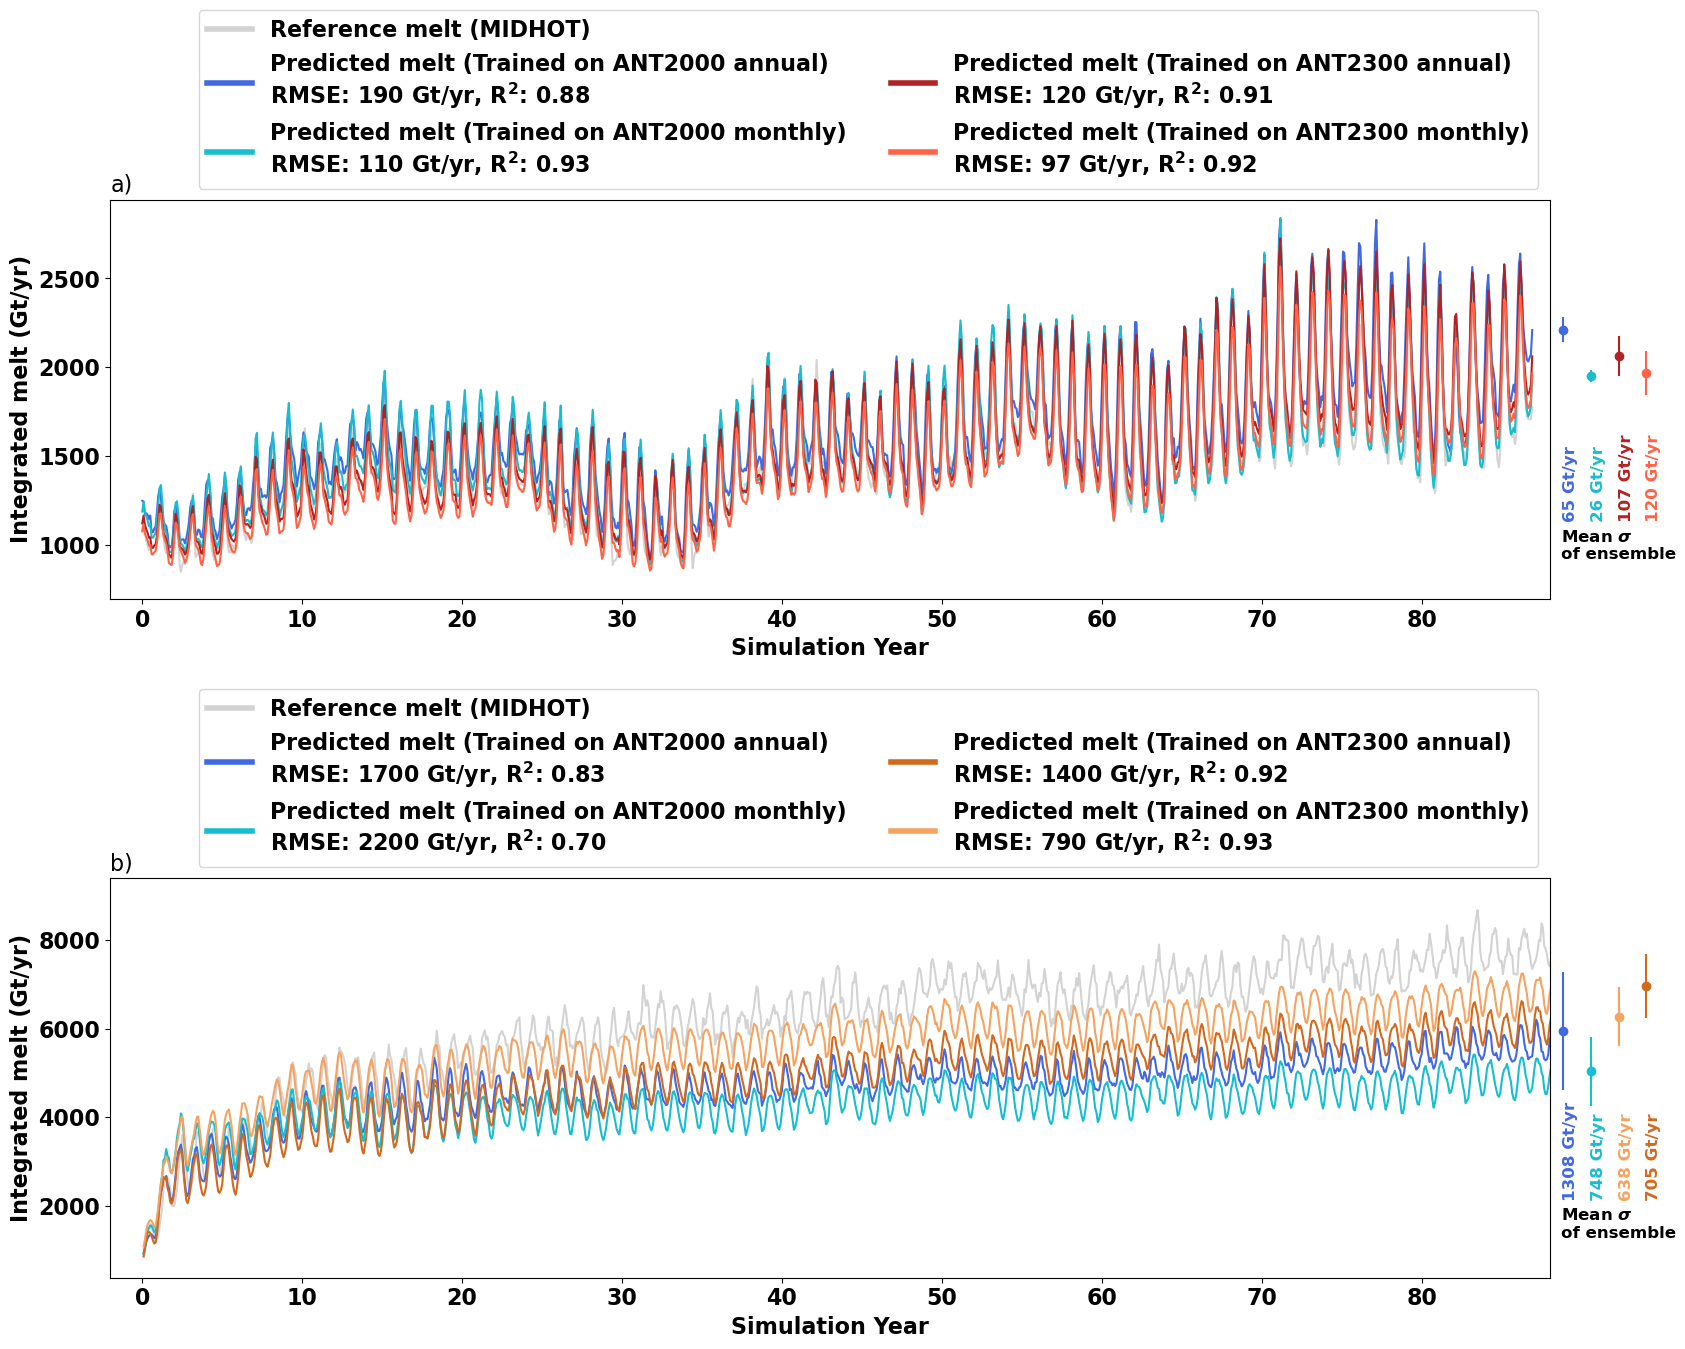

In [29]:
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, axs = plt.subplots(2,2, figsize = (20,14), width_ratios = (19.5,1.5))
    fig.subplots_adjust(wspace=0, hspace = 0.7)

    ax = axs[0,0]
    ax.plot(df_ANT2100.year + df_ANT2100.month/12, df_ANT2100.melt_m_ice_per_y, color = 'lightgrey', \
           label = 'Reference melt (MIDHOT)')
    RMSE = twosigfig(np.sqrt(np.mean((df_ANT2100.melt_m_ice_per_y - df_ANT2100.melt_an26)**2)))
    R2 = twosigfig(regression_analysis(df_ANT2100.melt_m_ice_per_y, df_ANT2100.melt_an26)[2])
    ax.plot(df_ANT2100.year + df_ANT2100.month/12, df_ANT2100.melt_an26, color = 'royalblue', \
           label = 'Predicted melt (Trained on ANT2000 annual)\nRMSE: {} Gt/yr, R$^2$: {}'.format(RMSE, R2))
    RMSE = twosigfig(np.sqrt(np.mean((df_ANT2100.melt_m_ice_per_y - df_ANT2100.melt_mn26)**2)))
    R2 = twosigfig(regression_analysis(df_ANT2100.melt_m_ice_per_y, df_ANT2100.melt_mn26)[2])
    ax.plot(df_ANT2100.year + df_ANT2100.month/12, df_ANT2100.melt_mn26, color = 'C9', \
           label = 'Predicted melt (Trained on ANT2000 monthly)\nRMSE: {} Gt/yr, R$^2$: {}'.format(RMSE, R2))
    ax.scatter((1), (800), color = 'white', \
               label = " ")
    RMSE = twosigfig(np.sqrt(np.mean((df_ANT2100.melt_m_ice_per_y - df_ANT2100.melt_an31)**2)))
    R2 = twosigfig(regression_analysis(df_ANT2100.melt_m_ice_per_y, df_ANT2100.melt_an31)[2])
    ax.plot(df_ANT2100.year + df_ANT2100.month/12, df_ANT2100.melt_an31, color = 'firebrick', \
           label = 'Predicted melt (Trained on ANT2300 annual)\nRMSE: {} Gt/yr, R$^2$: {}'.format(RMSE, R2))
    RMSE = twosigfig(np.sqrt(np.mean((df_ANT2100.melt_m_ice_per_y - df_ANT2100.melt_mn31)**2)))
    R2 = twosigfig(regression_analysis(df_ANT2100.melt_m_ice_per_y, df_ANT2100.melt_mn31)[2])
    ax.plot(df_ANT2100.year + df_ANT2100.month/12, df_ANT2100.melt_mn31, color = 'tomato', \
           label = 'Predicted melt (Trained on ANT2300 monthly)\nRMSE: {} Gt/yr, R$^2$: {}'.format(RMSE, R2))

    ax.set_xlabel('Simulation Year', fontsize = 16)
    ax.set_ylabel('Integrated melt (Gt/yr)', fontsize = 16)
    ax.set_xlim(-2, np.max(df_ANT2100.year)+2)
    leg = ax.legend(fontsize = 16, loc = 'lower right', bbox_to_anchor = [0,1,1,2], ncols = 2)
    for line in leg.get_lines():
        line.set_linewidth(4.0)
    ylims = ax.get_ylim()
    print(ylims)

    ax = axs[0,1]
    ax.axis('off')
    std_range(df_ANT2100.melt_mn26.values, df_ANT2100.std_mn26, 'C9', 2, 4, ax=ax)
    std_range(df_ANT2100.melt_an26.values, df_ANT2100.std_an26, 'royalblue', 1,4,ax=ax)
    std_range(df_ANT2100.melt_mn31.values, df_ANT2100.std_mn31, 'tomato', 4, 4, ax = ax)
    std_range(df_ANT2100.melt_an31.values, df_ANT2100.std_an31, 'firebrick', 3, 4, ax =ax)
    ax.set_ylim(ylims)
    ax.set_xlim(0,1)

    ax.annotate('Mean $\\sigma$\nof ensemble'.format(np.mean(df_z.std_Gt)), xytext = (0.1,0.1), \
                xy = (0.5,0.5), xycoords = 'axes fraction', \
                fontsize = 12)

    ax = axs[1,0]
    ax.plot(df_ANT2300.year + df_ANT2300.month/12, df_ANT2300.melt_m_ice_per_y, color = 'lightgrey', \
           label = 'Reference melt (MIDHOT)')
    RMSE = twosigfig(np.sqrt(np.mean((df_ANT2300.melt_m_ice_per_y - df_ANT2300.melt_an26)**2)))
    R2 = twosigfig(regression_analysis(df_ANT2300.melt_m_ice_per_y, df_ANT2300.melt_an26)[2])
    ax.plot(df_ANT2300.year + df_ANT2300.month/12, df_ANT2300.melt_an26, color = 'royalblue', \
           label = 'Predicted melt (Trained on ANT2000 annual)\nRMSE: {} Gt/yr, R$^2$: {}'.format(RMSE, R2))
    RMSE = twosigfig(np.sqrt(np.mean((df_ANT2300.melt_m_ice_per_y - df_ANT2300.melt_mn26)**2)))
    R2 = twosigfig(regression_analysis(df_ANT2300.melt_m_ice_per_y, df_ANT2300.melt_mn26)[2])
    ax.plot(df_ANT2300.year + df_ANT2300.month/12, df_ANT2300.melt_mn26, color = 'C9', \
           label = 'Predicted melt (Trained on ANT2000 monthly)\nRMSE: {} Gt/yr, R$^2$: {}'.format(RMSE, R2))
    ax.scatter((1), (800), color = 'white', \
               label = " ")
    RMSE = twosigfig(np.sqrt(np.mean((df_ANT2300.melt_m_ice_per_y - df_ANT2300.melt_anc)**2)))
    R2 = twosigfig(regression_analysis(df_ANT2300.melt_m_ice_per_y, df_ANT2300.melt_anc)[2])
    ax.plot(df_ANT2300.year + df_ANT2300.month/12, df_ANT2300.melt_anc, color = 'chocolate', \
           label = 'Predicted melt (Trained on ANT2300 annual)\nRMSE: {} Gt/yr, R$^2$: {}'.format(RMSE, R2))
    RMSE = twosigfig(np.sqrt(np.mean((df_ANT2300.melt_m_ice_per_y - df_ANT2300.melt_mnc)**2)))
    R2 = twosigfig(regression_analysis(df_ANT2300.melt_m_ice_per_y, df_ANT2300.melt_mnc)[2])
    ax.plot(df_ANT2300.year + df_ANT2300.month/12, df_ANT2300.melt_mnc, color = 'sandybrown', \
           label = 'Predicted melt (Trained on ANT2300 monthly)\nRMSE: {} Gt/yr, R$^2$: {}'.format(RMSE, R2))

    ax.set_xlabel('Simulation Year', fontsize = 16)
    ax.set_ylabel('Integrated melt (Gt/yr)', fontsize = 16)
    ax.set_xlim(-2, np.max(df_ANT2100.year)+2)
    leg = ax.legend(fontsize = 16, loc = 'lower right', bbox_to_anchor = [0,1,1,2], ncols = 2)
    for line in leg.get_lines():
        line.set_linewidth(4.0)
    ylims = ax.get_ylim()
    print(ylims)

    ax = axs[1,1]
    ax.axis('off')
    std_range(df_ANT2300.melt_mn26.values, df_ANT2300.std_mn26, 'C9', 2, 4, ax=ax)
    std_range(df_ANT2300.melt_an26.values, df_ANT2300.std_an26, 'royalblue', 1,4,ax=ax)
    std_range(df_ANT2300.melt_mnc.values, df_ANT2300.std_mnc, 'chocolate', 4, 4, ax = ax)
    std_range(df_ANT2300.melt_anc.values, df_ANT2300.std_anc, 'sandybrown', 3, 4, ax =ax)
    ax.set_ylim(ylims)
    ax.set_xlim(0,1)
    ax.annotate('Mean $\\sigma$\nof ensemble'.format(np.mean(df_z.std_Gt)), xytext = (0.1,0.1), \
                xy = (0.5,0.5), xycoords = 'axes fraction', \
                fontsize = 12)

    labels = ('a)', 'b)')
    for i in range(2):
        axs[i,0].annotate(labels[i], xytext = (0,1.02), \
                xy = (0.5,0.5), xycoords = 'axes fraction', fontweight = 'normal')

    plt.show()
    fig.savefig('FIGURES/Monthly_or_Annual.pdf', bbox_inches = 'tight')

In [30]:
df_mn26_trim = df_mn26[['year','month', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt']]
df_mn31_trim = df_mn31[['year','month', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt']]
fp_data = 'Figure_data/'
df_mn26_trim.to_csv(fp_data + 'df_mn26_trim.csv', index = False)
df_mn31_trim.to_csv(fp_data + 'df_mn31_trim.csv', index = False)
df_mn26_trim = pd.read_csv(fp_data+ 'df_mn26_trim.csv')
df_mn31_trim = pd.read_csv(fp_data+ 'df_mn31_trim.csv')

(697.9596674955063, 2942.846982594366)
(391.3935629939098, 9380.735177127894)


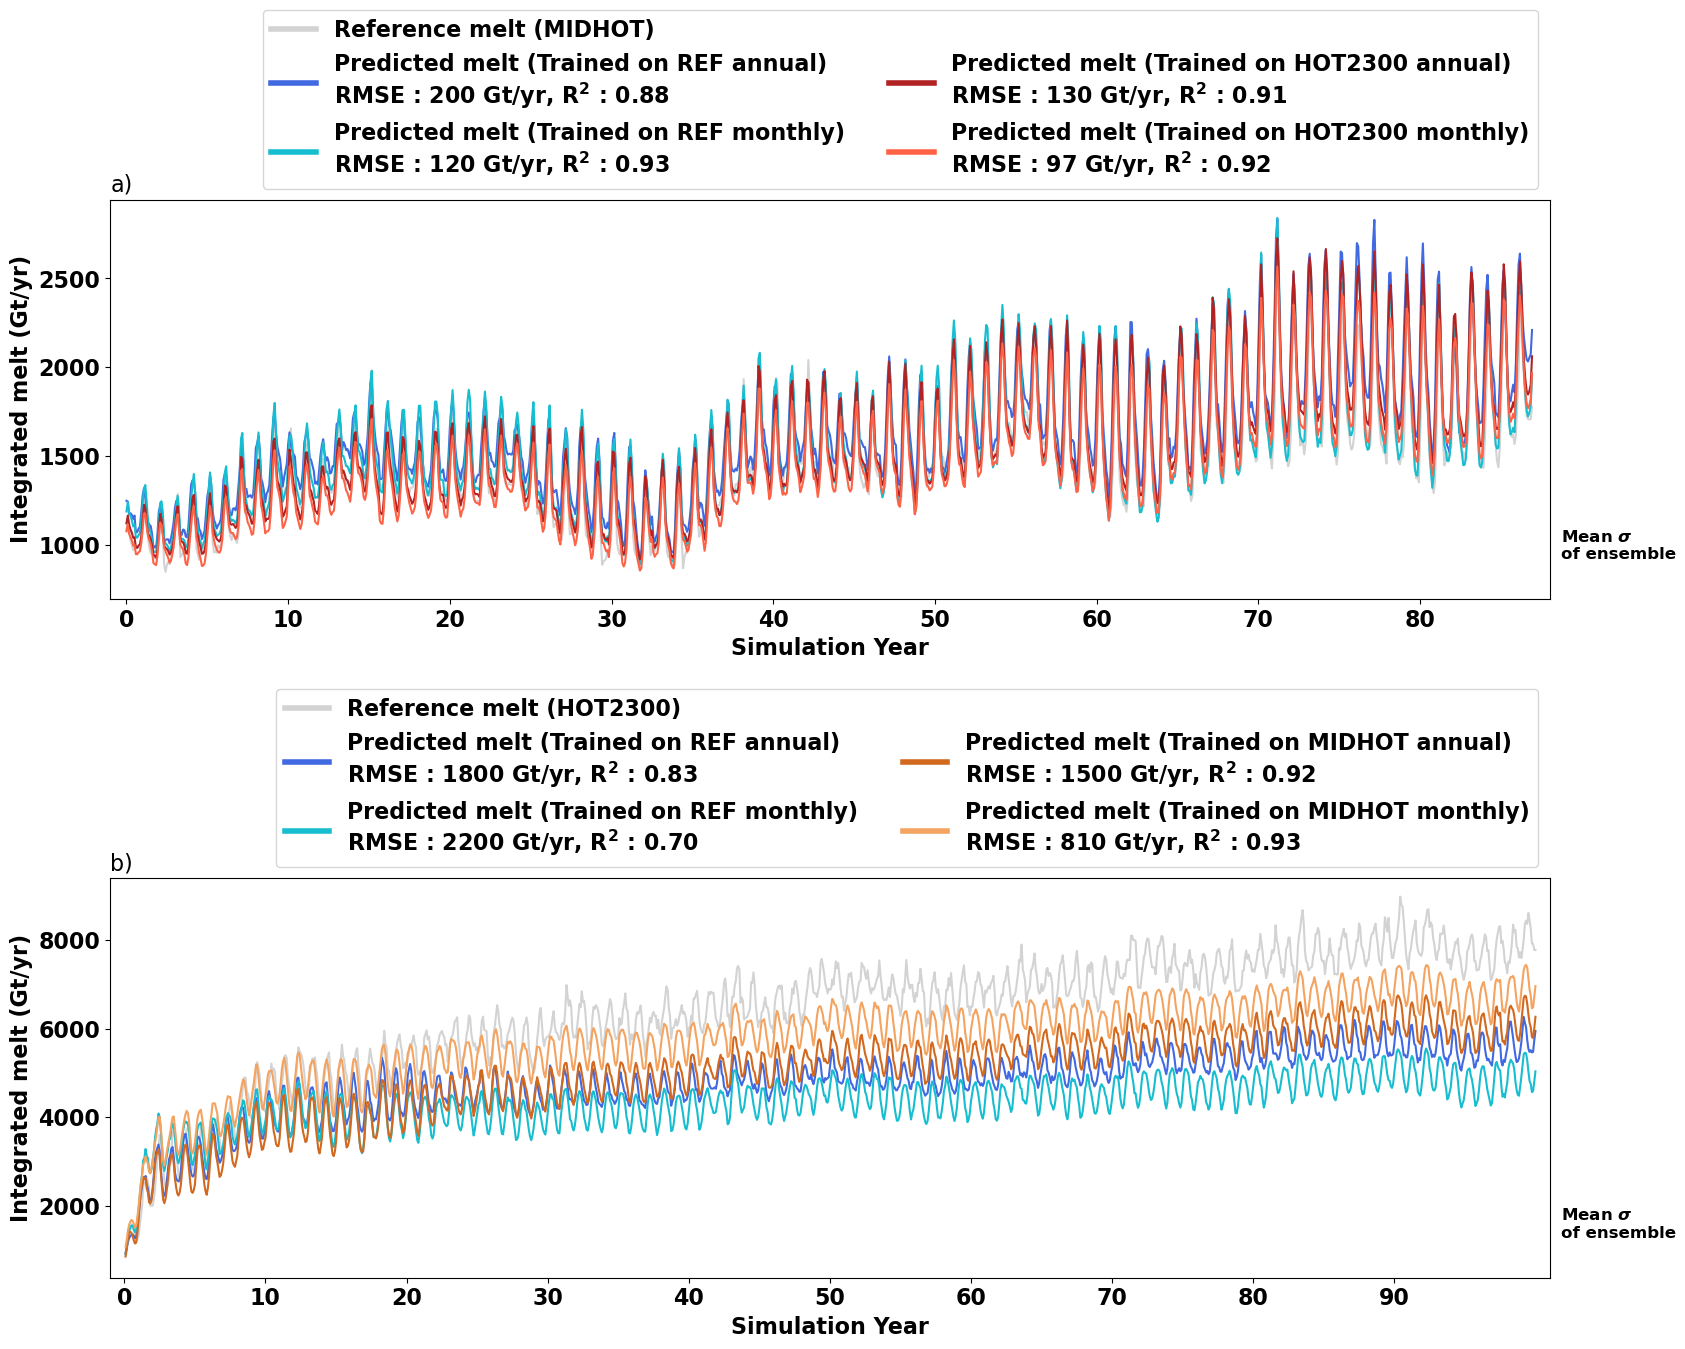

In [31]:
df_z = df_an
#RMSE = np.sqrt(np.mean((df_z[4].melt_Gt_per_y- df_z[4].melt_pred_Gt)**2))
#R2 = regression_analysis(df_z[0].melt_m_ice_per_y, df_z[0].melt_pred_mean)[2]
#R2_i = regression_analysis(df_z[4].melt_Gt_per_y, df_z[4].melt_pred_Gt)[2]


with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, axs = plt.subplots(2,2, figsize = (20,14), width_ratios = (19.5,1.5))
    fig.subplots_adjust(wspace=0, hspace = 0.7)

    ax = axs[0,0]
    df_z = df_an26
    ticks, labels = ticks_labels(df_z)    
    ax.plot(df_z.year + df_z.month/12, df_z.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (MIDHOT)', zorder = 0)
    plot_monthly_trend(df_an26, 'royalblue', label = 'Predicted melt (Trained on REF annual)', ax=ax,\
                       std = False, label_std = '$\\pm1\\sigma$', flip = 'second')
    plot_monthly_trend(df_mn26, 'C9', label = 'Predicted melt (Trained on REF monthly)', ax=ax,\
                       std = False, label_std = '$\\pm1\\sigma$', flip = 'second')
    ax.scatter((1), (800), color = 'white', \
               label = " ")
    plot_monthly_trend(df_an31, 'firebrick', label = 'Predicted melt (Trained on HOT2300 annual)', ax=ax, \
                       std = False, label_std = '$\\pm1\\sigma$', flip = 'second')
    plot_monthly_trend(df_mn31, 'tomato', label = 'Predicted melt (Trained on HOT2300 monthly)', ax=ax, \
                       std = False, label_std = '$\\pm1\\sigma$', flip = 'second')
    ax.set_xlabel('Simulation Year', fontsize = 16)
    ax.set_ylabel('Integrated melt (Gt/yr)', fontsize = 16)
    ax.set_xlim(np.min(np.unique(df_z.year))-1, np.max(np.unique(df_z.year))+2)
    ax.set_xticks(ticks, labels)
    leg = ax.legend(fontsize = 16, loc = 'lower right', bbox_to_anchor = [0,1,1,2], ncols = 2)
    for line in leg.get_lines():
        line.set_linewidth(4.0)
    ylims = ax.get_ylim()
    print(ylims)
    #ax.set_ylim(6000,8000)
    #ax.set_xlim(np.min(np.unique(df_z.year))+60,None)

    ax = axs[0,1]
    ax.axis('off')
    #std_range(df_mn26, 'C9', 2, 4, ax=ax)
    #std_range(df_an26, 'royalblue', 1,4,ax=ax)
    #std_range(df_mn31, 'tomato', 4, 4, ax = ax)
    #std_range(df_an31, 'firebrick', 3, 4, ax =ax)
    ax.set_ylim(ylims)
    ax.set_xlim(0,1)

    ax.annotate('Mean $\\sigma$\nof ensemble'.format(np.mean(df_z.std_Gt)), xytext = (0.1,0.1), \
                xy = (0.5,0.5), xycoords = 'axes fraction', \
                fontsize = 12)
    
    ax = axs[1,0]
    df_z = df_an
    ticks, labels = ticks_labels(df_z)    
    ax.plot(df_z.year + df_z.month/12, -df_z.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (HOT2300)')
    plot_monthly_trend(df_an, 'royalblue', label = 'Predicted melt (Trained on REF annual)', ax = ax, std = False, label_std = '$\\pm1\\sigma$')
    plot_monthly_trend(df2, 'C9', label = 'Predicted melt (Trained on REF monthly)', ax=ax, std = False, label_std = '$\\pm1\\sigma$')
    ax.scatter((1), (800), color = 'white', \
               label = " ")
    plot_monthly_trend(df_anc, 'chocolate', label = 'Predicted melt (Trained on MIDHOT annual)', ax=ax,\
                       std = False, label_std = '$\\pm1\\sigma$', flip = True)
    plot_monthly_trend(df_c, 'sandybrown', label = 'Predicted melt (Trained on MIDHOT monthly)', ax = ax,\
                       std = False, label_std = '$\\pm1\\sigma$', flip = True)
    #ax.scatter((1), (800), color = 'white', \
    #           label = "Pointwise RMSE : {:.2f} m/yr, R$^2$ : {:.2f} ".format(df_z[5], R2))
    #ax.scatter((1), (800), color = 'white', \
    #           label = "Integrated RMSE : {:.2f} Gt/yr, R$^2$ : {:.2f} ".format(RMSE, R2_i))
    #ax.scatter((1), (800), color = 'white', \
    #           label = "Integrated $\\sigma_{{mean}}$ : {:.2f} Gt/yr".format(df_z[4].std_Gt.mean()))
    ax.set_xlabel('Simulation Year', fontsize = 16)
    ax.set_ylabel('Integrated melt (Gt/yr)', fontsize = 16)
    ax.set_xlim(np.min(np.unique(df_z.year))-1, np.max(np.unique(df_z.year))+2)
    ax.set_xticks(ticks, labels)
    leg = ax.legend(fontsize = 16, loc = 'lower right', bbox_to_anchor = [0,1,1,2], ncols = 2)
    for line in leg.get_lines():
        line.set_linewidth(4.0)
    ylims = ax.get_ylim()
    print(ylims)
    #ax.set_ylim(6000,8000)
    #ax.set_xlim(np.min(np.unique(df_z.year))+60,None)

    ax = axs[1,1]
    ax.axis('off')
    #std_range(df2, 'C9', 2, 4, ax = ax)
    #std_range(df_an, 'royalblue', 1,4, ax=ax)
    #std_range(df_c, 'sandybrown', 4,4, ax=ax, flip = True)
    #std_range(df_anc, 'chocolate', 3,4, ax=ax, flip = True)
    ax.set_ylim(ylims)
    ax.set_xlim(0,1)

    ax.annotate('Mean $\\sigma$\nof ensemble'.format(np.mean(df_z.std_Gt)), xytext = (0.1,0.1), \
                xy = (0.5,0.5), xycoords = 'axes fraction', \
                fontsize = 12)
    labels = ('a)', 'b)')
    for i in range(2):
        axs[i,0].annotate(labels[i], xytext = (0,1.02), \
                xy = (0.5,0.5), xycoords = 'axes fraction', fontweight = 'normal')
    
    plt.show()
    fig.savefig('FIGURES/Monthly_or_Annual.pdf', bbox_inches = 'tight')
 #   ax.set_ylim(-9000,-500)

In [32]:
def plot_RMSE(df_z):
    RMSE = np.sqrt(np.mean((df_z.melt_Gt_per_y+ df_z.melt_pred_Gt)**2))
    print(RMSE)

In [33]:
plot_RMSE(df_mn31)

97.27081954652208


In [34]:
np.sqrt(np.mean((df_mn31.melt_Gt_per_y + df_mn31.melt_pred_Gt)**2))

97.27081954652208

In [35]:
df_mn26_trim = df_mn26[['year','month', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt']]
df_mn31_trim = df_mn31[['year','month', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt']]

In [36]:
df_mn26_trim = df_mn26[['year','month', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt']]
df_mn31_trim = df_mn31[['year','month', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt']]
fp_data = 'Figure_data/'
df_mn26_trim.to_csv(fp_data + 'df_mn26_trim.csv', index = False)
df_mn31_trim.to_csv(fp_data + 'df_mn31_trim.csv', index = False)
df_mn26_trim = pd.read_csv(fp_data+ 'df_mn26_trim.csv')
df_mn31_trim = pd.read_csv(fp_data+ 'df_mn31_trim.csv')

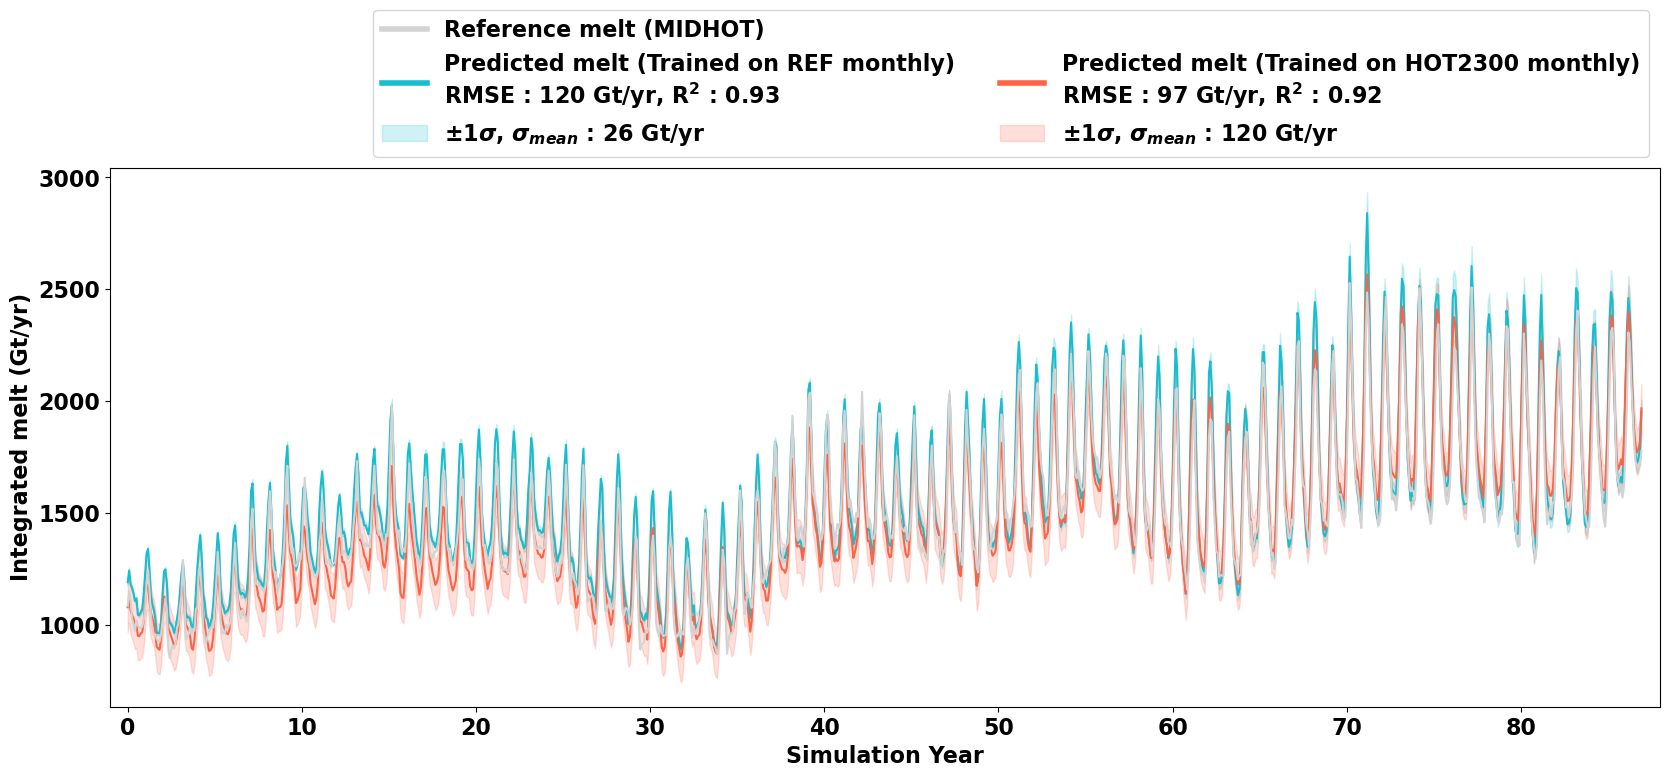

In [37]:

with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, axs = plt.subplots(1,1, figsize = (20,7))
    fig.subplots_adjust(wspace=0, hspace = 0.7)

    ax = axs
    df_z = df_an26
    ticks, labels = ticks_labels(df_z)    
    ax.plot(df_z.year + df_z.month/12, df_z.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (MIDHOT)', zorder = 10)
    plot_monthly_trend(df_mn26_trim, 'C9', label = 'Predicted melt (Trained on REF monthly)', \
                       std = True, label_std = '$\\pm1\\sigma$', flip = 'second', ax = ax)
    ax.scatter((1), (800), color = 'white', \
               label = " ")
    plot_monthly_trend(df_mn31_trim, 'tomato', label = 'Predicted melt (Trained on HOT2300 monthly)', \
                       std = True, label_std = '$\\pm1\\sigma$', flip = 'second', ax = ax)
    ax.set_xlim(np.min(np.unique(df_z.year))-1, np.max(np.unique(df_z.year))+2)
    ax.set_xticks(ticks, labels)
    

    ax.set_xlabel('Simulation Year', fontsize = 16)
    ax.set_ylabel('Integrated melt (Gt/yr)', fontsize = 16)
    leg = ax.legend(fontsize = 16, loc = 'lower right', bbox_to_anchor = [0,1,1,2], ncols = 2)
    for line in leg.get_lines():
        line.set_linewidth(4.0)
    
    plt.show()
    fig.savefig('FIGURES/Outside_temp_conditions.pdf', bbox_inches = 'tight')
 #   ax.set_ylim(-9000,-500)

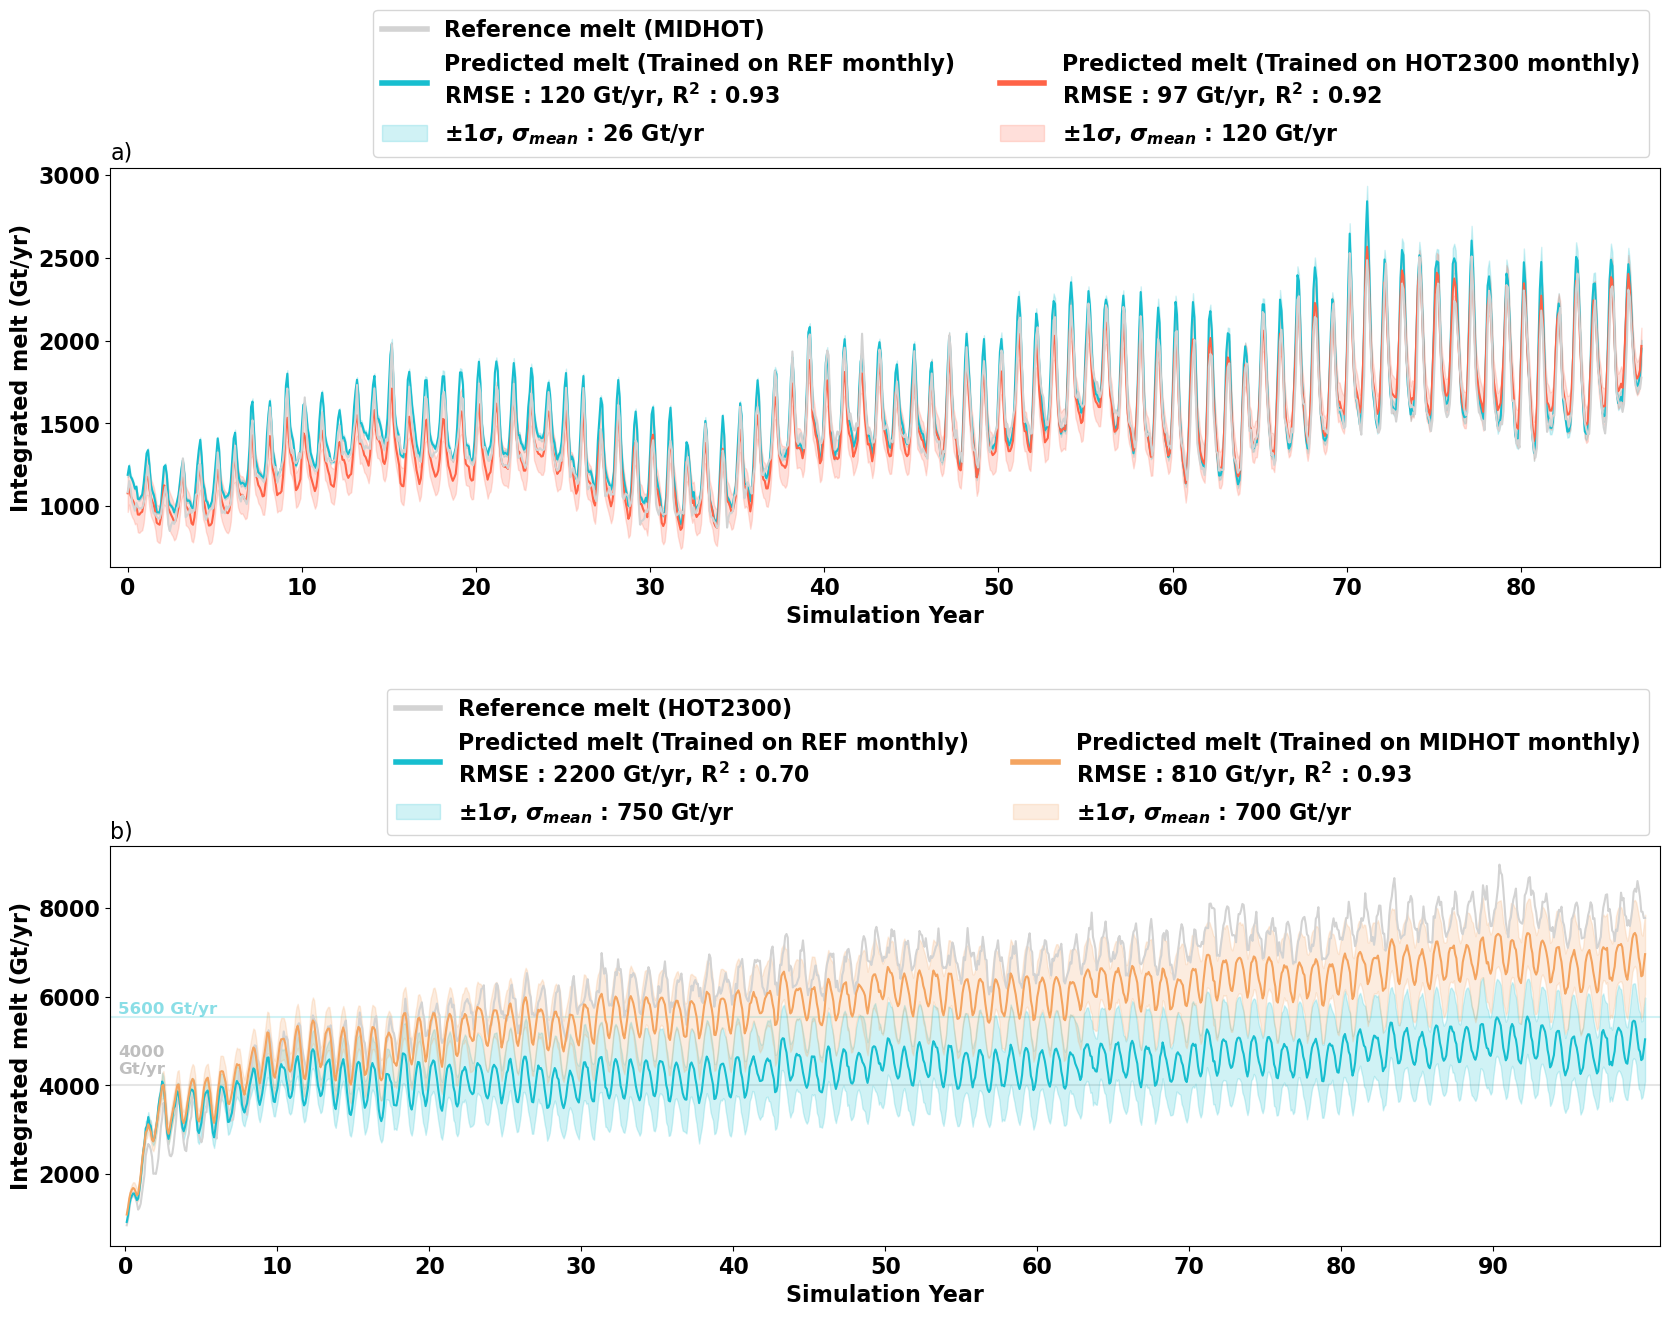

In [38]:
df_z = df_an
#RMSE = np.sqrt(np.mean((df_z[4].melt_Gt_per_y- df_z[4].melt_pred_Gt)**2))
#R2 = regression_analysis(df_z[0].melt_m_ice_per_y, df_z[0].melt_pred_mean)[2]
#R2_i = regression_analysis(df_z[4].melt_Gt_per_y, df_z[4].melt_pred_Gt)[2]


with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, axs = plt.subplots(2,1, figsize = (20,14))
    fig.subplots_adjust(wspace=0, hspace = 0.7)

    ax = axs[0]
    df_z = df_an26
    ticks, labels = ticks_labels(df_z)    
    ax.plot(df_z.year + df_z.month/12, df_z.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (MIDHOT)', zorder = 10)
    plot_monthly_trend(df_mn26, 'C9', label = 'Predicted melt (Trained on REF monthly)', ax=ax,\
                       std = True, label_std = '$\\pm1\\sigma$', flip = 'second')
    ax.scatter((1), (800), color = 'white', \
               label = " ")
    plot_monthly_trend(df_mn31, 'tomato', label = 'Predicted melt (Trained on HOT2300 monthly)', ax=ax,\
                       std = True, label_std = '$\\pm1\\sigma$', flip = 'second')
    ax.set_xlim(np.min(np.unique(df_z.year))-1, np.max(np.unique(df_z.year))+2)
    ax.set_xticks(ticks, labels)
    
    ax = axs[1]
    df_z = df_an
    ticks, labels = ticks_labels(df_z)    
    ax.plot(df_z.year + df_z.month/12, -df_z.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (HOT2300)')
    plot_monthly_trend(df2, 'C9', label = 'Predicted melt (Trained on REF monthly)', ax=ax,\
                       std = True, label_std = '$\\pm1\\sigma$')
    ax.scatter((1), (800), color = 'white', \
               label = " ")
    plot_monthly_trend(df_c, 'sandybrown', label = 'Predicted melt (Trained on MIDHOT monthly)',ax=ax,\
                       std = True, label_std = '$\\pm1\\sigma$', flip = True)
    ax.set_xlim(np.min(np.unique(df_z.year))-1, np.max(np.unique(df_z.year))+2)
    ax.set_xticks(ticks, labels)
    ax.axhline(y=5552, color = 'C9', alpha = 0.2, zorder = 0)
    ax.axhline(y=4000, color = 'grey', alpha = 0.2, zorder = 0)
    ax.annotate('5600 Gt/yr', color = 'C9', alpha = 0.5, xytext = (0.005,0.58), xy = (0,0.5), \
                xycoords = 'axes fraction', fontsize = 12)
    ax.annotate('4000\nGt/yr', color = 'grey', alpha = 0.5, xytext = (0.005,0.43), xy = (0,0.5), \
                xycoords = 'axes fraction', fontsize = 12)

    labels = ('a)', 'b)')
    for i in range(2):
        axs[i].annotate(labels[i], xytext = (0,1.02), \
                xy = (0.5,0.5), xycoords = 'axes fraction', fontweight = 'normal')
        axs[i].set_xlabel('Simulation Year', fontsize = 16)
        axs[i].set_ylabel('Integrated melt (Gt/yr)', fontsize = 16)
        leg = axs[i].legend(fontsize = 16, loc = 'lower right', bbox_to_anchor = [0,1,1,2], ncols = 2)
        for line in leg.get_lines():
            line.set_linewidth(4.0)
    
    plt.show()
    fig.savefig('FIGURES/Outside_temp_conditions.pdf', bbox_inches = 'tight')
 #   ax.set_ylim(-9000,-500)

In [39]:
df_26on263 = \
    load_results_nn(this_collection_NN = 'OPM026', this_collection_apply = 'OPM0263_whole_dataset', path_model = path_model, \
                   load_ym_only = True)
df_Chon263 = \
    load_results_nn(this_collection_NN = 'Christoph', this_collection_apply = 'OPM0263_whole_dataset', path_model = path_model, \
                   load_ym_only = True)

In [40]:
df_31on263 = \
    load_results_nn(this_collection_NN = 'OPM031', this_collection_apply = 'OPM0263_whole_dataset', path_model = path_model, \
                   load_ym_only = True)

In [41]:
mask = df_26on263.year > 1980

(595.6271347209056, 1544.1290338326287)


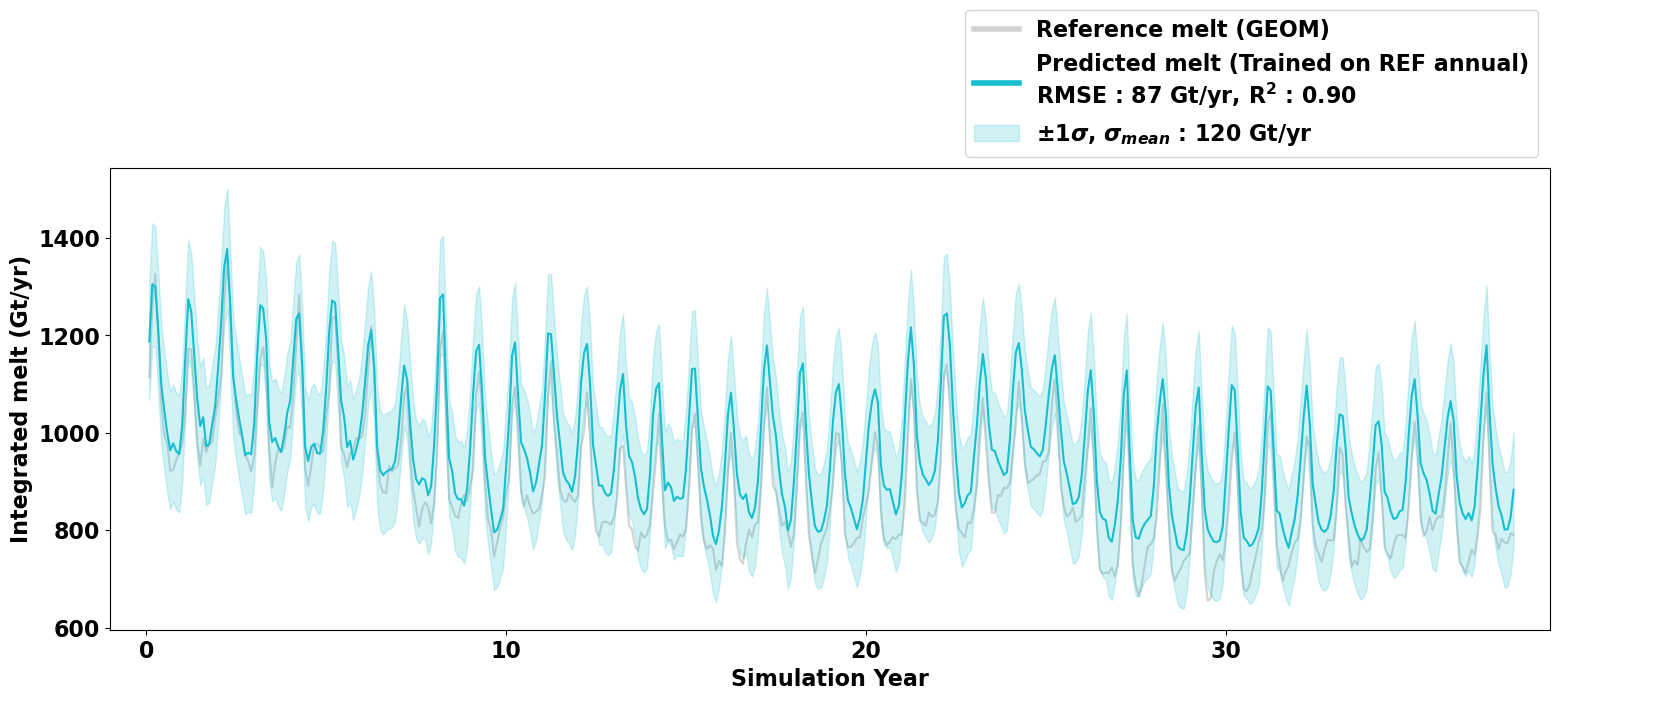

In [42]:
df_z = df_26on263[mask]
ticks, labels = ticks_labels(df_z)    

with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, axs = plt.subplots(1,2, figsize = (20,6), width_ratios = (19.5,1.5))
    fig.subplots_adjust(wspace=0, hspace=0)
    ax = axs[0]
    ax.plot(df_z.year + df_z.month/12, -df_z.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (GEOM)', zorder = 0)
    plot_monthly_trend(df_z, 'C9', label = 'Predicted melt (Trained on REF annual)', ax =ax,\
                       std = True, label_std = '$\\pm1\\sigma$')
    #plot_monthly_trend(df_Chon263[mask], 'peachpuff', label = 'Predicted melt (Trained on REF annual)', \
    #                   std = True, label_std = '$\\pm1\\sigma$', flip = True)
    #plot_monthly_trend(df_31on263[mask], 'tomato', label = 'Predicted melt (Trained on REF annual)', \
    #                   std = True, label_std = '$\\pm1\\sigma$')
    #ax.scatter((1), (800), color = 'white', \
    #           label = " ")
    #plot_monthly_trend(df_Chon263[mask], 'peachpuff', label = 'Predicted melt (Trained on REF annual)', \
    #                   std = True, label_std = '$\\pm1\\sigma$', flip = True)
    ax.set_xlabel('Simulation Year', fontsize = 16)
    ax.set_ylabel('Integrated melt (Gt/yr)', fontsize = 16)
    ax.set_xlim(np.min(np.unique(df_z.year))-1, np.max(np.unique(df_z.year))+2)
    ax.set_xticks(ticks, labels)
    leg = ax.legend(fontsize = 16, loc = 'lower right', bbox_to_anchor = [0,1,1,2], ncols = 1)
    for line in leg.get_lines():
        line.set_linewidth(4.0)
    ylims = ax.get_ylim()
    print(ylims)
    #ax.set_ylim(6000,8000)
    #ax.set_xlim(np.min(np.unique(df_z.year))+60,None)

    ax = axs[1]
    ax.axis('off')
#    std_range(df_26on263[mask], 'C9', 1, 4)
#    std_range(df_Chon263[mask], 'peachpuff', 2,4, flip = True)
#    std_range(df_mn31, 'tomato', 3, 4)
#    std_range(df_an31, 'firebrick', 4, 4)
    ax.set_ylim(ylims)
    ax.set_xlim(0,1)

#    ax.annotate('Mean $\\sigma$\nof ensemble'.format(np.mean(df_z.std_Gt)), xytext = (0.1,0.1), \
#                xy = (0.5,0.5), xycoords = 'axes fraction', \
#                fontsize = 12)
    
    plt.show()
    fig.savefig('FIGURES/GPM.pdf', bbox_inches = 'tight')
 #   ax.set_ylim(-9000,-500)

In [43]:
df_263on26 = \
    load_results_nn(this_collection_NN = 'OPM0263', this_collection_apply = 'OPM026_whole_dataset', path_model = path_model, \
                   load_ym_only = True)
print('Loaded')

Loaded


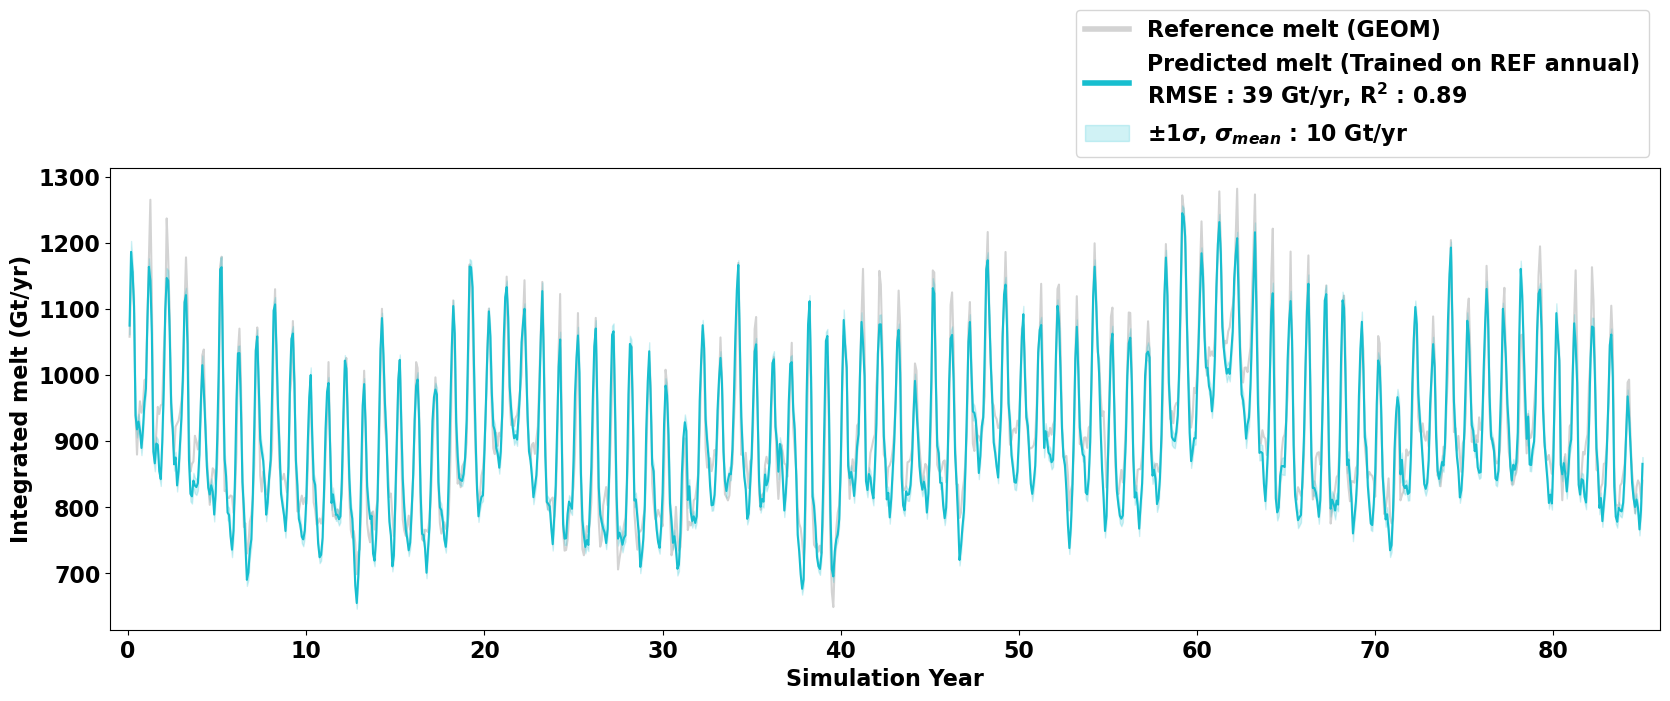

In [44]:
df_z = df_263on26
ticks, labels = ticks_labels(df_z)    

with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, axs = plt.subplots(1,1, figsize = (20,6))
    fig.subplots_adjust(wspace=0, hspace=0)
    ax = axs
    ax.plot(df_z.year + df_z.month/12, -df_z.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (GEOM)', zorder = 0)
    plot_monthly_trend(df_z, 'C9', label = 'Predicted melt (Trained on REF annual)', ax = ax, \
                       std = True, label_std = '$\\pm1\\sigma$')
    ax.set_xlabel('Simulation Year', fontsize = 16)
    ax.set_ylabel('Integrated melt (Gt/yr)', fontsize = 16)
    ax.set_xlim(np.min(np.unique(df_z.year))-1, np.max(np.unique(df_z.year))+2)
    ax.set_xticks(ticks, labels)
    leg = ax.legend(fontsize = 16, loc = 'lower right', bbox_to_anchor = [0,1,1,2], ncols = 1)
    for line in leg.get_lines():
        line.set_linewidth(4.0)
    plt.show()
#    fig.savefig('FIGURES/GPM.pdf', bbox_inches = 'tight')


In [45]:
df_263on26 = \
    load_results_nn(this_collection_NN = 'OPM0263', this_collection_apply = 'OPM026_whole_dataset', path_model = path_model, \
                   load_ym_only = False)[0]
print('Loaded')

Loaded


In [46]:
df_z = df_263on26
latlonbasin = df_z.groupby(['lat','lon'], as_index = False).mean()

latlonbasin_m = latlonbasin.groupby('basin', as_index = False).mean()
latlonbasin_m = latlonbasin_m.drop(['area','year','month', 'melt_m_ice_per_y', 'melt_01', 'melt_02', 'melt_03', 'melt_04', 'melt_05', 'melt_06',\
                   'melt_07', 'melt_08', 'melt_09', 'melt_10', 'melt_pred_mean', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt'], axis = 1)
#latlonbasin_m

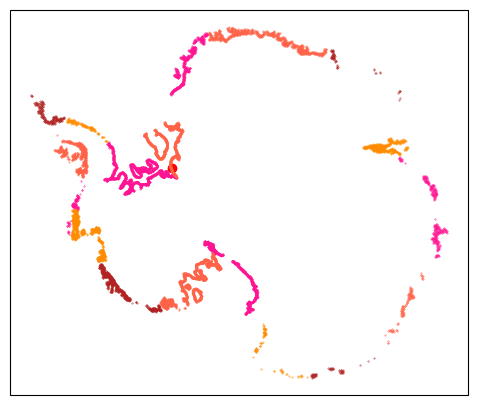

In [47]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})
#plt.scatter(latlonbasin_m.lon,latlonbasin_m.lat, transform = trans)
i = 1
mask = [latlonbasin_m.basin.values == i][0]
plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = 'red')

colors = ['deeppink', 'tomato', 'firebrick', 'darkorange']
regions = [[2,153,3,6,7,4],\
           [8,9,12,11,14,13,15],\
           [16,17,18,19,128,22],\
           [103,154],\
           [21,23,24,25,26,27,28],\
           [29,30,31,32,33,34,35,36,37,38],\
           [40,41,42,43,44],\
           [45,97,94,95,69,70,89,88,92,93,91,90,87,46,47],\
           [136,137,62,68,67,66,65,64,63,61,60,59],\
           [57,58,71,72,73,138,140,139,81,80,79,78,104],\
           [105,49,132,141,108,142],\
           [129,101,51,50,107,130,52,143],\
           [144,145,146,110,55,56,133,134],\
           [111,125,124,127,126,100],\
           [113,122,115,116],\
           [147,119,117,77,118],\
           [120,76,75,74,86,99,98,85,150,149,148,155],\
           [1,84,121,83,82,135,152,151]]
for i in range(len(regions)):
    for j in range(len(regions[i])):
        #mask = [latlonbasin_m.basin.values == regions[i][j]][0]
        #plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = colors[np.mod(i,3)])
        basin = latlonbasin[latlonbasin.basin == regions[i][j]]
        im = plt.scatter(basin.lon, basin.lat, c = colors[np.mod(i,4)], \
                   transform = trans, s= 0.1)        
plt.show()

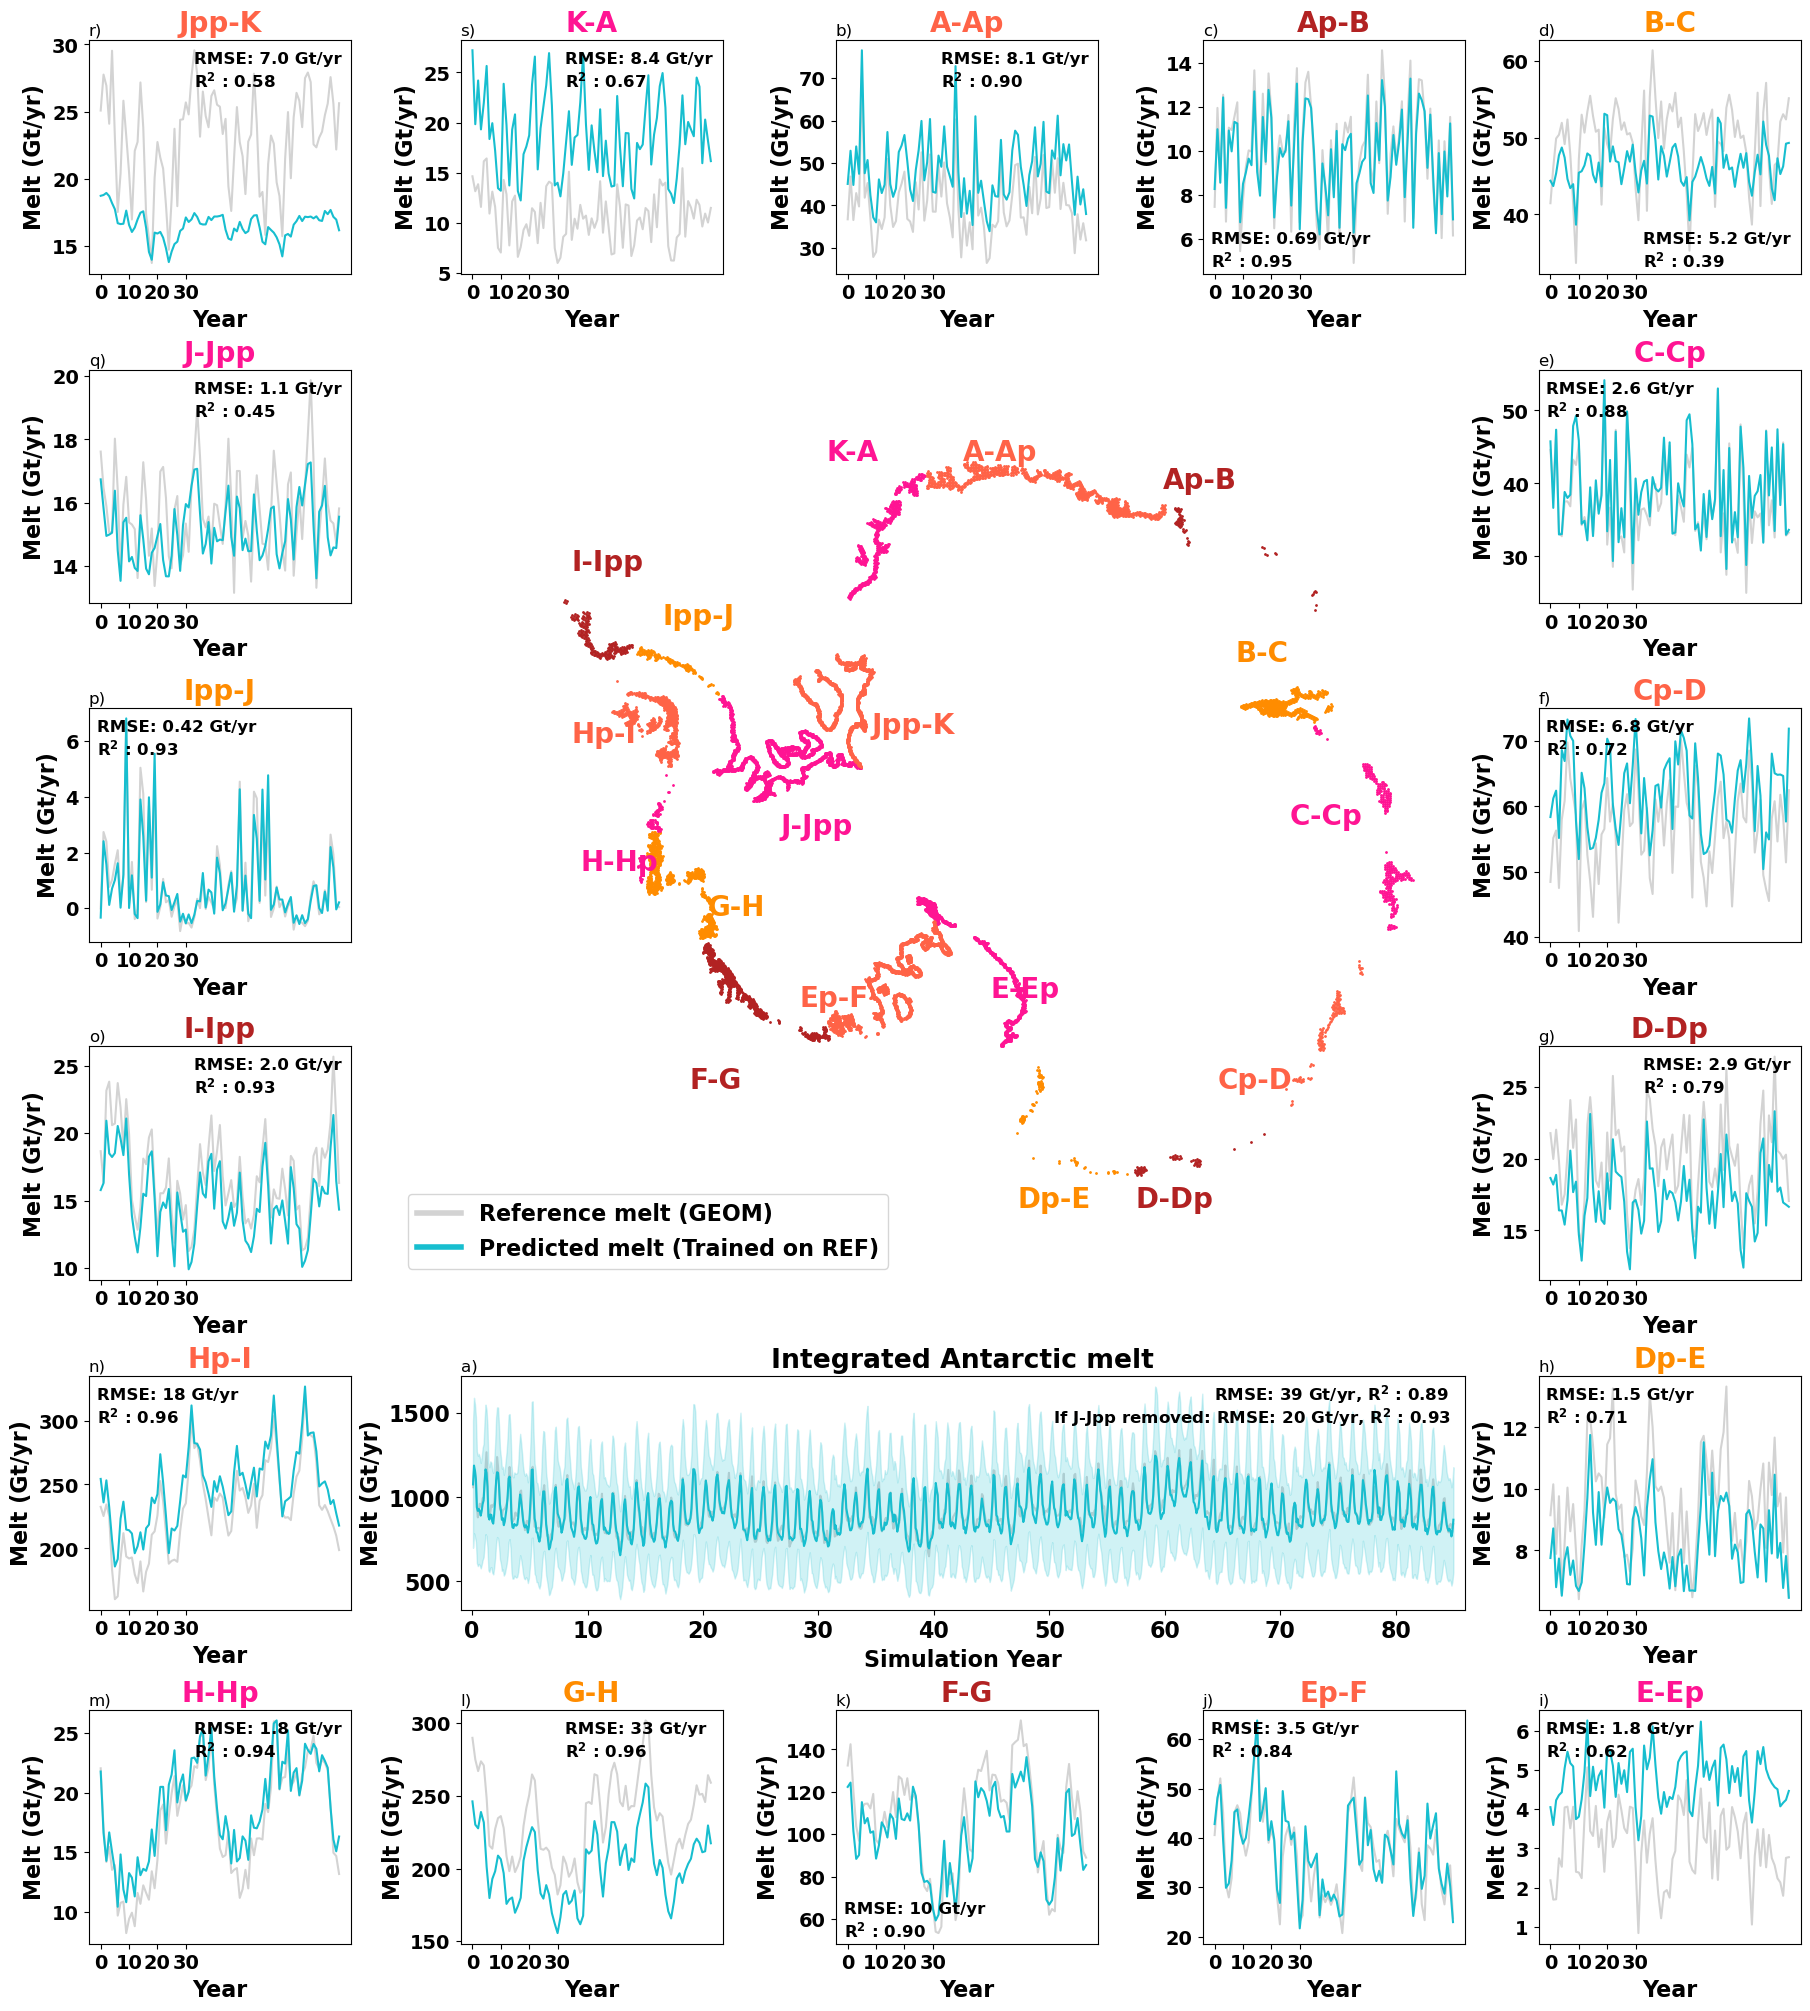

In [48]:
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    axs = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
    fig = plt.figure(constrained_layout=True, figsize = (18,20))
    widths = [4,4,4,4,4]
    heights = [4,4,4,4,4,4]
    gs = fig.add_gridspec(6,5, width_ratios = widths, height_ratios = heights)
    #for i,j in itertools.product(range(6),range(5)):
    #    fig.add_subplot(gs[i,j])
    
    titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
              'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
              'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
              'Ipp-J', 'J-Jpp', 'Jpp-K']
    coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
              (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
              (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
              (0.3,0.49), (0.4,0.60)]
    
    axs[17] = fig.add_subplot(gs[1:4,1:4], projection= proj)
    axs[17].set_extent( (-180, 180, -88, -65), trans )
    for i in range(len(regions)):
        for j in range(len(regions[i])):
            basin = latlonbasin[latlonbasin.basin == regions[i][j]]
            im = axs[17].scatter(basin.lon, basin.lat, c = colors[np.mod(i,4)], \
                       transform = trans, s= 1)    
        axs[17].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                       fontsize = 20, color = colors[np.mod(i,4)])
    
    axs[17].axis('off')

    plot_i = [0,0,0,0,1,2,3,4,5,5,5,5,5,4,3,2,1,0]
    plot_j = [1,2,3,4,4,4,4,4,4,3,2,1,0,0,0,0,0,0]
    xytexts = [(0.4,0.8), (0.4,0.8), (0.03,0.03), (0.4,0.03), (0.03,0.8), (0.03,0.8), 
               (0.4,0.8), (0.03,0.8), (0.03,0.8), (0.03,0.8), (0.03,0.03), (0.4,0.8),  
               (0.4,0.8), (0.03,0.8), (0.4,0.8), (0.03,0.8), (0.4,0.8), (0.4,0.8)]
    plt_labels = ['s)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)', 'j)', 'k)', 'l)', 'm)', 'n)', 'o)', 'p)', 'q)', 'r)'] 
    for i in range(18):
        axs[i] = fig.add_subplot(gs[plot_i[i], plot_j[i]])

    df_z = df_263on26
    bym = df_z.groupby(['basin', 'year','month'], as_index = False).sum()
    for i in range(18):
        mask = np.in1d(bym.basin, regions[i])
        bym2 = bym[mask].groupby(['year'], as_index = False).sum()
        RMSE = np.sqrt(np.mean((bym2.melt_Gt_per_y/12- bym2.melt_pred_Gt/12)**2))
        R2 = regression_analysis(bym2.melt_Gt_per_y,bym2.melt_pred_Gt)[2]
        RMSE = twosigfig(RMSE)
        axs[i].plot(bym2.year-np.min(bym2.year), -bym2.melt_Gt_per_y/12, color = 'lightgrey')
        axs[i].plot(bym2.year-np.min(bym2.year), -bym2.melt_pred_Gt/12, color = 'C9')
        axs[i].set_title(titles[i], fontsize = 20, fontweight = 'bold', color = colors[np.mod(i,4)])
        axs[i].tick_params(axis='both', which='major', labelsize=14)
        axs[i].set_xlabel('Year')
        axs[i].set_ylabel('Melt (Gt/yr)')
        axs[i].set_xticks((0,10,20,30))
        axs[i].annotate('RMSE: {} Gt/yr\nR$^2$ : {:.2f}'.format(RMSE, R2), xytext = xytexts[i], xy = (0,0), \
                        xycoords = 'axes fraction', fontsize = 12)
        label = plt_labels[i]
        axs[i].annotate(label, xytext = (0,1.02), xy = (0,0), \
                        xycoords = 'axes fraction', fontsize = 12, fontweight = 'normal')

    axs[18] = fig.add_subplot(gs[4,1:4])
    axs[18].set_title('Integrated Antarctic melt', fontweight = 'bold')
    axs[18].set_xlabel('Year')
    axs[18].set_ylabel('Melt (Gt/yr)')

    df_z = df_263on26
    df_z = df_263on26.groupby(['year','month'], as_index = False).sum()
    ticks, labels = ticks_labels(df_z)    
    ax = axs[18]
    ax.plot(df_z.year + df_z.month/12, -df_z.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (GEOM)', zorder = 0)
    plot_monthly_trend(df_z, 'C9', label = 'Predicted melt (Trained on REF annual)', ax = ax, \
                       std = True, label_std = '$\\pm1\\sigma$')
    ax.set_xlabel('Simulation Year', fontsize = 16)
    ax.set_ylabel('Melt (Gt/yr)', fontsize = 16)
    ax.set_xlim(np.min(np.unique(df_z.year))-1, np.max(np.unique(df_z.year))+2)
    ax.set_xticks(ticks, labels)
    RMSE = np.sqrt(np.mean((df_z.melt_Gt_per_y- df_z.melt_pred_Gt)**2))
    R2 = regression_analysis(df_z.melt_Gt_per_y,df_z.melt_pred_Gt)[2]
    RMSE = twosigfig(RMSE)
    ax.annotate('RMSE: {} Gt/yr, R$^2$ : {:.2f}'.format(RMSE, R2), xytext = (0.75,0.9), xy = (0,0), \
                        xycoords = 'axes fraction', fontsize = 12)
    i = 16
    mask = np.in1d(bym.basin, regions[i])
    bym2 = bym[~mask].groupby(['year'], as_index = False).sum()
    RMSE = np.sqrt(np.mean((bym2.melt_Gt_per_y/12- bym2.melt_pred_Gt/12)**2))
    R2 = regression_analysis(bym2.melt_Gt_per_y,bym2.melt_pred_Gt)[2]
    RMSE = twosigfig(RMSE)
    ax.annotate('If J-Jpp removed: RMSE: {} Gt/yr, R$^2$ : {:.2f}'.format(RMSE, R2), xytext = (0.59,0.8), xy = (0,0), \
                        xycoords = 'axes fraction', fontsize = 12)
    label = 'a)'
    ax.annotate(label, xytext = (0,1.02), xy = (0,0), \
                        xycoords = 'axes fraction', fontsize = 12, fontweight = 'normal')

    axs[19] = fig.add_subplot(gs[3,1:3])
    ax = axs[19]
    ax.plot(df_z.year + df_z.month/12, -df_z.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (GEOM)', zorder = 0)
    ax.plot(df_z.year + df_z.month/12, -df_z.melt_Gt_per_y, color = 'C9', label = 'Predicted melt (Trained on REF)', zorder = 0)
    leg = ax.legend(fontsize = 16, loc = 'lower left', bbox_to_anchor = [-0.1,0,0.8,1])
    for line in leg.get_lines():
        line.set_linewidth(4.0)
    ax.set_xlim(-20,-10)
    ax.axis('off')
    
    plt.show()

    #fig.savefig('FIGURES/Basin_melt_GEOM.png', dpi = 200, bbox_inches = 'tight')

In [49]:
df_z = df_263on26.groupby(['year','month'], as_index = False).sum()

# TRY HERE 

In [5]:
df_26 = \
    load_results_nn(this_collection_NN = 'OPM026', this_collection_apply = 'OPM031_whole_dataset', path_model = path_model, \
                   load_ym_only = False)[0]
print('Loaded')
df_Ch = \
    load_results_nn(this_collection_NN = 'Christoph', this_collection_apply = 'OPM031_whole_dataset', path_model = path_model, \
                   load_ym_only = False)[0]
print('Loaded')

Loaded
Loaded


In [6]:
df2 = \
    load_results_nn(this_collection_NN = 'OPM026', this_collection_apply = 'OPM031_whole_dataset', path_model = path_model, \
                   load_ym_only = True)
df_c = \
    load_results_nn(this_collection_NN = 'Christoph', this_collection_apply = 'OPM031_whole_dataset', path_model = path_model, \
                   load_ym_only = True)

In [7]:
df_z = df_26
latlonbasin = df_z.groupby(['lat','lon'], as_index = False).mean()

latlonbasin_m = latlonbasin.groupby('basin', as_index = False).mean()
latlonbasin_m = latlonbasin_m.drop(['area','year','month', 'melt_m_ice_per_y', 'melt_01', 'melt_02', 'melt_03', 'melt_04', 'melt_05', 'melt_06',\
                   'melt_07', 'melt_08', 'melt_09', 'melt_10', 'melt_pred_mean', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt'], axis = 1)
#latlonbasin_m

In [8]:
latlonbasin_save = latlonbasin[['lat','lon', 'basin']]
fp_data = 'Figure_data/'
latlonbasin_save.to_csv(fp_data + 'latlonbasin.csv', index = False)
latlonbasin = pd.read_csv(fp_data+ 'latlonbasin.csv')

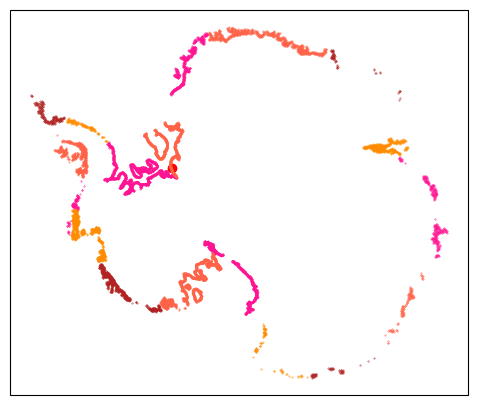

In [9]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})
#plt.scatter(latlonbasin_m.lon,latlonbasin_m.lat, transform = trans)
i = 1
mask = [latlonbasin_m.basin.values == i][0]
plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = 'red')

colors = ['deeppink', 'tomato', 'firebrick', 'darkorange']
regions = [[2,153,3,6,7,4],\
           [8,9,12,11,14,13,15],\
           [16,17,18,19,128,22],\
           [103,154],\
           [21,23,24,25,26,27,28],\
           [29,30,31,32,33,34,35,36,37,38],\
           [40,41,42,43,44],\
           [45,97,94,95,69,70,89,88,92,93,91,90,87,46,47],\
           [136,137,62,68,67,66,65,64,63,61,60,59],\
           [57,58,71,72,73,138,140,139,81,80,79,78,104],\
           [105,49,132,141,108,142],\
           [129,101,51,50,107,130,52,143],\
           [144,145,146,110,55,56,133,134],\
           [111,125,124,127,126,100],\
           [113,122,115,116],\
           [147,119,117,77,118],\
           [120,76,75,74,86,99,98,85,150,149,148,155],\
           [1,84,121,83,82,135,152,151]]
for i in range(len(regions)):
    for j in range(len(regions[i])):
        #mask = [latlonbasin_m.basin.values == regions[i][j]][0]
        #plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = colors[np.mod(i,3)])
        basin = latlonbasin[latlonbasin.basin == regions[i][j]]
        im = plt.scatter(basin.lon, basin.lat, c = colors[np.mod(i,4)], \
                   transform = trans, s= 0.1)        
plt.show()


In [10]:
bym = df_z.groupby(['basin', 'year','month'], as_index = False).sum()

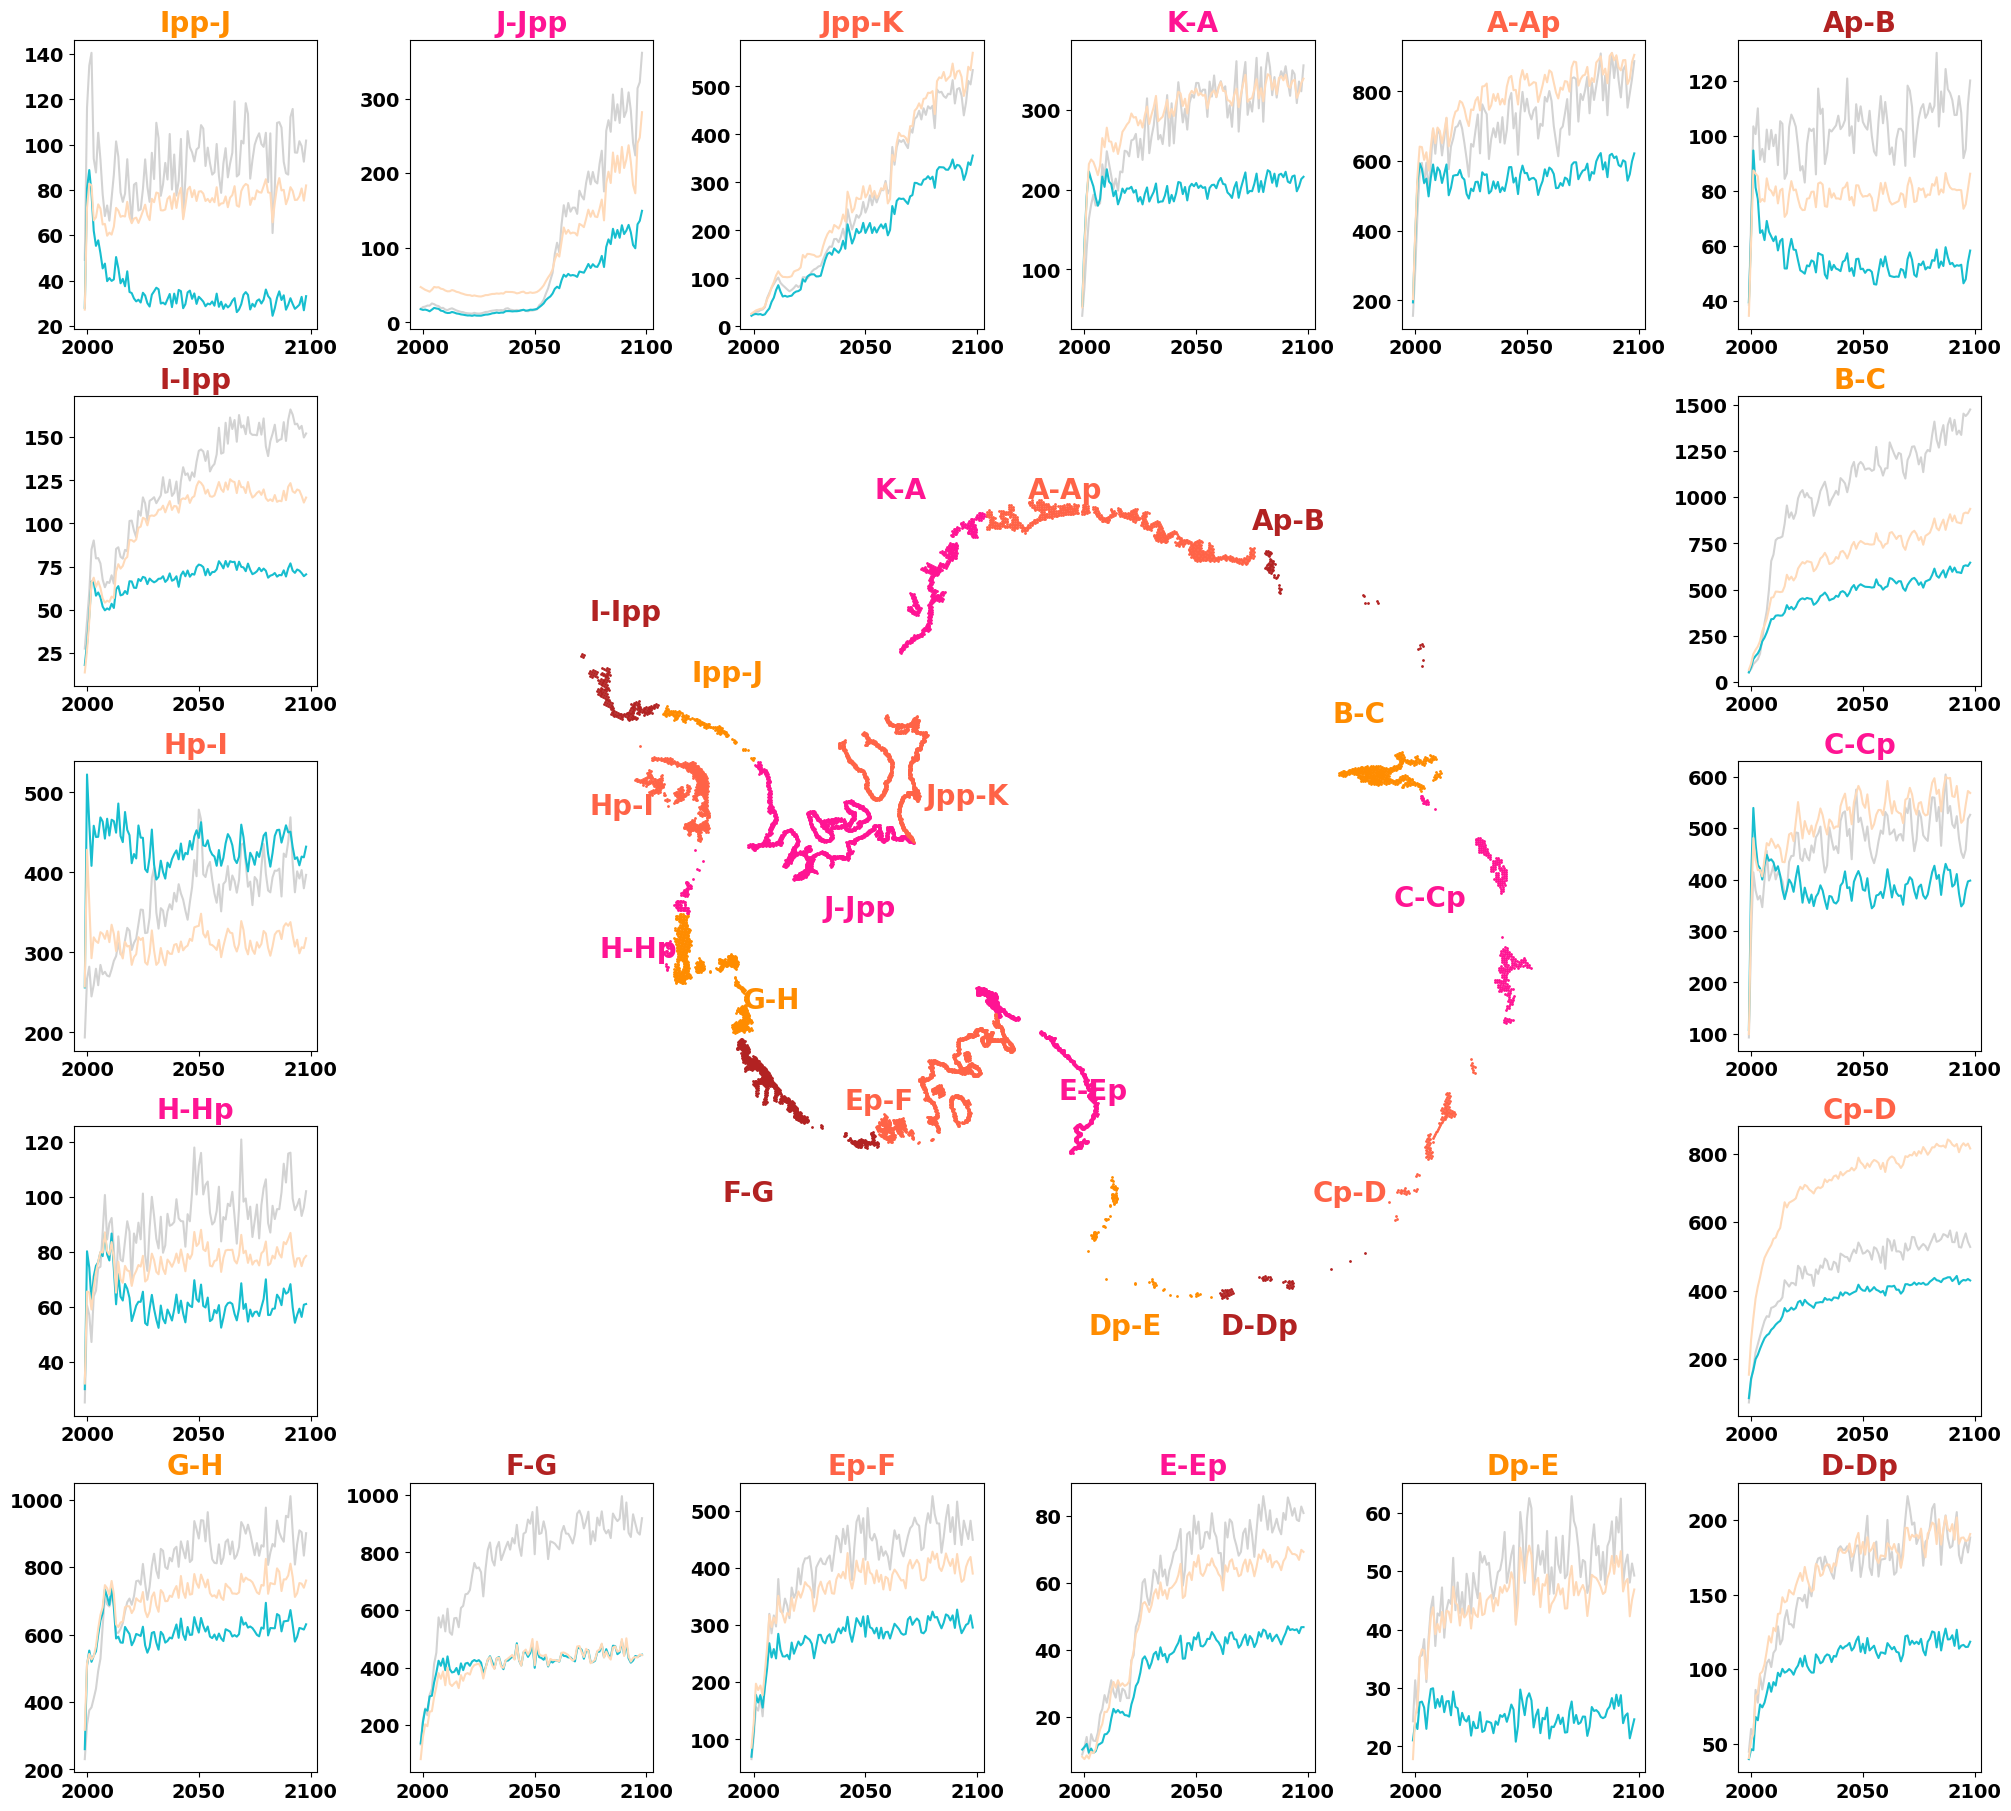

In [11]:
#with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
#                    'axes.labelcolor':'#0879B8', 'axes.titlecolor':'#0879B8'}):
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
#with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
#                    'axes.labelcolor':'#0879B8', 'figure.facecolor': '#c5eaff', 'axes.facecolor': 'white'}):
    ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
    fig = plt.figure(constrained_layout=True, figsize = (20,18))
    widths = [4,4,4,4,4,4]
    heights = [4,4,4,4,4]
    gs = fig.add_gridspec(5,6, width_ratios = widths, height_ratios = heights)
    #for i,j in itertools.product(range(5),range(6)):
    #    fig.add_subplot(gs[i,j])
    
    
    titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
              'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
              'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
              'Ipp-J', 'J-Jpp', 'Jpp-K']
    coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
              (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
              (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
              (0.3,0.49), (0.4,0.60)]
    
    ax[17] = fig.add_subplot(gs[1:4,1:5], projection= proj)
    ax[17].set_extent( (-180, 180, -88, -65), trans )
    #im = ax[17].pcolormesh(lon2d,lat2d,ocean2, vmin = -0.1, vmax = 0.9, rasterized=False, cmap = 'Blues_r', transform=trans, alpha = 1)
    
    
    for i in range(len(regions)):
        for j in range(len(regions[i])):
            #mask = [latlonbasin_m.basin.values == regions[i][j]][0]
            #plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = colors[np.mod(i,3)])
            basin = latlonbasin[latlonbasin.basin == regions[i][j]]
            im = ax[17].scatter(basin.lon, basin.lat, c = colors[np.mod(i,4)], \
                       transform = trans, s= 1)    
        ax[17].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                       fontsize = 20, color = colors[np.mod(i,4)])
    
    ax[17].axis('off')
    
    plot_i = [0,0,0,1,2,3,4,4,4,4,4,4,3,2,1,0,0,0]
    plot_j = [3,4,5,5,5,5,5,4,3,2,1,0,0,0,0,0,1,2]
    for i in range(18):
        ax[i] = fig.add_subplot(gs[plot_i[i], plot_j[i]])

    df_z = df_26
    bym = df_z.groupby(['basin', 'year','month'], as_index = False).sum()
    for i in range(18):
        mask = np.in1d(bym.basin, regions[i])
        bym2 = bym[mask].groupby(['year'], as_index = False).sum()
        ax[i].plot(bym2.year, -bym2.melt_Gt_per_y/12, color = 'lightgrey')
        ax[i].plot(bym2.year, -bym2.melt_pred_Gt/12, color = 'C9')
        ax[i].set_title(titles[i], fontsize = 20, fontweight = 'bold', color = colors[np.mod(i,4)])
        ax[i].tick_params(axis='both', which='major', labelsize=14)
    df_z = df_Ch
    bym = df_z.groupby(['basin', 'year','month'], as_index = False).sum()
    for i in range(18):
        mask = np.in1d(bym.basin, regions[i])
        bym2 = bym[mask].groupby(['year'], as_index = False).sum()
        ax[i].plot(bym2.year, bym2.melt_pred_Gt/12, color = 'peachpuff') 
        
plt.show()
fig.savefig('FIGURES/Basin_melt_OPM.png', dpi = 200, bbox_inches = 'tight')

In [12]:
df_26_ymb = df_26[['basin', 'year', 'month', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt']]
df_26_ymb = df_26_ymb.groupby(['year','month','basin'], as_index = False).sum()
df_Ch_ymb = df_Ch[['basin', 'year', 'month', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt']]
df_Ch_ymb = df_Ch_ymb.groupby(['year','month','basin'], as_index = False).sum()


In [13]:
df_26_ymb = df_26[['basin', 'year', 'month', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt']]
df_26_ymb = df_26_ymb.groupby(['year','month','basin'], as_index = False).sum()
df_Ch_ymb = df_Ch[['basin', 'year', 'month', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt']]
df_Ch_ymb = df_Ch_ymb.groupby(['year','month','basin'], as_index = False).sum()


fp_data = 'Figure_data/'
df_26_ymb.to_csv(fp_data + 'df_26_ymb.csv', index = False)
df_26_ymb = pd.read_csv(fp_data+ 'df_26_ymb.csv')
df_Ch_ymb.to_csv(fp_data + 'df_Ch_ymb.csv', index = False)
df_Ch_ymb = pd.read_csv(fp_data+ 'df_Ch_ymb.csv')

In [14]:
df_2_trim = df2[['year','month', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt']]
df_c_trim = df_c[['year','month', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt']]
df_2_trim.to_csv(fp_data + 'df_2_trim.csv', index = False)
df_c_trim.to_csv(fp_data + 'df_c_trim.csv', index = False)
df_2_trim = pd.read_csv(fp_data+ 'df_2_trim.csv')
df_c_trim = pd.read_csv(fp_data+ 'df_c_trim.csv')

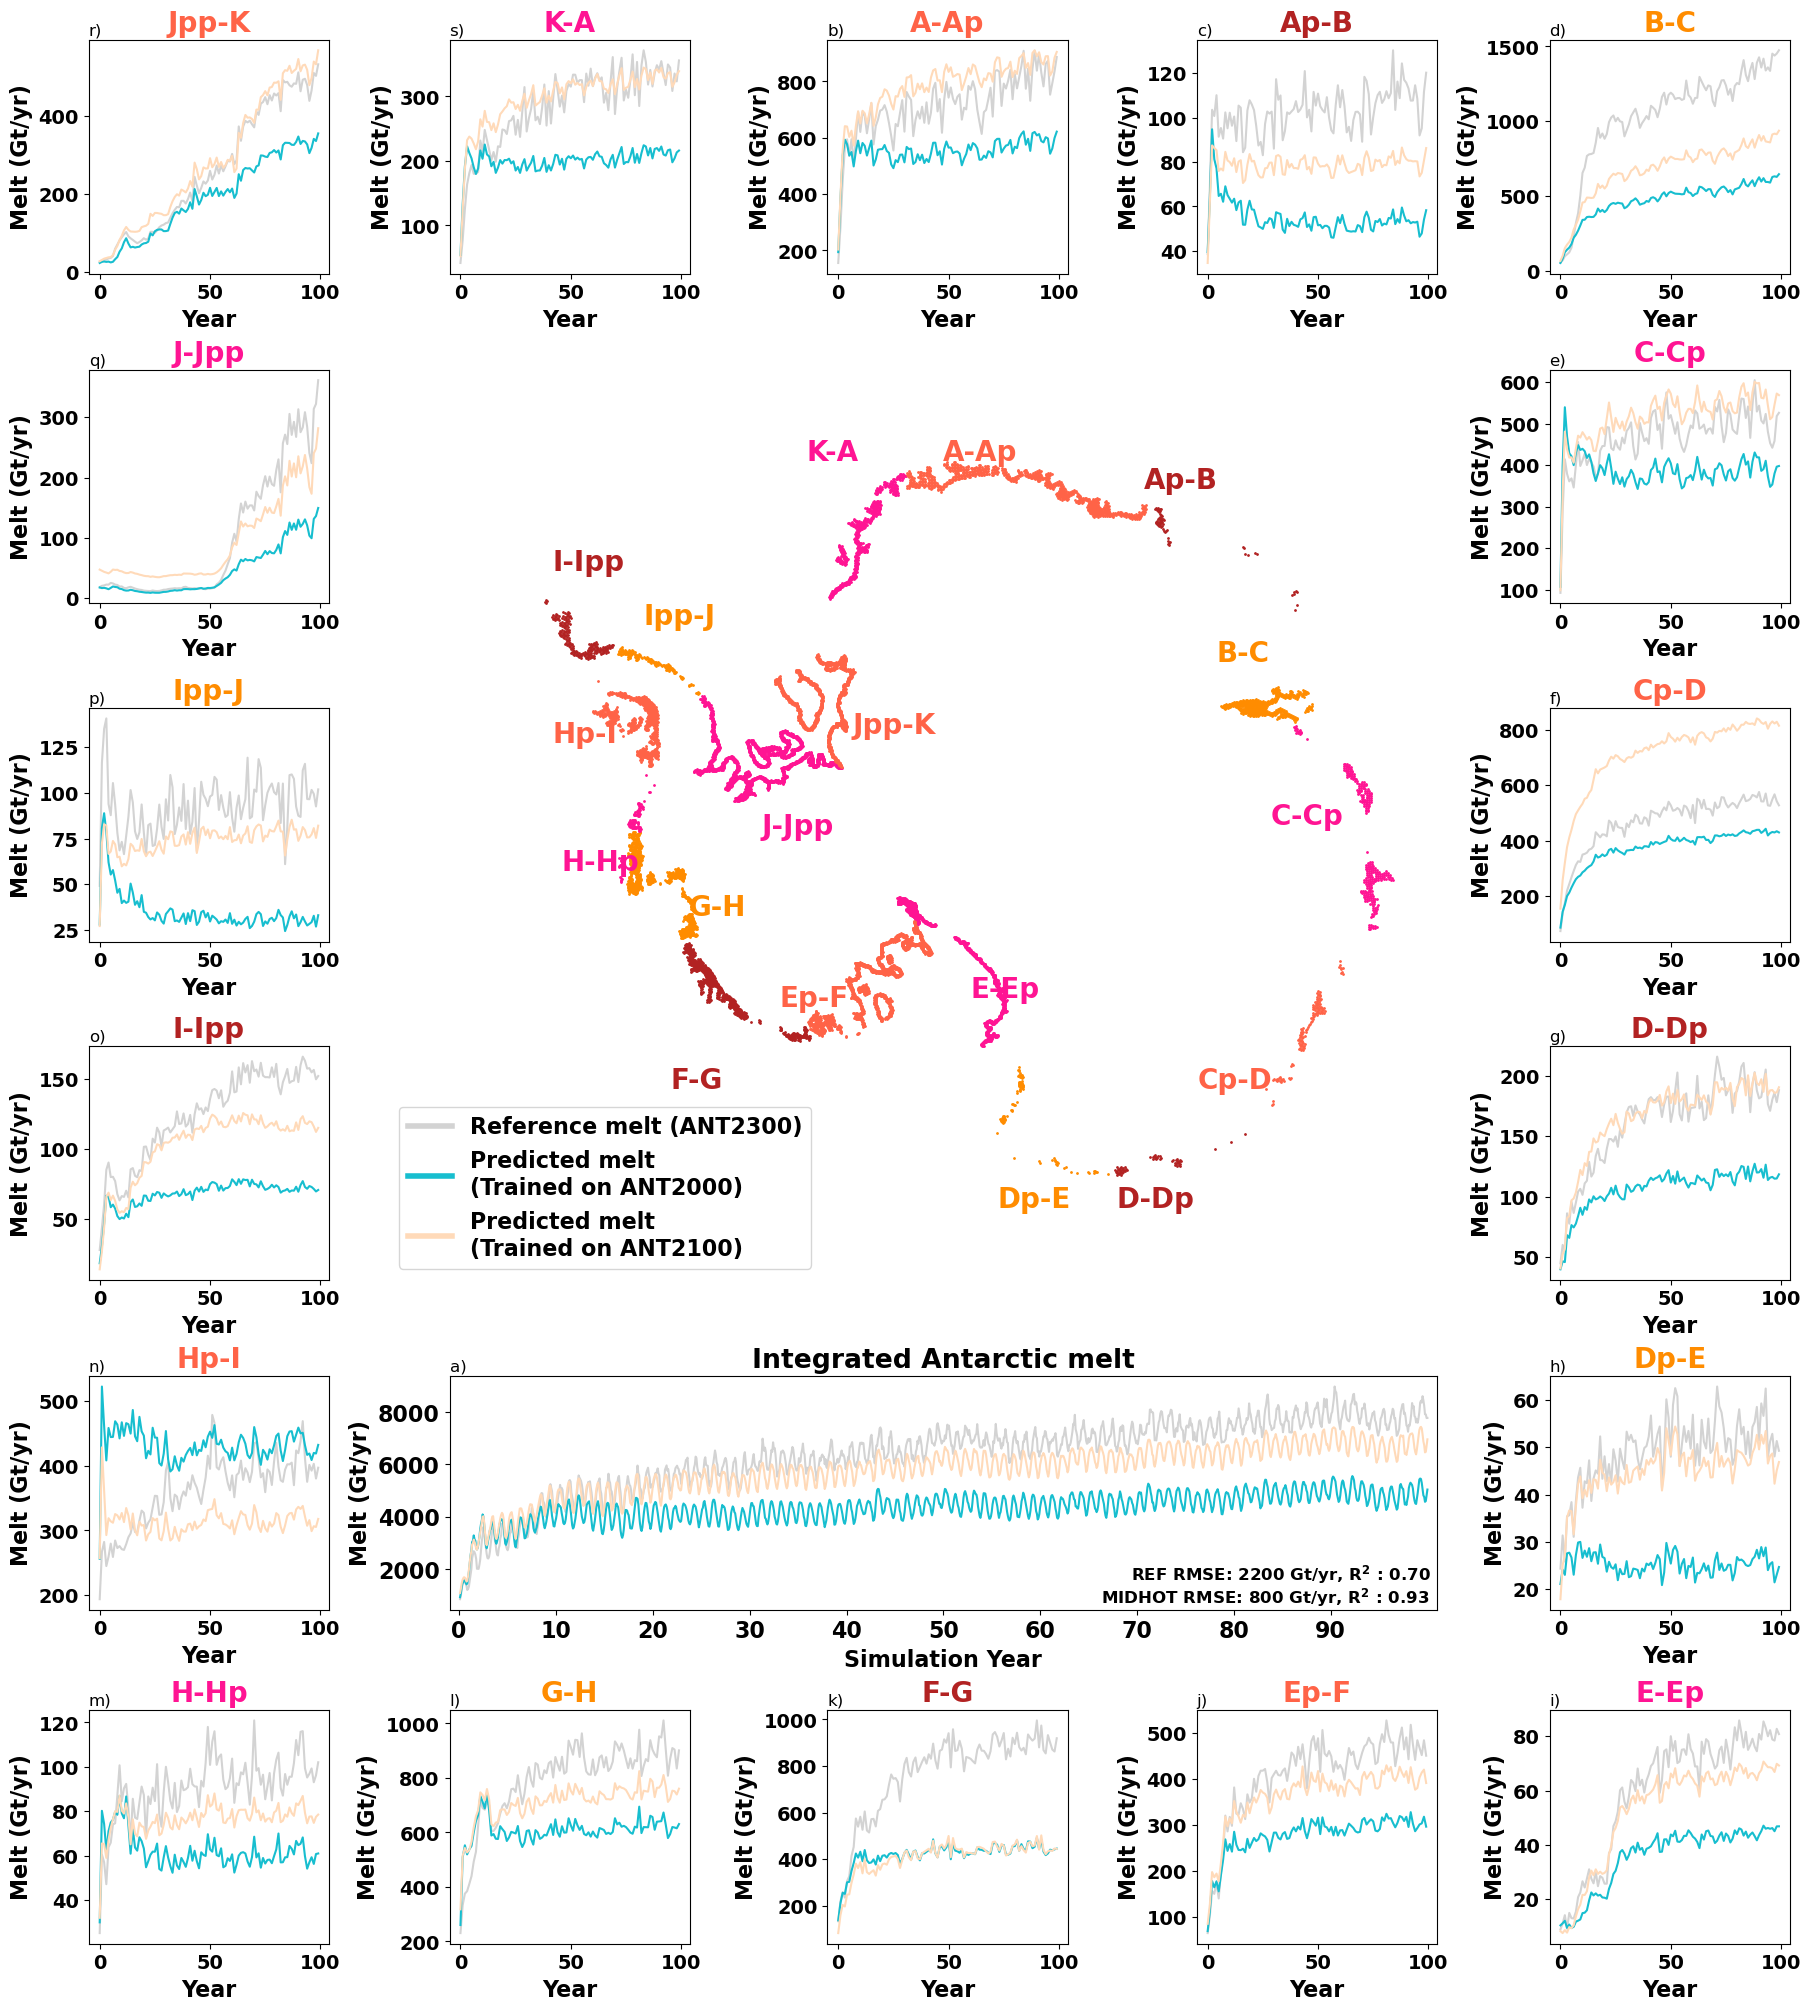

In [15]:
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    axs = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
    fig = plt.figure(constrained_layout=True, figsize = (18,20))
    widths = [4,4,4,4,4]
    heights = [4,4,4,4,4,4]
    gs = fig.add_gridspec(6,5, width_ratios = widths, height_ratios = heights)
    #for i,j in itertools.product(range(6),range(5)):
    #    fig.add_subplot(gs[i,j])
    
    titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
              'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
              'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
              'Ipp-J', 'J-Jpp', 'Jpp-K']
    coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
              (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
              (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
              (0.3,0.49), (0.4,0.60)]
    
    axs[17] = fig.add_subplot(gs[1:4,1:4], projection= proj)
    axs[17].set_extent( (-180, 180, -88, -65), trans )
    for i in range(len(regions)):
        for j in range(len(regions[i])):
            basin = latlonbasin[latlonbasin.basin == regions[i][j]]
            im = axs[17].scatter(basin.lon, basin.lat, c = colors[np.mod(i,4)], \
                       transform = trans, s= 1)    
        axs[17].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                       fontsize = 20, color = colors[np.mod(i,4)])
    
    axs[17].axis('off')

    plot_i = [0,0,0,0,1,2,3,4,5,5,5,5,5,4,3,2,1,0]
    plot_j = [1,2,3,4,4,4,4,4,4,3,2,1,0,0,0,0,0,0]
    xytexts = [(0.4,0.8), (0.4,0.8), (0.03,0.03), (0.4,0.03), (0.03,0.8), (0.03,0.8), 
               (0.4,0.8), (0.03,0.8), (0.03,0.8), (0.03,0.8), (0.03,0.03), (0.4,0.8),  
               (0.4,0.8), (0.03,0.8), (0.4,0.8), (0.03,0.8), (0.4,0.8), (0.4,0.8)]
    plt_labels = ['s)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)', 'j)', 'k)', 'l)', 'm)', 'n)', 'o)', 'p)', 'q)', 'r)'] 
    for i in range(18):
        axs[i] = fig.add_subplot(gs[plot_i[i], plot_j[i]])

    bym = df_26_ymb
    for i in range(18):
        mask = np.in1d(bym.basin, regions[i])
        bym2 = bym[mask].groupby(['year'], as_index = False).sum()
        axs[i].plot(bym2.year-np.min(bym2.year), -bym2.melt_Gt_per_y/12, color = 'lightgrey')
        axs[i].plot(bym2.year-np.min(bym2.year), -bym2.melt_pred_Gt/12, color = 'C9')
        axs[i].set_title(titles[i], fontsize = 20, fontweight = 'bold', color = colors[np.mod(i,4)])
        axs[i].tick_params(axis='both', which='major', labelsize=14)

    bym = df_Ch_ymb
    for i in range(18):
        mask = np.in1d(bym.basin, regions[i])
        bym2 = bym[mask].groupby(['year'], as_index = False).sum()
        axs[i].plot(bym2.year-np.min(bym2.year), bym2.melt_pred_Gt/12, color = 'peachpuff')
        #RMSE = twosigfig(RMSE)
        axs[i].set_xlabel('Year')
        axs[i].set_ylabel('Melt (Gt/yr)')
    #    axs[i].set_xticks((0,10,20,30))
    #    axs[i].annotate('RMSE: {} Gt/yr\nR$^2$ : {:.2f}'.format(RMSE, R2), xytext = xytexts[i], xy = (0,0), \
    #                    xycoords = 'axes fraction', fontsize = 12)
        label = plt_labels[i]
        axs[i].annotate(label, xytext = (0,1.02), xy = (0,0), \
                        xycoords = 'axes fraction', fontsize = 12, fontweight = 'normal')

    axs[18] = fig.add_subplot(gs[4,1:4])
    axs[18].set_title('Integrated Antarctic melt', fontweight = 'bold')
    axs[18].set_xlabel('Year')
    axs[18].set_ylabel('Melt (Gt/yr)')

    

    
    df_z = df2
    ticks, labels = ticks_labels(df_z)    
    ax = axs[18]
    ax.plot(df_z.year + df_z.month/12, -df_z.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (HOT2300)', zorder = 0)
    plot_monthly_trend(df_z, 'C9', label = 'Predicted melt\n(Trained on REF annual)', ax = ax, \
                       std = False, label_std = '$\\pm1\\sigma$')
    RMSE = np.sqrt(np.mean((df_z.melt_Gt_per_y- df_z.melt_pred_Gt)**2))
    R2 = regression_analysis(df_z.melt_Gt_per_y,df_z.melt_pred_Gt)[2]
    RMSE = twosigfig(RMSE)
    ax.annotate('REF RMSE: {} Gt/yr, R$^2$ : {:.2f}'.format(RMSE, R2), xytext = (0.69,0.13), xy = (0,0), \
                        xycoords = 'axes fraction', fontsize = 12)
    
    df_z = df_c
    plot_monthly_trend(df_z, 'peachpuff', label = 'Predicted melt\n(Trained on MIDHOT annual)', ax = ax, \
                       std = False, label_std = '$\\pm1\\sigma$', flip = True)
    RMSE = np.sqrt(np.mean((df_z.melt_Gt_per_y+ df_z.melt_pred_Gt)**2))
    R2 = regression_analysis(df_z.melt_Gt_per_y,-df_z.melt_pred_Gt)[2]
    RMSE = twosigfig(RMSE)
    ax.annotate('MIDHOT RMSE: {} Gt/yr, R$^2$ : {:.2f}'.format(RMSE, R2), xytext = (0.66,0.03), xy = (0,0), \
                        xycoords = 'axes fraction', fontsize = 12)
    
    ax.set_xlabel('Simulation Year', fontsize = 16)
    ax.set_ylabel('Melt (Gt/yr)', fontsize = 16)
    ax.set_xlim(np.min(np.unique(df_z.year))-1, np.max(np.unique(df_z.year))+2)
    ax.set_xticks(ticks, labels)
    #i = 16
    #mask = np.in1d(bym.basin, regions[i])
    #bym2 = bym[~mask].groupby(['year'], as_index = False).sum()
    label = 'a)'
    ax.annotate(label, xytext = (0,1.02), xy = (0,0), \
                        xycoords = 'axes fraction', fontsize = 12, fontweight = 'normal')

    axs[19] = fig.add_subplot(gs[3,1:3])
    ax = axs[19]
    ax.plot(df_z.year + df_z.month/12, -df_z.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (ANT2300)', zorder = 0)
    ax.plot(df_z.year + df_z.month/12, -df_z.melt_Gt_per_y, color = 'C9', label = 'Predicted melt\n(Trained on ANT2000)', zorder = 0)
    ax.plot(df_z.year + df_z.month/12, -df_z.melt_Gt_per_y, color = 'peachpuff', label = 'Predicted melt\n(Trained on ANT2100)', zorder = 0)
    leg = ax.legend(fontsize = 16, loc = 'lower left', bbox_to_anchor = [-0.1,0,0.8,1])
    for line in leg.get_lines():
        line.set_linewidth(4.0)
    ax.set_xlim(-20,-10)
    ax.axis('off')
    
    plt.show()

    fig.savefig('FIGURES/Basin_melt_OPM031.png', dpi = 200, bbox_inches = 'tight')

In [16]:
df_26c = \
    load_results_nn(this_collection_NN = 'OPM026', this_collection_apply = 'Christoph_v2_whole_dataset', path_model = path_model, \
                   load_ym_only = False)[0]
print('Loaded')
df_31c = \
    load_results_nn(this_collection_NN = 'OPM031', this_collection_apply = 'Christoph_v2_whole_dataset', path_model = path_model, \
                   load_ym_only = False)[0]
print('Loaded')

Loaded
Loaded


In [17]:
df_26c_bym = df_26c.groupby(['basin', 'year','month'], as_index = False).sum()
df_31c_bym = df_31c.groupby(['basin', 'year','month'], as_index = False).sum()

In [20]:
df_26c_bym = df_26c_bym[['basin', 'year', 'month', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt']]
df_31c_bym = df_31c_bym[['basin', 'year', 'month', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt']]

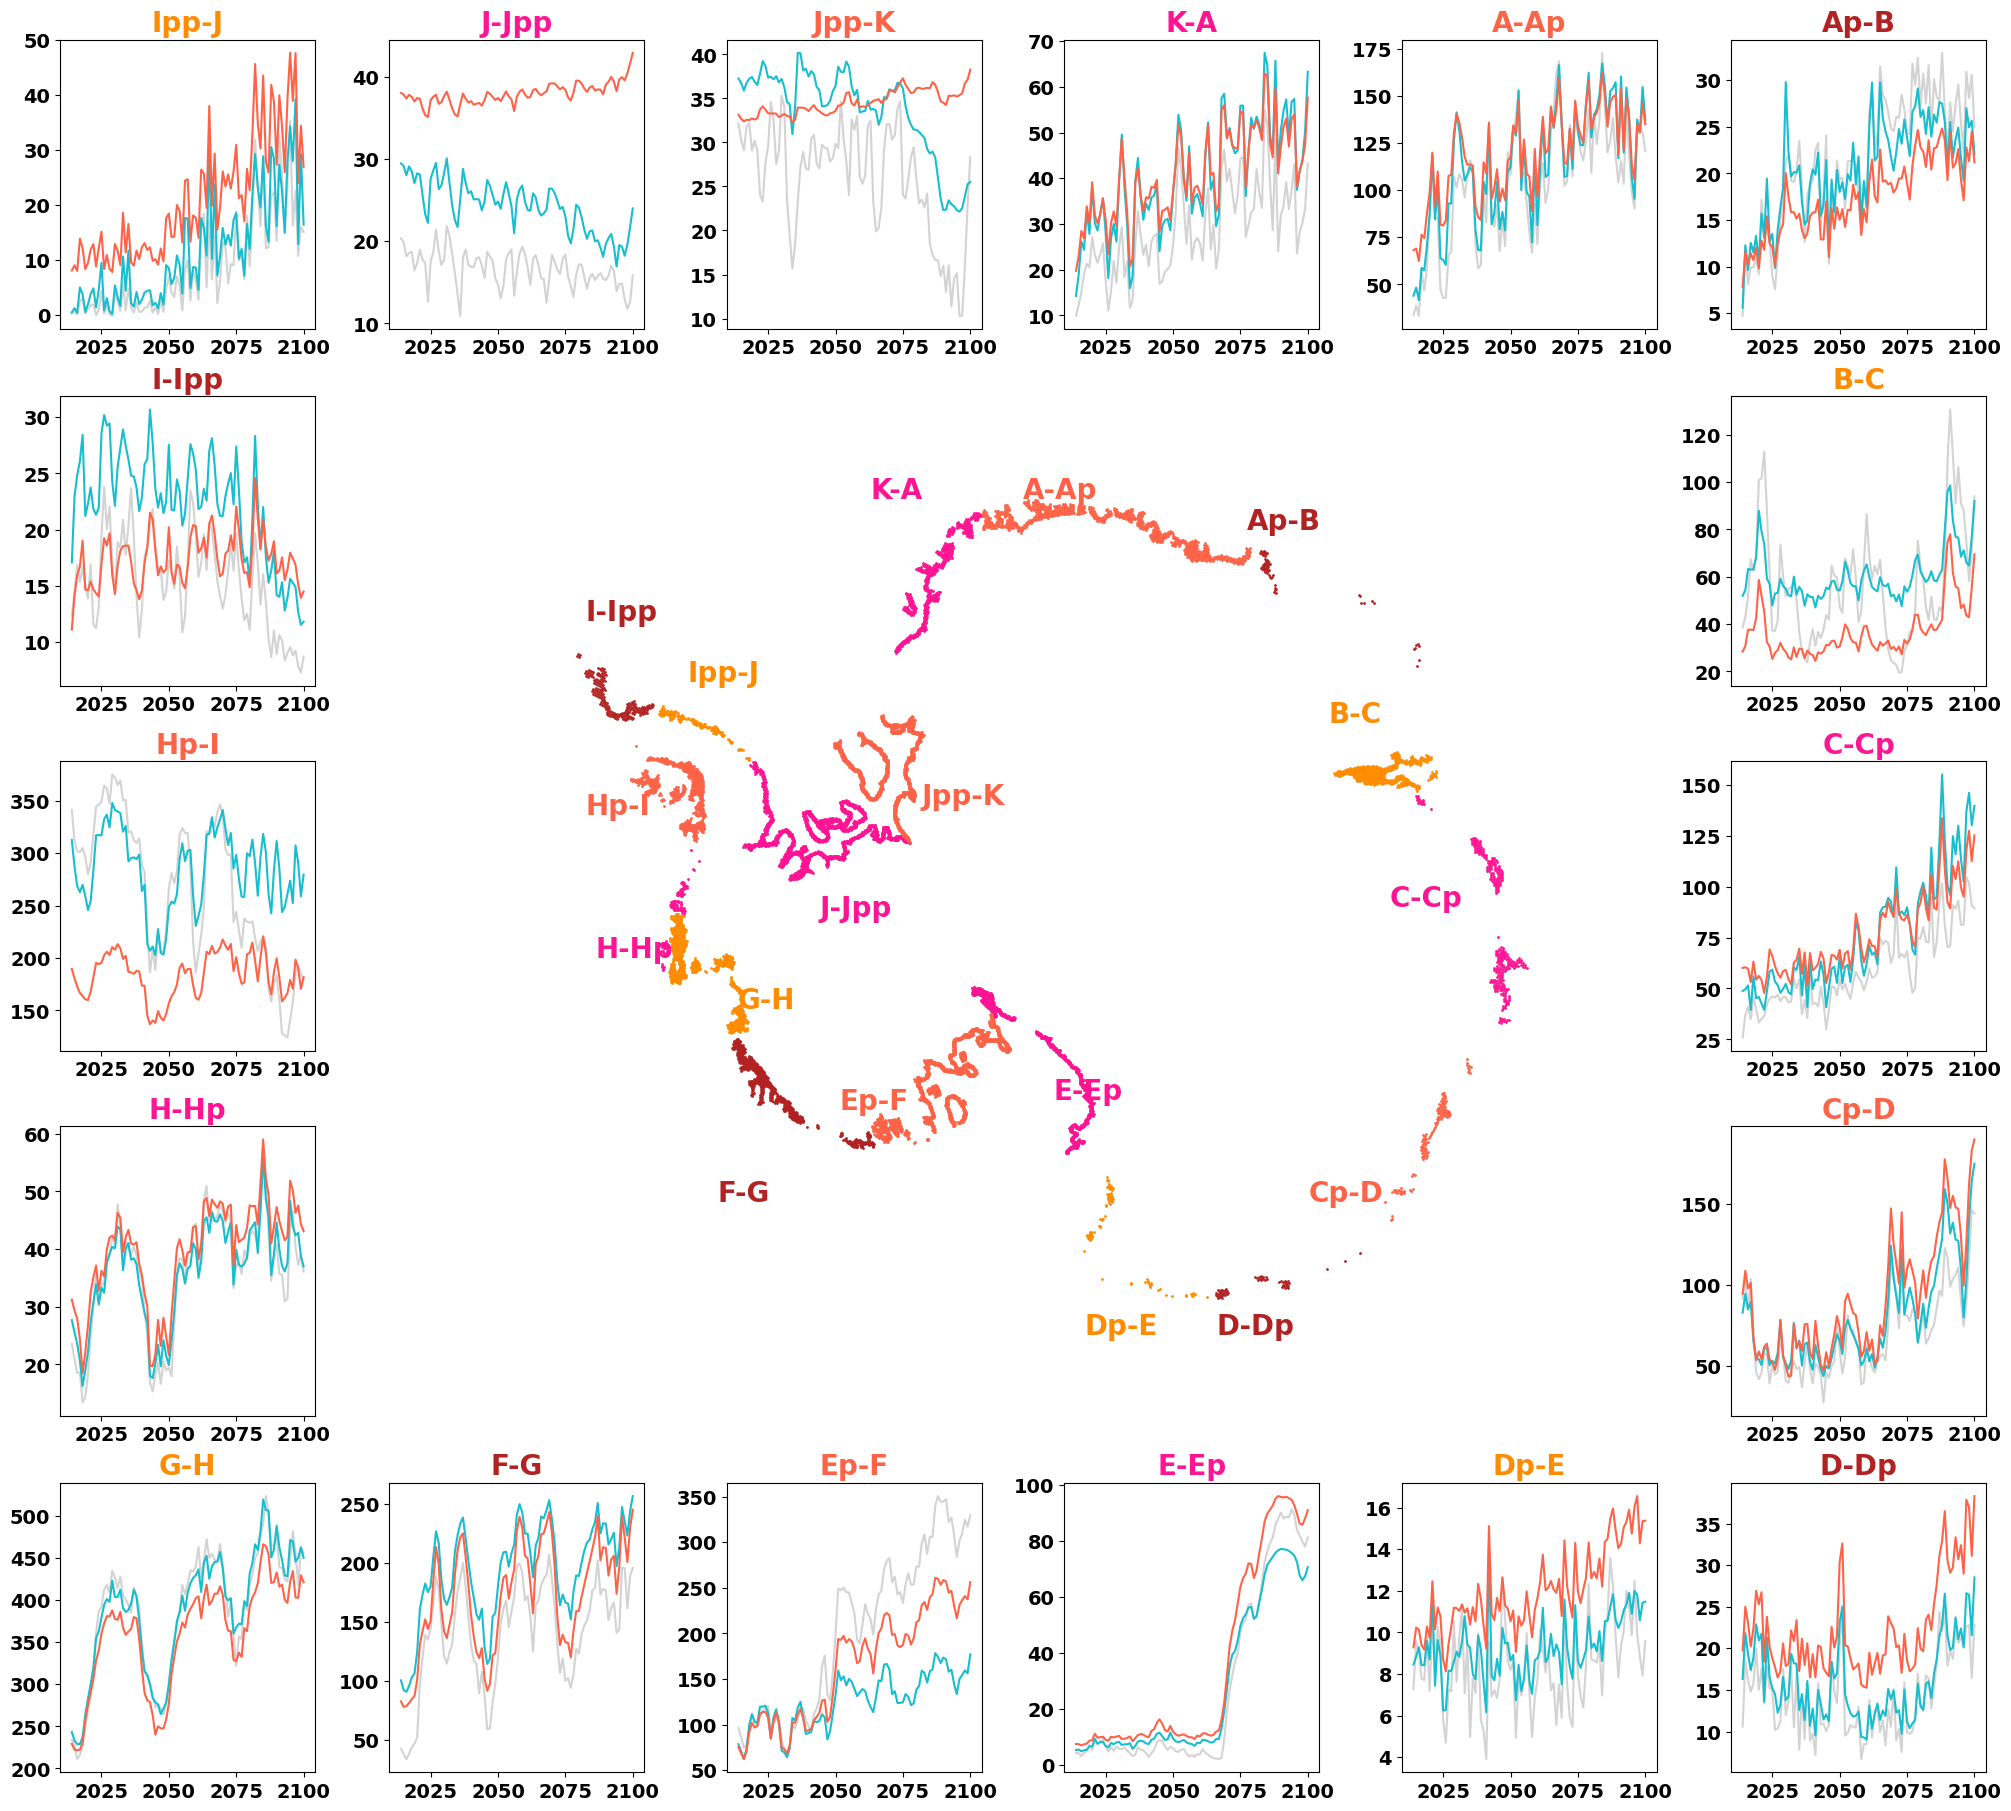

In [18]:
#with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
#                    'axes.labelcolor':'#0879B8', 'axes.titlecolor':'#0879B8'}):
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
#with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
#                    'axes.labelcolor':'#0879B8', 'figure.facecolor': '#c5eaff', 'axes.facecolor': 'white'}):
    ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
    fig = plt.figure(constrained_layout=True, figsize = (20,18))
    widths = [4,4,4,4,4,4]
    heights = [4,4,4,4,4]
    gs = fig.add_gridspec(5,6, width_ratios = widths, height_ratios = heights)
    #for i,j in itertools.product(range(5),range(6)):
    #    fig.add_subplot(gs[i,j])
    
    
    titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
              'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
              'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
              'Ipp-J', 'J-Jpp', 'Jpp-K']
    coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
              (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
              (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
              (0.3,0.49), (0.4,0.60)]
    
    ax[17] = fig.add_subplot(gs[1:4,1:5], projection= proj)
    ax[17].set_extent( (-180, 180, -88, -65), trans )
    #im = ax[17].pcolormesh(lon2d,lat2d,ocean2, vmin = -0.1, vmax = 0.9, rasterized=False, cmap = 'Blues_r', transform=trans, alpha = 1)
    
    
    for i in range(len(regions)):
        for j in range(len(regions[i])):
            #mask = [latlonbasin_m.basin.values == regions[i][j]][0]
            #plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = colors[np.mod(i,3)])
            basin = latlonbasin[latlonbasin.basin == regions[i][j]]
            im = ax[17].scatter(basin.lon, basin.lat, c = colors[np.mod(i,4)], \
                       transform = trans, s= 1)    
        ax[17].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                       fontsize = 20, color = colors[np.mod(i,4)])
    
    ax[17].axis('off')
    
    plot_i = [0,0,0,1,2,3,4,4,4,4,4,4,3,2,1,0,0,0]
    plot_j = [3,4,5,5,5,5,5,4,3,2,1,0,0,0,0,0,1,2]
    for i in range(18):
        ax[i] = fig.add_subplot(gs[plot_i[i], plot_j[i]])

    bym = df_26c_bym
    for i in range(18):
        mask = np.in1d(bym.basin, regions[i])
        bym2 = bym[mask].groupby(['year'], as_index = False).sum()
        ax[i].plot(bym2.year, bym2.melt_Gt_per_y/12, color = 'lightgrey')
        ax[i].plot(bym2.year, -bym2.melt_pred_Gt/12, color = 'C9')
        ax[i].set_title(titles[i], fontsize = 20, fontweight = 'bold', color = colors[np.mod(i,4)])
        ax[i].tick_params(axis='both', which='major', labelsize=14)

    bym = df_31c_bym
    for i in range(18):
        mask = np.in1d(bym.basin, regions[i])
        bym2 = bym[mask].groupby(['year'], as_index = False).sum()
        ax[i].plot(bym2.year, -bym2.melt_pred_Gt/12, color = 'tomato') 
        
plt.show()
fig.savefig('FIGURES/Basin_melt_Christoph.png', dpi = 200, bbox_inches = 'tight')

In [ ]:
# Keeping this in case something goes wrong

#with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
#                    'axes.labelcolor':'#0879B8', 'axes.titlecolor':'#0879B8'}):
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
#with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
#                    'axes.labelcolor':'#0879B8', 'figure.facecolor': '#c5eaff', 'axes.facecolor': 'white'}):
    ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
    fig = plt.figure(constrained_layout=True, figsize = (20,18))
    widths = [4,4,4,4,4,4]
    heights = [4,4,4,4,4]
    gs = fig.add_gridspec(5,6, width_ratios = widths, height_ratios = heights)
    #for i,j in itertools.product(range(5),range(6)):
    #    fig.add_subplot(gs[i,j])
    
    
    titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
              'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
              'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
              'Ipp-J', 'J-Jpp', 'Jpp-K']
    coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
              (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
              (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
              (0.3,0.49), (0.4,0.60)]
    
    ax[17] = fig.add_subplot(gs[1:4,1:5], projection= proj)
    ax[17].set_extent( (-180, 180, -88, -65), trans )
    #im = ax[17].pcolormesh(lon2d,lat2d,ocean2, vmin = -0.1, vmax = 0.9, rasterized=False, cmap = 'Blues_r', transform=trans, alpha = 1)
    
    
    for i in range(len(regions)):
        for j in range(len(regions[i])):
            #mask = [latlonbasin_m.basin.values == regions[i][j]][0]
            #plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = colors[np.mod(i,3)])
            basin = latlonbasin[latlonbasin.basin == regions[i][j]]
            im = ax[17].scatter(basin.lon, basin.lat, c = colors[np.mod(i,4)], \
                       transform = trans, s= 1)    
        ax[17].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                       fontsize = 20, color = colors[np.mod(i,4)])
    
    ax[17].axis('off')
    
    plot_i = [0,0,0,1,2,3,4,4,4,4,4,4,3,2,1,0,0,0]
    plot_j = [3,4,5,5,5,5,5,4,3,2,1,0,0,0,0,0,1,2]
    for i in range(18):
        ax[i] = fig.add_subplot(gs[plot_i[i], plot_j[i]])

    df_z = df_26c
    bym = df_z.groupby(['basin', 'year','month'], as_index = False).sum()
    for i in range(18):
        mask = np.in1d(bym.basin, regions[i])
        bym2 = bym[mask].groupby(['year'], as_index = False).sum()
        ax[i].plot(bym2.year, bym2.melt_Gt_per_y/12, color = 'lightgrey')
        ax[i].plot(bym2.year, -bym2.melt_pred_Gt/12, color = 'C9')
        ax[i].set_title(titles[i], fontsize = 20, fontweight = 'bold', color = colors[np.mod(i,4)])
        ax[i].tick_params(axis='both', which='major', labelsize=14)
    df_z = df_31c
    bym = df_z.groupby(['basin', 'year','month'], as_index = False).sum()
    for i in range(18):
        mask = np.in1d(bym.basin, regions[i])
        bym2 = bym[mask].groupby(['year'], as_index = False).sum()
        ax[i].plot(bym2.year, -bym2.melt_pred_Gt/12, color = 'tomato') 
        
plt.show()
fig.savefig('FIGURES/Basin_melt_Christoph.png', dpi = 200, bbox_inches = 'tight')

# Try here 

In [5]:
df_26on263_all = \
    load_results_nn(this_collection_NN = 'OPM026', this_collection_apply = 'OPM0263_whole_dataset', path_model = path_model, \
                   load_ym_only = False)[0]
print('Loaded')
#df_31c = \
#    load_results_nn(this_collection_NN = 'OPM031', this_collection_apply = 'Christoph_v2_whole_dataset', path_model = path_model, \
#                   load_ym_only = False)[0]
#print('Loaded')

Loaded


In [6]:
mask_26on263 = (df_26on263_all.year > 1980)

In [7]:
df_z = df_26on263_all
latlonbasin = df_z.groupby(['lat','lon'], as_index = False).mean()

latlonbasin_m = latlonbasin.groupby('basin', as_index = False).mean()
latlonbasin_m = latlonbasin_m.drop(['area','year','month', 'melt_m_ice_per_y', 'melt_01', 'melt_02', 'melt_03', 'melt_04', 'melt_05', 'melt_06',\
                   'melt_07', 'melt_08', 'melt_09', 'melt_10', 'melt_pred_mean', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt'], axis = 1)

colors = ['deeppink', 'tomato', 'firebrick', 'darkorange']
regions = [[2,153,3,6,7,4],\
           [8,9,12,11,14,13,15],\
           [16,17,18,19,128,22],\
           [103,154],\
           [21,23,24,25,26,27,28],\
           [29,30,31,32,33,34,35,36,37,38],\
           [40,41,42,43,44],\
           [45,97,94,95,69,70,89,88,92,93,91,90,87,46,47],\
           [136,137,62,68,67,66,65,64,63,61,60,59],\
           [57,58,71,72,73,138,140,139,81,80,79,78,104],\
           [105,49,132,141,108,142],\
           [129,101,51,50,107,130,52,143],\
           [144,145,146,110,55,56,133,134],\
           [111,125,124,127,126,100],\
           [113,122,115,116],\
           [147,119,117,77,118],\
           [120,76,75,74,86,99,98,85,150,149,148,155],\
           [1,84,121,83,82,135,152,151]]

In [10]:
titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
              'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
              'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
              'Ipp-J', 'J-Jpp', 'Jpp-K']
coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
              (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
              (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
              (0.3,0.49), (0.4,0.60)]

In [16]:
df_z = df_26on263_all[mask_26on263]
bym = df_z.groupby(['basin', 'year','month'], as_index = False).sum()
ym = df_z.groupby(['year','month'], as_index = False).mean()
df_26on263_trim = bym[['basin', 'year', 'month', 'melt_Gt_per_y', 'melt_pred_Gt', 'std_Gt']]

In [17]:
fp_data = 'Figure_data/'
df_26on263_trim.to_csv(fp_data + 'df_26on263_trim.csv', index = False)
df_26on263_trim = pd.read_csv(fp_data+ 'df_26on263_trim.csv')


In [21]:
df_26on263_ym = bym.groupby(['year','month'],as_index = False).sum()

In [8]:
def twosigfig(a):
    if a > 10:
        return '{:.0f}'.format(np.floor(a/(10 ** (np.floor(np.log10(a))-1))) *  (10 ** (np.floor(np.log10(a))-1)))
    elif (a>1) & (a <10):
        return '{:.1f}'.format(a)
    elif (a < 1):
        return '{:.2f}'.format(a)

/tmp/ipykernel_2909759/2776153611.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(fontsize = 16, loc = 'lower left', bbox_to_anchor = [-0.1,0,0.8,1])


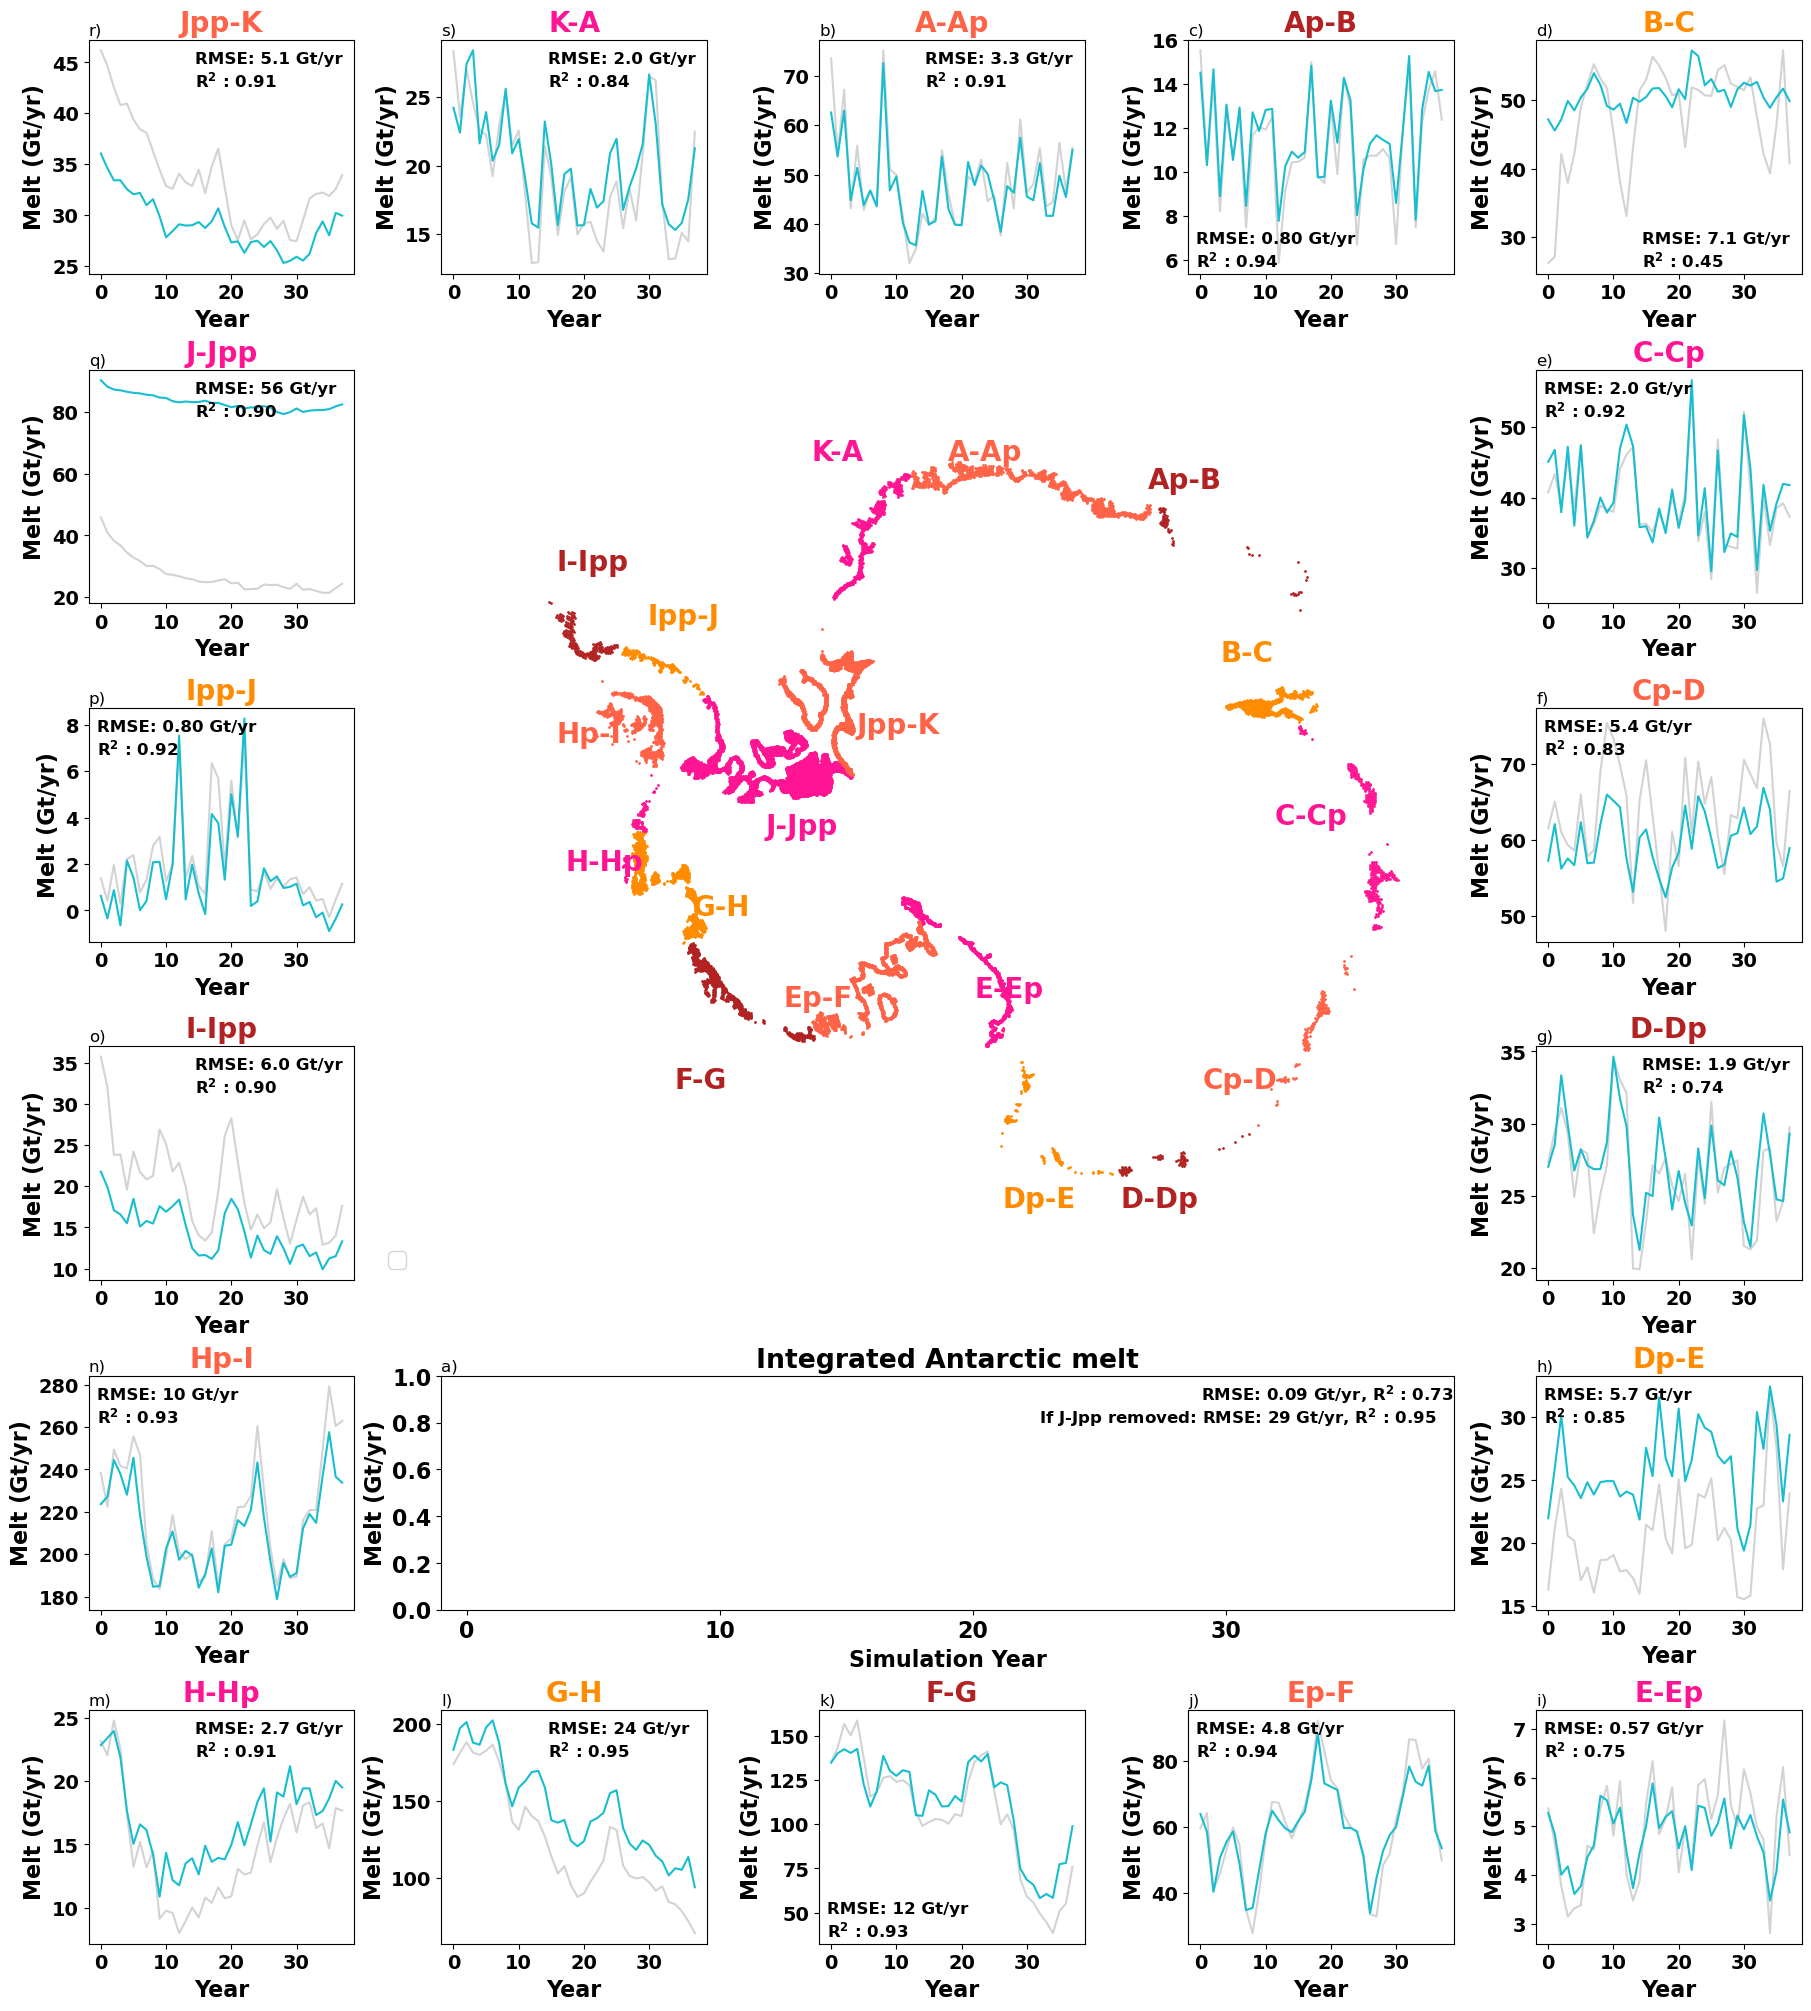

In [14]:
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    axs = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
    fig = plt.figure(constrained_layout=True, figsize = (18,20))
    widths = [4,4,4,4,4]
    heights = [4,4,4,4,4,4]
    gs = fig.add_gridspec(6,5, width_ratios = widths, height_ratios = heights)
    #for i,j in itertools.product(range(6),range(5)):
    #    fig.add_subplot(gs[i,j])
    
    axs[17] = fig.add_subplot(gs[1:4,1:4], projection= proj)
    axs[17].set_extent( (-180, 180, -88, -65), trans )
    for i in range(len(regions)):
        for j in range(len(regions[i])):
            basin = latlonbasin[latlonbasin.basin == regions[i][j]]
            im = axs[17].scatter(basin.lon, basin.lat, c = colors[np.mod(i,4)], \
                       transform = trans, s= 1)    
        axs[17].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                       fontsize = 20, color = colors[np.mod(i,4)])
    
    axs[17].axis('off')

    plot_i = [0,0,0,0,1,2,3,4,5,5,5,5,5,4,3,2,1,0]
    plot_j = [1,2,3,4,4,4,4,4,4,3,2,1,0,0,0,0,0,0]
    xytexts = [(0.4,0.8), (0.4,0.8), (0.03,0.03), (0.4,0.03), (0.03,0.8), (0.03,0.8), 
               (0.4,0.8), (0.03,0.8), (0.03,0.8), (0.03,0.8), (0.03,0.03), (0.4,0.8),  
               (0.4,0.8), (0.03,0.8), (0.4,0.8), (0.03,0.8), (0.4,0.8), (0.4,0.8)]
    plt_labels = ['s)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)', 'j)', 'k)', 'l)', 'm)', 'n)', 'o)', 'p)', 'q)', 'r)'] 
    for i in range(18):
        axs[i] = fig.add_subplot(gs[plot_i[i], plot_j[i]])

    df_z = df_26on263_all[mask_26on263]
    bym = df_z.groupby(['basin', 'year','month'], as_index = False).sum()
    for i in range(18):
        mask = np.in1d(bym.basin, regions[i])
        bym2 = bym[mask].groupby(['year'], as_index = False).sum()
        RMSE = np.sqrt(np.mean((bym2.melt_Gt_per_y/12- bym2.melt_pred_Gt/12)**2))
        R2 = regression_analysis(bym2.melt_Gt_per_y,bym2.melt_pred_Gt)[2]
        RMSE = twosigfig(RMSE)
        axs[i].plot(bym2.year-np.min(bym2.year), -bym2.melt_Gt_per_y/12, color = 'lightgrey')
        axs[i].plot(bym2.year-np.min(bym2.year), -bym2.melt_pred_Gt/12, color = 'C9')
        axs[i].set_title(titles[i], fontsize = 20, fontweight = 'bold', color = colors[np.mod(i,4)])
        axs[i].tick_params(axis='both', which='major', labelsize=14)
        axs[i].set_xlabel('Year')
        axs[i].set_ylabel('Melt (Gt/yr)')
        axs[i].set_xticks((0,10,20,30))
        axs[i].annotate('RMSE: {} Gt/yr\nR$^2$ : {:.2f}'.format(RMSE, R2), xytext = xytexts[i], xy = (0,0), \
                        xycoords = 'axes fraction', fontsize = 12)
        label = plt_labels[i]
        axs[i].annotate(label, xytext = (0,1.02), xy = (0,0), \
                        xycoords = 'axes fraction', fontsize = 12, fontweight = 'normal')

    axs[18] = fig.add_subplot(gs[4,1:4])
    axs[18].set_title('Integrated Antarctic melt', fontweight = 'bold')
    axs[18].set_xlabel('Year')
    axs[18].set_ylabel('Melt (Gt/yr)')

    mask = df_26on263_all.year > 1980
    df_z = df_26on263_all[mask]
    ticks, labels = ticks_labels(df_z)    
    ax = axs[18]
    #ax.plot(df_z.year + df_z.month/12, -df_z.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (GEOM)', zorder = 0)
    #plot_monthly_trend(df_z, 'C9', label = 'Predicted melt (Trained on REF annual)', ax = ax, \
    #                   std = True, label_std = '$\\pm1\\sigma$')
    ax.set_xlabel('Simulation Year', fontsize = 16)
    ax.set_ylabel('Melt (Gt/yr)', fontsize = 16)
    ax.set_xlim(np.min(np.unique(df_z.year))-1, np.max(np.unique(df_z.year))+2)
    ax.set_xticks(ticks, labels)
    RMSE = np.sqrt(np.mean((df_z.melt_Gt_per_y- df_z.melt_pred_Gt)**2))
    R2 = regression_analysis(df_z.melt_Gt_per_y,df_z.melt_pred_Gt)[2]
    RMSE = twosigfig(RMSE)
    ax.annotate('RMSE: {} Gt/yr, R$^2$ : {:.2f}'.format(RMSE, R2), xytext = (0.75,0.9), xy = (0,0), \
                        xycoords = 'axes fraction', fontsize = 12)
    i = 16
    mask = np.in1d(bym.basin, regions[i])
    bym2 = bym[~mask].groupby(['year'], as_index = False).sum()
    RMSE = np.sqrt(np.mean((bym2.melt_Gt_per_y/12- bym2.melt_pred_Gt/12)**2))
    R2 = regression_analysis(bym2.melt_Gt_per_y,bym2.melt_pred_Gt)[2]
    RMSE = twosigfig(RMSE)
    ax.annotate('If J-Jpp removed: RMSE: {} Gt/yr, R$^2$ : {:.2f}'.format(RMSE, R2), xytext = (0.59,0.8), xy = (0,0), \
                        xycoords = 'axes fraction', fontsize = 12)
    label = 'a)'
    ax.annotate(label, xytext = (0,1.02), xy = (0,0), \
                        xycoords = 'axes fraction', fontsize = 12, fontweight = 'normal')

    axs[19] = fig.add_subplot(gs[3,1:3])
    ax = axs[19]
    #ax.plot(df_z.year + df_z.month/12, -df_z.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt (GEOM)', zorder = 0)
    #ax.plot(df_z.year + df_z.month/12, -df_z.melt_Gt_per_y, color = 'C9', label = 'Predicted melt (Trained on REF)', zorder = 0)
    leg = ax.legend(fontsize = 16, loc = 'lower left', bbox_to_anchor = [-0.1,0,0.8,1])
    for line in leg.get_lines():
        line.set_linewidth(4.0)
    ax.set_xlim(-20,-10)
    ax.axis('off')
    
    plt.show()

    fig.savefig('FIGURES/Basin_melt_GEOM.png', dpi = 200, bbox_inches = 'tight')

In [ ]:
nemo_run = 'OPM026'
filepath_mesh_mask = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/eORCA025.L121-'+nemo_run+'_mesh_mask.nc'

In [ ]:
nemo_run = 'OPM026'
geom_26 = xr.load_dataset('/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/'+nemo_run+'_geom_vars.nc')

nemo_run = 'OPM0263'
geom_263 = xr.load_dataset('/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/Masks/'+nemo_run+'_geom_vars.nc')

In [ ]:
im = plt.pcolor(geom_26.isf_draft - geom_263.isf_draft, cmap = 'coolwarm')
plt.colorbar()
im.set_clim(-500,500)
plt.show()

In [ ]:
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, ax = plt.subplots(1,1, figsize = (20,6))
    ax.plot(df3_ym.year + df3_ym.month/12, -df3_ym.melt_Gt_per_y, color = 'grey', label = 'Reference melt MIDHOT')
    ax.plot(df3_ym.year + df3_ym.month/12, -df3_ym.melt_pred_Gt, color = 'orange', label = 'Predicted melt MIDHOT')
    ax.plot(df3_ym.year + df3_ym.month/12, df4_ym.melt_pred_Gt, color = 'lightblue', label = 'Predicted melt HOT2300')
    ax.set_xlabel('Model Year', fontsize = 16)
    ax.set_ylabel('Integrated melt (Gt/yr)', fontsize = 16)
    ax.set_xticks(np.arange(2014, 2100,10), labels = np.arange(0,81,10))
    ax.legend(fontsize = 16, loc = 3)
  #  fig.savefig('FIGURES/Integrated_melt.pdf')
 #   ax.set_ylim(-9000,-500)

In [ ]:
basin_nos = np.unique(df_ref_pred.basin)

In [ ]:
df_ymb = df_ref_pred.groupby(['year','month', 'basin'], as_index = False).sum()
df_yb = df_ref_pred.groupby(['year', 'basin'], as_index = False).sum()

In [ ]:
df_ym = df_ref_pred.groupby(['year','month'], as_index = False).sum()

In [ ]:
df_y = df_ym.groupby('year', as_index = False).mean()

In [ ]:
df_m = df_ym.groupby('month', as_index = False).mean()

In [ ]:
plt.plot(df_m.month, df_m.melt_pred_Gt, color = 'orange')
plt.plot(df_m.month, df_m.melt_Gt_per_y, color = 'grey')

In [ ]:
#import matplotlib
#matplotlib.rc('axes',edgecolor='black', facecolor = 'white')

In [ ]:
#plt.rcParams

In [ ]:
np.arange(1984, 2019,2)

In [ ]:

with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
                    'axes.labelcolor':'#0879B8'}):
    fig, ax = plt.subplots(1,1, figsize = (20,5))   
    ax.plot(df_ym.year+df_ym.month/12, df_ym.melt_Gt_per_y-df_ym.melt_pred_Gt, color = 'orange', label = 'Predicted melt')
    #ax.set_xlim(1983.5,2019.5)
    ax.set_xlabel('Year', fontsize = 16)
    ax.set_ylabel('Integrated melt (Gt)', fontsize = 16)
    ax.set_xticks(np.arange(1984, 2019,2))
    ax.legend(fontsize = 16)
    #fig.savefig('FIGURES/Integrated_melt.pdf')
#0879B8

In [ ]:
np.min(df_ref_pred.year)

In [ ]:

#with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
#                    'axes.labelcolor':'#0879B8'}):
with plt.rc_context({'font.size': 16, 'font.weight': 'bold', 'axes.labelsize': 16, 'axes.labelweight': 'bold'}):
    fig, ax = plt.subplots(1,1, figsize = (20,5))   
    ax.plot(df_ym.year+df_ym.month/12, df_ym.melt_Gt_per_y, color = 'grey', label = 'Reference melt (NEMO 0.25 degree)')
    ax.plot(df_ym.year+df_ym.month/12, df_ym.melt_pred_Gt, color = 'tomato', label = 'Predicted melt')
    #ax.set_xlim(1983.5,2019.5)
    ax.set_xlabel('Model Year', fontsize = 16)
    ax.set_ylabel('Integrated melt (Gt/yr)', fontsize = 16)
    ax.set_xticks(np.arange(1999, 2100,10), labels = np.arange(0,101,10))
    ax.legend(fontsize = 16, loc = 1)
    fig.savefig('FIGURES/Integrated_melt.pdf')
    ax.set_ylim(-9000,-500)
#0879B8

In [ ]:

#with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
#                    'axes.labelcolor':'#0879B8'}):
#with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
#                    'axes.labelcolor':'#0879B8', 'figure.facecolor': '#c5eaff', 'axes.facecolor': 'white', 'font.size': 16}):
fig, ax = plt.subplots(1,1, figsize = (15,5))   
ax.plot(df_ym.year+df_ym.month/12, -df_ym.melt_Gt_per_y, color = 'lightgrey', label = 'Reference melt')
ax.plot(df_ym.year+df_ym.month/12, -df_ym.melt_pred_Gt, color = 'tomato', label = 'Predicted melt')
#ax.set_xlim(1998.5,2012.5)
ax.set_xlabel('Year')
ax.set_ylabel('Integrated Antarctic\nmelt (Gt/yr)')
#ax.set_xticks(np.arange(2070, 2100,5))
ax.legend()
    #fig.savefig('FIGURES/Integrated_melt_v2.png', dpi = 200, bbox_inches = 'tight')
#0879B8

In [ ]:
#with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
#                    'axes.labelcolor':'#0879B8', 'figure.facecolor': '#c5fffe', 'axes.facecolor': 'white'}):
#with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
#                    'axes.labelcolor':'#0879B8', 'figure.facecolor': '#c5eaff', 'axes.facecolor': 'white', 'font.size': 16}):

reg_ymb = regression_analysis(df_ymb.melt_Gt_per_y, df_ymb.melt_pred_Gt)
fig, ax = plt.subplots(1,1, figsize = (6,5))
ax.scatter(-df_ymb.melt_Gt_per_y, -df_ymb.melt_pred_Gt, s = 5, alpha = 1, c = 'tomato', label = 'Melt grouped by ice shelf')
lims = [(-15,500)]

ax.set_xlabel('Reference melt (Gt/yr)')
ax.set_ylabel('Predicted melt (Gt/yr)')
ax.set_xlim(lims[0])
ax.set_ylim(lims[0])
ax.plot(lims[0],lims[0], color = '#0879B8', zorder  = 1, linewidth = 0.5, label = '1:1 relationship', linestyle = '-')
ax.plot(lims[0],(-lims[0][0]*reg_ymb[0]+reg_ymb[1],lims[0][1]*reg_ymb[0]+reg_ymb[1]), color = 'k', \
        zorder  = 1, linewidth = 0.5, \
        label = 'Line of best fit (regression)\nSlope = {:.2f}, \
    Intercept = {:.2f}\nR$^2$ = {:.2f}'.format(reg_ymb[0], reg_ymb[1], reg_ymb[2]))
ax.legend(fontsize = 10, loc = (1.05,0))
fig.savefig('FIGURES/Melt_ymb_v2.png', dpi = 200, bbox_inches = 'tight')

In [ ]:
np.sum(df_ymb[df_ymb.melt_Gt_per_y < -100].basin == 143)

In [ ]:
big_basins = np.unique(df_ymb[df_ymb.melt_Gt_per_y < -100].basin)
for i in range(len(big_basins)):
    print(big_basins[i], np.sum(df_ymb[df_ymb.melt_Gt_per_y < -100].basin == big_basins[i]))

In [ ]:
reg_ymb = regression_analysis(df_ymb.melt_Gt_per_y, df_ymb.melt_pred_Gt)

In [ ]:
regression_analysis(df_yb.melt_Gt_per_y, df_yb.melt_pred_Gt)

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (20,6))
ax[0].scatter(df_yb.melt_Gt_per_y/12, df_yb.melt_pred_Gt/12, s = 10, alpha = 1, c = df_yb.basin)
ax[1].scatter(df_yb.melt_Gt_per_y/12, df_yb.melt_pred_Gt/12, s = 10, alpha = 1, c = df_yb.basin)
lims = [(-800,10), (-800,10)]
lims = [(-300,15),(-20,3)]
for i in range(2):
    ax[i].set_xlabel('Reference melt (Gt)')
    ax[i].set_ylabel('Predicted melt (Gt)')
    ax[i].set_xlim(lims[i])
    ax[i].set_ylim(lims[i])
#plt.xlim(-250,20)
#plt.ylim(-250,20)
#plt.xticks((-0.002,-0.001,0))
#plt.yticks((-0.002,-0.001,0))
    ax[i].plot((-2500,20),(-2500,20), color = 'grey', zorder  = 1, linewidth = 0.5)
#ax[0].annotate('George VI', xy = (0,0), xytext = (0.4,0.3), xycoords = 'axes fraction', rotation = 30);
#ax[0].annotate('Getz', xy = (0,0), xytext = (0.7,0.55), xycoords = 'axes fraction', rotation = 30);

In [ ]:
#with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
#                    'axes.labelcolor':'#0879B8', 'figure.facecolor': '#c5fffe', 'axes.facecolor': 'white'}):
with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
                    'axes.labelcolor':'#0879B8', 'figure.facecolor': '#c5eaff', 'axes.facecolor': 'white', 'font.size': 16}):
    fig, ax = plt.subplots(1,1, figsize = (6,5))
    ax.scatter(-df_ymb.melt_Gt_per_y, -df_ymb.melt_pred_Gt, s = 5, alpha = 1, c = 'tomato', label = 'Melt grouped by ice shelf')
    lims = [(-15,500)]

    
    
    ax.set_xlabel('Reference melt (Gt/yr)')
    ax.set_ylabel('Predicted melt (Gt/yr)')
    ax.set_xlim(lims[0])
    ax.set_ylim(lims[0])
    ax.plot(lims[0],lims[0], color = '#0879B8', zorder  = 1, linewidth = 0.5, label = '1:1 relationship', linestyle = '-')
    ax.plot(lims[0],(-lims[0][0]*reg_ymb[0]+reg_ymb[1],lims[0][1]*reg_ymb[0]+reg_ymb[1]), color = 'k', \
            zorder  = 1, linewidth = 0.5, \
            label = 'Line of best fit (regression)\nSlope = {:.2f}, \
Intercept = {:.2f}\nR$^2$ = {:.2f}'.format(reg_ymb[0], reg_ymb[1], reg_ymb[2]))
    ax.legend(fontsize = 10)
fig.savefig('FIGURES/Melt_ymb_v2.png', dpi = 200, bbox_inches = 'tight')

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (20,6))
ax[0].scatter(df_ymb.melt_Gt_per_y, df_ymb.melt_pred_Gt, s = 10, alpha = 1, c = df_ymb.basin)
ax[1].scatter(df_ymb.melt_Gt_per_y, df_ymb.melt_pred_Gt, s = 10, alpha = 1, c = df_ymb.basin)
lims = [(-2600,100), (-500,10)]
lims = [(-300,15),(-50,3)]
for i in range(2):
    ax[i].set_xlabel('Reference melt (Gt)')
    ax[i].set_ylabel('Predicted melt (Gt)')
    ax[i].set_xlim(lims[i])
    ax[i].set_ylim(lims[i])
#plt.xlim(-250,20)
#plt.ylim(-250,20)
#plt.xticks((-0.002,-0.001,0))
#plt.yticks((-0.002,-0.001,0))
    ax[i].plot((-2500,20),(-2500,20), color = 'grey', zorder  = 1, linewidth = 0.5)
ax[0].annotate('George VI', xy = (0,0), xytext = (0.4,0.3), xycoords = 'axes fraction', rotation = 30);
ax[0].annotate('Getz', xy = (0,0), xytext = (0.7,0.55), xycoords = 'axes fraction', rotation = 30);

In [ ]:
i = 143

In [ ]:
slopes = np.ones(len(basin_nos))
intercepts = np.ones(len(basin_nos))
rsqs = np.ones(len(basin_nos))
for i in range(len(basin_nos)):
    #print(i)
    just_basin_ym = df_ymb[df_ymb.basin == i]
    #print(len(just_basin_ym))
    if len(just_basin_ym) > 0:
        x_pred = np.linspace(np.min(just_basin_ym.melt_Gt_per_y),np.max(just_basin_ym.melt_Gt_per_y), 2)
        slopes[i], intercepts[i], rsqs[i] = regression_analysis(just_basin_ym.melt_Gt_per_y, just_basin_ym.melt_pred_Gt)
        
        im = plt.scatter(just_basin_ym.melt_Gt_per_y, just_basin_ym.melt_pred_Gt, c = i*np.ones(len(just_basin_ym.melt_pred_Gt)))
        plt.plot(x_pred, x_pred, \
                   color = 'grey', zorder  = 1, linewidth = 0.5)
        y_pred = x_pred * slopes[i] + intercepts[i]
        plt.plot(x_pred, y_pred, c = 'C9')
        im.set_clim(0,162)

In [ ]:
slopes[np.abs(slopes -1) < 0.2]

In [ ]:
fig, ax = plt.subplots(1,3, figsize = (21,5))
ax[0].scatter(basin_nos[np.abs(slopes -1) <= 0.2], slopes[np.abs(slopes -1) <= 0.2], color = 'green', zorder = 10)
ax[0].scatter(basin_nos[(np.abs(slopes -1) <= 0.6) & (np.abs(slopes -1) > 0.2)], 
              slopes[(np.abs(slopes -1) <= 0.6) & (np.abs(slopes -1) > 0.2)], color = 'orange', zorder = 10)
ax[0].scatter(basin_nos[np.abs(slopes -1) > 0.6], slopes[np.abs(slopes -1) > 0.6], color = 'red', zorder = 10)

ax[1].scatter(basin_nos[np.abs(intercepts) <= 1], intercepts[np.abs(intercepts) <= 1], color = 'green', zorder = 10)
ax[1].scatter(basin_nos[(np.abs(intercepts) <= 3) & (np.abs(intercepts) > 1)], 
              intercepts[(np.abs(intercepts) <= 3) & (np.abs(intercepts) > 1)], color = 'orange', zorder = 10)
ax[1].scatter(basin_nos[np.abs(intercepts) > 3], intercepts[np.abs(intercepts) > 3], color = 'red', zorder = 10)

ax[1].scatter(basin_nos, intercepts, color = 'grey', zorder = 0)
ax[2].scatter(basin_nos, rsqs, color = 'grey', zorder = 10)
ax[2].scatter(basin_nos[rsqs >= 0.8], rsqs[rsqs >= 0.8], color = 'green', zorder = 10)
ax[2].scatter(basin_nos[(rsqs < 0.8) & (rsqs >= 0.6)], rsqs[(rsqs < 0.8) & (rsqs >0.6)], color = 'orange', zorder = 10)
ax[2].scatter(basin_nos[rsqs < 0.6], rsqs[rsqs < 0.6], color = 'red', zorder = 10)

ax[0].axhline(0.8, color = 'lightgrey')
ax[0].axhline(1.2, color = 'lightgrey')
ax[0].axhline(0.4, color = 'lightgrey')
ax[0].axhline(1.6, color = 'lightgrey')

ax[1].axhline(-1, color = 'lightgrey')
ax[1].axhline(1, color = 'lightgrey')
ax[1].axhline(-3, color = 'lightgrey')
ax[1].axhline(3, color = 'lightgrey')
ax[1].set_ylim(-10,10)

ax[2].axhline(0.8, color = 'lightgrey')
ax[2].axhline(0.6, color = 'lightgrey')

titles = ['Slopes (should be 1)', 'Intercept (should be 0)', 'Rsq (should be 1)']
for jj in range(3):
    ax[jj].set_title(titles[jj], fontsize = 20, fontweight = 'bold')


In [ ]:
thresholds_slope = 0.2, 0.4 

In [ ]:
i = 143

In [ ]:
df_lat_lon = df_ref_pred.groupby(['lat','lon'],as_index = False).mean()

In [ ]:
fig, ax = plt.subplots(1,3, figsize = (21,7), subplot_kw={'projection': proj})
for i in range(len(basin_nos)):
    print(basin_nos[i], end = '\r')
    df_lat_lon_basin = df_lat_lon[df_lat_lon.basin == basin_nos[i]]
    if rsqs[i] > 0.8:
        im = ax[2].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'green')
    elif rsqs[i] > 0.6:
        im = ax[2].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'orange')
    else:
        im = ax[2].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'red')

    if np.abs(intercepts[i]) <= 1:
        im = ax[1].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'green')
    elif np.abs(intercepts[i]) <= 3:
        im = ax[1].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'orange')
    else:
        im = ax[1].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'red')

    if np.abs(slopes[i] -1) <= 0.2:
        im = ax[0].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'green')
    elif np.abs(slopes[i]-1) <= 0.4:
        im = ax[0].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'orange')
    else:
        im = ax[0].scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'red')
        
for jj in range(3):
    ax[jj].axis('off');

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (5,5), subplot_kw={'projection': proj})
for i in range(len(basin_nos)):
    print(basin_nos[i], end = '\r')
    df_lat_lon_basin = df_lat_lon[df_lat_lon.basin == basin_nos[i]]
    if (np.abs(slopes[i]-1) <= 0.4) & (np.abs(intercepts[i]) < 3) & (rsqs[i] > 0.6):
        im = plt.scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'green')
    elif ((np.abs(slopes[i]-1) <= 0.4) & (np.abs(intercepts[i]) < 3) & (rsqs[i] > 0.6)) or \
         ((np.abs(slopes[i]-1) <= 0.4) & (np.abs(intercepts[i]) > 3) & (rsqs[i] < 0.6)) or \
         ((np.abs(slopes[i]-1) > 0.4) & (np.abs(intercepts[i]) < 3) & (rsqs[i] > 0.6)):
        im = plt.scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'lightgreen')
    elif ((np.abs(slopes[i]-1) <= 0.4) & (np.abs(intercepts[i]) > 3) & (rsqs[i] < 0.6)) or \
         ((np.abs(slopes[i]-1) > 0.4) & (np.abs(intercepts[i]) < 3) & (rsqs[i] < 0.6)) or \
         ((np.abs(slopes[i]-1) > 0.4) & (np.abs(intercepts[i]) > 3) & (rsqs[i] > 0.6)):
        im = plt.scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'gold')
    else:
        im = plt.scatter(df_lat_lon_basin.lon, df_lat_lon_basin.lat, transform = trans, s = 0.05, \
                         c = 'darkred')
ax.axis('off')

In [ ]:
i = 125
just_basin_ym = df_ymb[df_ymb.basin == i]

In [ ]:
fig, ax = plt.subplots(1,1,figsize = (20,5))
plt.plot(just_basin_ym.year + just_basin_ym.month/12, just_basin_ym.melt_Gt_per_y)
plt.plot(just_basin_ym.year + just_basin_ym.month/12, just_basin_ym.melt_pred_Gt)

In [ ]:
diffs = np.ones(len(basin_nos))
percents = np.ones(len(basin_nos))
for i in range(len(basin_nos)):
    mask = (df_ymb.basin == basin_nos[i])
    diffs[i] = np.mean(df_ymb[mask].melt_Gt_per_y - df_ymb[mask].melt_pred_Gt)
    percents[i] = np.mean((df_ymb[mask].melt_Gt_per_y - df_ymb[mask].melt_pred_Gt)*100/df_ymb[mask].melt_pred_Gt)

In [ ]:
i = 99
mask = (df_ymb.basin == 98)
df_spec_b = df_ymb[mask].groupby(['year', 'month'], as_index = False).sum()

In [ ]:
plt.plot(df_spec_b.year + df_spec_b.month/12, df_spec_b.melt_pred_Gt, color = 'orange')
plt.plot(df_spec_b.year + df_spec_b.month/12, df_spec_b.melt_Gt_per_y, color = 'grey')

In [ ]:
latlonbasin = df_ref_pred.groupby(['lat','lon'], as_index = False).mean()

latlonbasin_m = latlonbasin.groupby('basin', as_index = False).mean()
latlonbasin_m = latlonbasin_m.drop(['area','year','month', 'melt_m_ice_per_y', 'melt_01', 'melt_02', 'melt_03', 'melt_04', 'melt_05', 'melt_06',\
                   'melt_07', 'melt_08', 'melt_09', 'melt_10', 'melt_pred_mean', 'melt_Gt_per_y', 'melt_pred_Gt'], axis = 1)
latlonbasin_m

In [ ]:
with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
                    'axes.labelcolor':'#0879B8', 'figure.facecolor': '#c5eaff', 'axes.facecolor': 'white'}):
    fig, ax = plt.subplots(1,1, figsize = (20,12), subplot_kw={'projection': proj})
    dsREF=xr.open_dataset('../MASKS_PARAM/domain_cfg_eANT025.L121.nc')
    dsREF = dsREF.squeeze('time_counter')
    ocean2=xr.where(((dsREF.top_level<0.5)&(dsREF.top_level<1.5)),1,np.nan)
    lon2d=dsREF.glamt.values
    lat2d=dsREF.gphit.values
    # to avoid hexagons in cartopy:
    lon2d[lon2d>=180] = lon2d[lon2d>=180.] - 360.
    delta_lon=np.abs(np.diff(lon2d))
    for i, start in enumerate(np.argmax(delta_lon > 180, axis=1)):
       lon2d[i, start+1:] += 360
    ax.set_extent( (-180, 180, -88, -65), trans )
    im = ax.pcolormesh(lon2d,lat2d,ocean2, vmin = -0.1, vmax = 0.9, rasterized=False, cmap = 'Blues_r', transform=trans, alpha = 1)
    
    for i in range(len(basin_nos)):
        mask = (latlonbasin.basin == basin_nos[i])
        im = plt.scatter(latlonbasin[mask].lon, latlonbasin[mask].lat, c = np.ones(len(latlonbasin[mask])) * percents[i], \
                         transform = trans, s = 0.1, cmap = 'coolwarm')
        im.set_clim(-100,100)
    ax.axis('off')
    cbar = plt.colorbar(orientation = 'horizontal', shrink = 0.3, pad = 0.01)
    cbar.set_label('Percentage error\n((pred-ref)/ref)')

#fig.savefig('FIGURES/Percents.png', dpi = 200, bbox_inches = 'tight')

In [ ]:
with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
                    'axes.labelcolor':'#0879B8', 'figure.facecolor': '#c5eaff', 'axes.facecolor': 'white'}):
    fig, ax = plt.subplots(1,1, figsize = (20,12), subplot_kw={'projection': proj})
    dsREF=xr.open_dataset('../MASKS_PARAM/domain_cfg_eANT025.L121.nc')
    dsREF = dsREF.squeeze('time_counter')
    ocean2=xr.where(((dsREF.top_level<0.5)&(dsREF.top_level<1.5)),1,np.nan)
    lon2d=dsREF.glamt.values
    lat2d=dsREF.gphit.values
    # to avoid hexagons in cartopy:
    lon2d[lon2d>=180] = lon2d[lon2d>=180.] - 360.
    delta_lon=np.abs(np.diff(lon2d))
    for i, start in enumerate(np.argmax(delta_lon > 180, axis=1)):
       lon2d[i, start+1:] += 360
    ax.set_extent( (-180, 180, -88, -65), trans )
    im = ax.pcolormesh(lon2d,lat2d,ocean2, vmin = -0.1, vmax = 0.9, rasterized=False, cmap = 'Blues_r', transform=trans, alpha = 1)
    
    for i in range(len(basin_nos)):
        mask = (latlonbasin.basin == basin_nos[i])
        im = plt.scatter(latlonbasin[mask].lon, latlonbasin[mask].lat, c = np.ones(len(latlonbasin[mask])) * diffs[i], \
                         transform = trans, s = 0.1, cmap = 'coolwarm')
        im.set_clim(-15,15)
    ax.axis('off')
    cbar = plt.colorbar(orientation = 'horizontal', shrink = 0.3, pad = 0.01)
    cbar.set_label('Difference (Gt)\nbetween Predicted and Reference melt')

#fig.savefig('FIGURES/Difference.png', dpi = 200, bbox_inches = 'tight')

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})
#plt.scatter(latlonbasin_m.lon,latlonbasin_m.lat, transform = trans)
i = 1
mask = [latlonbasin_m.basin.values == i][0]
plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = 'red')

colors = ['deeppink', 'tomato', 'firebrick', 'darkorange']
regions = [[2,153,3,6,7,4],\
           [8,9,12,11,14,13,15],\
           [16,17,18,19,128,22],\
           [103,154],\
           [21,23,24,25,26,27,28],\
           [29,30,31,32,33,34,35,36,37,38],\
           [40,41,42,43,44],\
           [45,97,94,95,69,70,89,88,92,93,91,90,87,46,47],\
           [136,137,62,68,67,66,65,64,63,61,60,59],\
           [57,58,71,72,73,138,140,139,81,80,79,78,104],\
           [105,49,132,141,108,142],\
           [129,101,51,50,107,130,52,143],\
           [144,145,146,110,55,56,133,134],\
           [111,125,124,127,126,100],\
           [113,122,115,116],\
           [147,119,117,77,118],\
           [120,76,75,74,86,99,98,85,150,149,148,155],\
           [1,84,121,83,82,135,152,151]]
for i in range(len(regions)):
    for j in range(len(regions[i])):
        #mask = [latlonbasin_m.basin.values == regions[i][j]][0]
        #plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = colors[np.mod(i,3)])
        basin = latlonbasin[latlonbasin.basin == regions[i][j]]
        im = plt.scatter(basin.lon, basin.lat, c = colors[np.mod(i,4)], \
                   transform = trans, s= 0.1)        

In [ ]:
bym = df_ref_pred.groupby(['basin', 'year','month'], as_index = False).sum()
mean_diff = np.ones(18)
mean_diffm = np.ones(18)
mean_percent = np.ones(18)
mean_percentm = np.ones(18)
for i in range(18):
    mask = np.in1d(bym.basin, regions[i])
    bym2 = bym[mask].groupby(['year'], as_index = False).sum()
    difference = (bym2.melt_Gt_per_y-  bym2.melt_pred_Gt)
    percent = (bym2.melt_Gt_per_y-  bym2.melt_pred_Gt)*100/bym2.melt_Gt_per_y
    mean_diff[i] = (np.mean(difference))
    mean_percent[i] = (np.max(np.abs(percent)))
    mask = np.in1d(bym.basin, regions[i])
    bym3 = bym[mask].groupby(['year','month'], as_index = False).sum()
    difference = (bym3.melt_Gt_per_y-  bym3.melt_pred_Gt)
    percent = (bym3.melt_Gt_per_y-  bym3.melt_pred_Gt)*100/bym3.melt_Gt_per_y
    mean_diffm[i] = (np.mean(difference))
    mean_percentm[i] = (np.max(np.abs(percent)))

In [ ]:
with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
                    'axes.labelcolor':'#0879B8', 'axes.titlecolor':'#0879B8'}):
#with plt.rc_context({'axes.edgecolor':'#0879B8', 'xtick.color':'#0879B8', 'ytick.color':'#0879B8', 'figure.facecolor':'white', \
#                    'axes.labelcolor':'#0879B8', 'figure.facecolor': '#c5eaff', 'axes.facecolor': 'white'}):
    ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
    fig = plt.figure(constrained_layout=True, figsize = (20,18))
    widths = [4,4,4,4,4,4]
    heights = [4,4,4,4,4]
    gs = fig.add_gridspec(5,6, width_ratios = widths, height_ratios = heights)
    #for i,j in itertools.product(range(5),range(6)):
    #    fig.add_subplot(gs[i,j])
    
    
    titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
              'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
              'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
              'Ipp-J', 'J-Jpp', 'Jpp-K']
    coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
              (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
              (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
              (0.3,0.49), (0.4,0.60)]
    
    ax[17] = fig.add_subplot(gs[1:4,1:5], projection= proj)
    ax[17].set_extent( (-180, 180, -88, -65), trans )
    #im = ax[17].pcolormesh(lon2d,lat2d,ocean2, vmin = -0.1, vmax = 0.9, rasterized=False, cmap = 'Blues_r', transform=trans, alpha = 1)
    
    
    for i in range(len(regions)):
        for j in range(len(regions[i])):
            #mask = [latlonbasin_m.basin.values == regions[i][j]][0]
            #plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = colors[np.mod(i,3)])
            basin = latlonbasin[latlonbasin.basin == regions[i][j]]
            im = ax[17].scatter(basin.lon, basin.lat, c = colors[np.mod(i,4)], \
                       transform = trans, s= 1)    
        ax[17].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                       fontsize = 20, color = colors[np.mod(i,4)])
    
    ax[17].axis('off')
    
    
    plot_i = [0,0,0,1,2,3,4,4,4,4,4,4,3,2,1,0,0,0]
    plot_j = [3,4,5,5,5,5,5,4,3,2,1,0,0,0,0,0,1,2]
    for i in range(18):
        ax[i] = fig.add_subplot(gs[plot_i[i], plot_j[i]])
    
    for i in range(18):
        mask = np.in1d(bym.basin, regions[i])
        bym2 = bym[mask].groupby(['year'], as_index = False).sum()
        ax[i].plot(bym2.year, bym2.melt_Gt_per_y, color = 'lightgrey')
        ax[i].plot(bym2.year, bym2.melt_pred_Gt, color = colors[np.mod(i,4)])
        ax[i].set_title(titles[i], fontsize = 20, fontweight = 'bold')
        ax[i].tick_params(axis='both', which='major', labelsize=14)
        #ax[i].plot(bym2.year, bym2.melt_Gt_per_y-  bym2.melt_pred_Gt, color = colors[np.mod(i,5)])        

fig.savefig('FIGURES/Basin_melt.png', dpi = 200, bbox_inches = 'tight')

In [ ]:
ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
fig = plt.figure(constrained_layout=True, figsize = (20,18))
widths = [4,4,4,4,4,4]
heights = [4,4,4,4,4]
gs = fig.add_gridspec(5,6, width_ratios = widths, height_ratios = heights)
#for i,j in itertools.product(range(5),range(6)):
#    fig.add_subplot(gs[i,j])

titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
          'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
          'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
          'Ipp-J', 'J-Jpp', 'Jpp-K']
coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
          (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
          (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
          (0.3,0.52), (0.4,0.60)]

ax[17] = fig.add_subplot(gs[1:4,1:5], projection= proj)

for i in range(len(regions)):
    for j in range(len(regions[i])):
        #mask = [latlonbasin_m.basin.values == regions[i][j]][0]
        #plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = colors[np.mod(i,3)])
        basin = latlonbasin[latlonbasin.basin == regions[i][j]]
        im = ax[17].scatter(basin.lon, basin.lat, c = colors[np.mod(i,5)], \
                   transform = trans, s= 1)    
    ax[17].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                   fontsize = 20, color = colors[np.mod(i,5)])
ax[17].axis('off')


plot_i = [0,0,0,1,2,3,4,4,4,4,4,4,3,2,1,0,0,0]
plot_j = [3,4,5,5,5,5,5,4,3,2,1,0,0,0,0,0,1,2]
for i in range(18):
    ax[i] = fig.add_subplot(gs[plot_i[i], plot_j[i]])

for i in range(18):
    mask = np.in1d(bym.basin, regions[i])
    bym2 = bym[mask].groupby(['year'], as_index = False).sum()
    ax[i].plot(bym2.year, bym2.melt_Gt_per_y, color = 'grey')
    ax[i].plot(bym2.year, bym2.melt_pred_Gt, color = colors[np.mod(i,5)])
    ax[i].set_title(titles[i], fontsize = 20, fontweight = 'bold')
    ax[i].tick_params(axis='both', which='major', labelsize=14)
    #ax[i].plot(bym2.year, bym2.melt_Gt_per_y-  bym2.melt_pred_Gt, color = colors[np.mod(i,5)])        


In [ ]:
# Look at the annual data 
def annual_comp(this_collection, exp_name, keep_all_runs = True, mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0, 
                   apply_collection = None):
    ref_pred = load_results_nn(this_collection, exp_name, verbose, apply_collection = 'whole_dataset')
    ref_pred_annual = load_results_nn(this_collection, exp_name, verbose, annual_only = 'True', apply_collection = 'whole_dataset')
    ref_pred_af = load_results_nn(this_collection, exp_name, verbose, apply_collection = 'whole_dataset', \
                                   annual_f = 'annual_')
    ref_pred_annual_af = load_results_nn(this_collection, exp_name, verbose, annual_only = 'True', apply_collection = 'whole_dataset', \
                                             annual_f = 'annual_')
    tmay = ref_pred_annual.groupby(['year'], as_index = False).sum()
    ref_pred_monthly = ref_pred.groupby(['lat','lon','year'], as_index = False).mean()
    tmam = ref_pred_monthly.groupby(['year'], as_index = False).sum()
    tyay = ref_pred_annual_af.groupby(['year'], as_index = False).sum()
    ref_pred_monthly = ref_pred_af.groupby(['lat','lon','year'], as_index = False).mean()
    tyam = ref_pred_monthly.groupby(['year'], as_index = False).sum()
    # Train month apply year
    # Train month apply month
    # Train year apply year
    # Train year apply month
    return tmay, tmam, tyay, tyam  

In [ ]:
this_collection = 'no_jun_dec'
exp_name = 'slope_front'
tmay, tmam, tyay, tyam = annual_comp(this_collection, exp_name, verbose = 1, apply_collection = None)
this_collection = 'no_mar_oct'
exp_name = 'slope_front'
tmay2, tmam2, tyay2, tyam2 = annual_comp(this_collection, exp_name, verbose = 1, apply_collection = None)

In [ ]:
this_collection = 'no_middle_5'
exp_name = 'slope_front'
tmay3, tmam3, tyay3, tyam3 = annual_comp(this_collection, exp_name, verbose = 1, apply_collection = None)

In [ ]:
this_collection = 'up_to_2018'
exp_name = 'slope_front'
tmay4, tmam4, tyay4, tyam4 = annual_comp(this_collection, exp_name, verbose = 1, apply_collection = None)
this_collection = 'after_1984'
exp_name = 'slope_front'
tmay5, tmam5, tyay5, tyam5 = annual_comp(this_collection, exp_name, verbose = 1, apply_collection = None)

In [ ]:
all_data = load_test_data('whole_dataset', verbose = 0)

In [ ]:
tyams = (np.mean(tyam.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tyam2.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tyam3.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tyam4.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tyam5.melt_pred_Gt*100/tmay.melt_Gt_per_y))
tyays = (np.mean(tyay.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tyay2.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tyay3.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tyay4.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tyay5.melt_pred_Gt*100/tmay.melt_Gt_per_y))
tmams = (np.mean(tmam.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tmam2.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tmam3.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tmam4.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tmam5.melt_pred_Gt*100/tmay.melt_Gt_per_y))
tmays = (np.mean(tmay.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tmay2.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tmay3.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tmay4.melt_pred_Gt*100/tmay.melt_Gt_per_y),
    np.mean(tmay5.melt_pred_Gt*100/tmay.melt_Gt_per_y))

In [ ]:
tyams, tyays, tmams, tmays

In [ ]:
widths = (12,0.25)
fig, ax = plt.subplots(1,2, figsize = (12,5), width_ratios = widths)
ax[0].plot(tmay.year, tmay.melt_Gt_per_y*100/tmay.melt_Gt_per_y , c = 'k', label = 'Reference melt', zorder = 10)
ax[0].plot(tyay.year, tyay.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'purple', label = 'Apply year, train year')
ax[0].plot(tmay.year, tmay.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'pink', label = 'Apply year, train month')
ax[0].plot(tyam.year, tyam.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'darkgoldenrod', label = 'Apply month, train year')
ax[0].plot(tmam.year, tmam.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'gold', label = 'Apply month, train month')
ax[0].plot(tmay2.year, tmay2.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'pink')#, label = 'Train month, Apply year')
ax[0].plot(tyay2.year, tyay2.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'purple')#, label = 'Train year, Apply year')
ax[0].plot(tmam2.year, tmam2.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'gold')#, label = 'Train month, Apply month')
ax[0].plot(tyam2.year, tyam2.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'darkgoldenrod')#, label = 'Train year, apply month')
ax[0].plot(tmay3.year, tmay3.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'pink')#, label = 'Train month, Apply year')
ax[0].plot(tyay3.year, tyay3.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'purple')#, label = 'Train year, Apply year')
ax[0].plot(tmam3.year, tmam3.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'gold')#, label = 'Train month, Apply month')
ax[0].plot(tyam3.year, tyam3.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'darkgoldenrod')#, label = 'Train year, apply month')
ax[0].plot(tmay4.year, tmay4.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'pink')#, label = 'Train month, Apply year')
ax[0].plot(tyay4.year, tyay4.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'purple')#, label = 'Train year, Apply year')
ax[0].plot(tmam4.year, tmam4.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'gold')#, label = 'Train month, Apply month')
ax[0].plot(tyam4.year, tyam4.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'darkgoldenrod')#, label = 'Train year, apply month')
ax[0].plot(tmay5.year, tmay5.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'pink')#, label = 'Train month, Apply year')
ax[0].plot(tyay5.year, tyay5.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'purple')#, label = 'Train year, Apply year')
ax[0].plot(tmam5.year, tmam5.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'gold')#, label = 'Train month, Apply month')
ax[0].plot(tyam5.year, tyam5.melt_pred_Gt*100/tmay.melt_Gt_per_y, color = 'darkgoldenrod')#, label = 'Train year, apply month')
ax[0].legend()
ax[0].set_xlim(1980.5,2023)
ax[0].set_ylim(93,105)
ax[0].set_ylabel('Percentage melt\n(predicted/reference)', fontweight = 'bold')
ax[1].set_ylim(93,105)
ax[1].get_xaxis().set_ticks([]); ax[1].get_yaxis().set_ticks([]);
ax[1].scatter(np.ones(5),tyams, color  = 'darkgoldenrod')
ax[1].scatter(np.ones(5),tyays, color  = 'purple')
ax[1].scatter(np.ones(5),tmams, color  = 'gold')
ax[1].scatter(np.ones(5),tmays, color  = 'pink')
ax[1].set_frame_on(False)
ax[1].set_ylabel('Mean percentage over all years', fontweight = 'bold')
ax[1].yaxis.set_label_position("right")
plt.subplots_adjust(wspace = 0.01)

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (12,5))
plt.plot(tmay.year, tmay.melt_Gt_per_y, c = 'k', label = 'Reference melt', zorder = 20)
plt.plot(tyay.year, tyay.melt_pred_Gt, color = 'purple', label = 'Apply year, train year')
plt.plot(tmay.year, tmay.melt_pred_Gt, color = 'pink', label = 'Apply year, train month')
plt.plot(tyam.year, tyam.melt_pred_Gt, color = 'darkgoldenrod', label = 'Apply month, train year')
plt.plot(tmam.year, tmam.melt_pred_Gt, color = 'gold', label = 'Apply month, train month')
plt.plot(tmay2.year, tmay2.melt_pred_Gt, color = 'pink')#, label = 'Train month, Apply year')
plt.plot(tyay2.year, tyay2.melt_pred_Gt, color = 'purple')#, label = 'Train year, Apply year')
plt.plot(tmam2.year, tmam2.melt_pred_Gt, color = 'gold')#, label = 'Train month, Apply month')
plt.plot(tyam2.year, tyam2.melt_pred_Gt, color = 'darkgoldenrod')#, label = 'Train year, apply month')
plt.plot(tmay3.year, tmay3.melt_pred_Gt, color = 'pink')#, label = 'Train month, Apply year')
plt.plot(tyay3.year, tyay3.melt_pred_Gt, color = 'purple')#, label = 'Train year, Apply year')
plt.plot(tmam3.year, tmam3.melt_pred_Gt, color = 'gold')#, label = 'Train month, Apply month')
plt.plot(tyam3.year, tyam3.melt_pred_Gt, color = 'darkgoldenrod')#, label = 'Train year, apply month')
plt.plot(tmay4.year, tmay4.melt_pred_Gt, color = 'pink')#, label = 'Train month, Apply year')
plt.plot(tyay4.year, tyay4.melt_pred_Gt, color = 'purple')#, label = 'Train year, Apply year')
plt.plot(tmam4.year, tmam4.melt_pred_Gt, color = 'gold')#, label = 'Train month, Apply month')
plt.plot(tyam4.year, tyam4.melt_pred_Gt, color = 'darkgoldenrod')#, label = 'Train year, apply month')
plt.plot(tmay5.year, tmay5.melt_pred_Gt, color = 'pink')#, label = 'Train month, Apply year')
plt.plot(tyay5.year, tyay5.melt_pred_Gt, color = 'purple')#, label = 'Train year, Apply year')
plt.plot(tmam5.year, tmam5.melt_pred_Gt, color = 'gold')#, label = 'Train month, Apply month')
plt.plot(tyam5.year, tyam5.melt_pred_Gt, color = 'darkgoldenrod')#, label = 'Train year, apply month')
plt.legend()
plt.xlim(1980.5,2023)
plt.ylim(-1100,-800)
plt.ylabel('Integrated melt (Gt)')

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (12,5))
#plt.plot(tmay.year, tmay.melt_Gt_per_y, c = 'grey', label = 'Reference melt')
#plt.plot(tmay.year, tmay.melt_pred_Gt, color = 'pink', label = 'Train month, Apply year')
#plt.plot(tmam.year, tmam.melt_pred_Gt, color = 'purple', label = 'Train month, Apply month')
#plt.plot(tyay.year, tyay.melt_pred_Gt, color = 'gold', label = 'Train year, Apply year')
#plt.plot(tyam.year, tyam.melt_pred_Gt, color = 'darkgoldenrod', label = 'Train year, Apply month')
plt.plot(tmay3.year, tmay3.melt_pred_Gt- tyay3.melt_pred_Gt, color = 'purple', label = 'Train year, Apply year')
plt.plot(tmam3.year, tmam3.melt_pred_Gt-tyam3.melt_pred_Gt, color = 'darkgoldenrod', label = 'Train year, apply month')
plt.legend()
plt.xlim(1980.5,2023)
#plt.ylim(-1100,-800)
plt.ylabel('Integrated melt (Gt)')

In [ ]:
# Looking at the difference between annual and monthly melt by ice shelf 

In [ ]:
this_collection = 'no_middle_5'
exp_name = 'slope_front'
verbose = 1
ref_pred1 = load_results_nn(this_collection, exp_name, verbose, apply_collection = 'whole_dataset')
ref_pred = ref_pred1[ref_pred1.year > 1982]
ref_pred1 = None
ref_pred2 = load_results_nn(this_collection, exp_name, verbose, annual_only = 'True', apply_collection = 'whole_dataset')
ref_pred_2 = ref_pred2[ref_pred2.year > 1982]
ref_pred3 = load_results_nn(this_collection, exp_name, verbose, annual_f = 'annual_', apply_collection = 'whole_dataset')
ref_pred_3 = ref_pred3[ref_pred3.year > 1982]
ref_pred4 = load_results_nn(this_collection, exp_name, verbose, annual_f = 'annual_', annual_only = 'True', \
                            apply_collection = 'whole_dataset')
ref_pred_4 = ref_pred4[ref_pred4.year > 1982]

In [ ]:
# 42 is good 
# Weirdly uniform 98, 99, 102, 115, 120, 121, 138, 148, 149, 150, 155
# Extremely good 101,113
# The same as overall pattern 104, 105, 107, 154
# Opposite pattern 117, 118, 130
# All agree but all miles off 127, 133
# Bad 151

In [ ]:
basin_chosen = 104

ref_pred_basin = ref_pred[ref_pred.basin == basin_chosen]
ref_pred_basin1 = ref_pred_basin.groupby(['year','month','basin'], as_index = False).sum()
tmam = ref_pred_basin1.groupby('year', as_index = False).mean()
ref_pred2_sel = ref_pred_2[ref_pred_2.basin == basin_chosen]
ref_pred2_sel2 = ref_pred2_sel.groupby(['year','month','basin'], as_index = False).sum()
tmay = ref_pred2_sel2.groupby('year', as_index = False).mean()
ref_pred3_sel = ref_pred_3[ref_pred_3.basin == basin_chosen]
ref_pred3_sel2 = ref_pred3_sel.groupby(['year','month','basin'], as_index = False).sum()
tyam = ref_pred3_sel2.groupby('year', as_index = False).mean()
ref_pred4_sel = ref_pred_4[ref_pred_4.basin == basin_chosen]
ref_pred4_sel2 = ref_pred4_sel.groupby(['year','month','basin'], as_index = False).sum()
tyay = ref_pred4_sel2.groupby('year', as_index = False).mean()

ref_mean = np.mean(tmam.melt_Gt_per_y)
tmam_mean = np.mean(tmam.melt_Gt_per_y)
tmay_mean = np.mean(tmay.melt_Gt_per_y)
tyam_mean = np.mean(tyam.melt_Gt_per_y)
tyay_mean = np.mean(tyay.melt_Gt_per_y)
lat_mean = np.mean(ref_pred_basin.lat)
lon_mean = np.mean(ref_pred_basin.lon)

basin_nos = np.unique(ref_pred.basin.values)

In [ ]:
#plt.scatter(0,np.mean(tmam.melt_Gt_per_y), color = 'grey')
#plt.scatter(1,np.mean(tmam.melt_pred_Gt), color = 'gold')
#plt.scatter(2,np.mean(tmay.melt_pred_Gt), color = 'pink')
#plt.scatter(3,np.mean(tyam.melt_pred_Gt), color = 'darkgoldenrod')
#plt.scatter(4,np.mean(tyay.melt_pred_Gt), color = 'purple')
#print(np.mean(tmam.melt_pred_Gt)-np.mean(tmay.melt_pred_Gt))

In [ ]:
ax = [[],[],[],[]]
fig = plt.figure(constrained_layout=True, figsize = (12,8))
widths = [11,1]
heights = [4,4]
gs = fig.add_gridspec(2,2,width_ratios = widths, height_ratios = heights)
for i in range(2):
    ax[i] = fig.add_subplot(gs[i,0])
ax[2] = fig.add_subplot(gs[0,1])
ax[3] = fig.add_subplot(gs[1,1])

ax[0].plot(ref_pred_basin1.year+ref_pred_basin1.month*1/12, ref_pred_basin1.melt_Gt_per_y, color = 'lightgrey')
ax[0].plot(tmam.year, tmam.melt_Gt_per_y, color = 'grey')
ax[0].plot(tmam.year, tmam.melt_pred_Gt, color = 'gold', label = 'Apply month, Train month')
ax[0].plot(tmay.year, tmay.melt_pred_Gt, color = 'pink', label = 'Apply year, train month')
ax[0].plot(tyam.year, tyam.melt_pred_Gt, color = 'darkgoldenrod', label = 'Apply month, train year')
ax[0].plot(tyay.year, tyay.melt_pred_Gt, color = 'purple', label = 'Apply year, train year')
ax[0].set_ylabel('Melt rate (Gt/yr)', fontweight = 'bold')

ax[1].plot(tmam.year, tmam.melt_Gt_per_y-tmam.melt_Gt_per_y, color = 'grey')
ax[1].plot(tmam.year, tmam.melt_pred_Gt-tmam.melt_Gt_per_y, color = 'gold', label = 'Apply month, Train month')
ax[1].plot(tmay.year, tmay.melt_pred_Gt-tmam.melt_Gt_per_y, color = 'pink', label = 'Apply year, train month')
ax[1].plot(tyam.year, tyam.melt_pred_Gt-tmam.melt_Gt_per_y, color = 'darkgoldenrod', label = 'Apply month, train year')
ax[1].plot(tyay.year, tyay.melt_pred_Gt-tmam.melt_Gt_per_y, color = 'purple', label = 'Apply year, train year')
ax[1].set_xlabel('Year', fontweight = 'bold')
ax[1].set_ylabel('Difference (Gt/yr)\n(Predicted - Reference)', fontweight = 'bold')

#ax[1].legend(loc = (1.01,0))

ax[2].scatter(0,np.mean(tmam.melt_Gt_per_y), color = 'grey', label = 'Reference melt')
ax[2].scatter(1,np.mean(tmam.melt_pred_Gt), color = 'gold', label = 'Apply month, train month')
ax[2].scatter(2,np.mean(tmay.melt_pred_Gt), color = 'pink', label = 'Apply year, train month')
ax[2].scatter(3,np.mean(tyam.melt_pred_Gt), color = 'darkgoldenrod', label = 'Apply month, train year')
ax[2].scatter(4,np.mean(tyay.melt_pred_Gt), color = 'purple', label = 'Apply year, train year')

ax[3].scatter(0,np.mean(tmam.melt_Gt_per_y), color = 'grey', label = 'Reference melt')
ax[3].scatter(1,np.mean(tmam.melt_pred_Gt), color = 'gold', label = 'Apply month, train month')
ax[3].scatter(2,np.mean(tmay.melt_pred_Gt), color = 'pink', label = 'Apply year, train month')
ax[3].scatter(3,np.mean(tyam.melt_pred_Gt), color = 'darkgoldenrod', label = 'Apply month, train year')
ax[3].scatter(4,np.mean(tyay.melt_pred_Gt), color = 'purple', label = 'Apply year, train year')
ax[3].legend(loc = (0,0.5))
ax[3].set_xlim(10,15)
ax[3].axis('off')

ax[2].set_ylim(ax[0].get_ylim())
ax[2].set_ylabel('Mean\nmelt\n(Gt/yr)', fontweight = 'bold', rotation = 0)

ax[2].set_frame_on(False)
ax[2].yaxis.set_label_position("right")
ax[2].get_xaxis().set_ticks([]); ax[2].get_yaxis().set_ticks([]);

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})
latlon = ref_pred_4.groupby(['basin'], as_index = False).mean()
plt.scatter(latlon.lon, latlon.lat, transform = trans)
plt.scatter(lon_mean, lat_mean, transform = trans)
plt.scatter(latlon.lon[104], latlon.lat[104], transform = trans)

In [ ]:
ref_means = np.ones(len(basin_nos))
tmam_means = np.ones(len(basin_nos))
tmay_means = np.ones(len(basin_nos))
tyam_means = np.ones(len(basin_nos))
tyay_means = np.ones(len(basin_nos))
lat_means = np.ones(len(basin_nos))
lon_means = np.ones(len(basin_nos))
wavs = np.ones(len(basin_nos))

for i in range(len(basin_nos)):
    basin_chosen = basin_nos[i]

    ref_pred_basin = ref_pred[ref_pred.basin == basin_chosen]
    ref_pred_basin1 = ref_pred_basin.groupby(['year','month','basin'], as_index = False).sum()
    tmam = ref_pred_basin1.groupby('year', as_index = False).mean()
    ref_pred2_sel = ref_pred_2[ref_pred_2.basin == basin_chosen]
    ref_pred2_sel2 = ref_pred2_sel.groupby(['year','month','basin'], as_index = False).sum()
    tmay = ref_pred2_sel2.groupby('year', as_index = False).mean()
    ref_pred3_sel = ref_pred_3[ref_pred_3.basin == basin_chosen]
    ref_pred3_sel2 = ref_pred3_sel.groupby(['year','month','basin'], as_index = False).sum()
    tyam = ref_pred3_sel2.groupby('year', as_index = False).mean()
    ref_pred4_sel = ref_pred_4[ref_pred_4.basin == basin_chosen]
    ref_pred4_sel2 = ref_pred4_sel.groupby(['year','month','basin'], as_index = False).sum()
    tyay = ref_pred4_sel2.groupby('year', as_index = False).mean()
   
    # Calculate the ice shelf style
    ref_melt = ref_pred_basin.groupby(['year','month'], as_index = False).mean().melt_Gt_per_y.values
    zero = ref_melt - np.mean(ref_melt)
    grad = (zero[-1]- zero[0])/len(zero)
    slope = grad * np.arange(0,len(ref_melt),1)
    fft = np.abs(np.fft.fft(zero-slope-np.mean(zero-slope)))
    fft[0] = np.nan
    wav = np.abs(np.fft.fftfreq(len(ref_melt), 1/12))
    wavs[i] = 1/wav[np.nanargmax(fft)]

    ref_means[i] = np.mean(tmam.melt_Gt_per_y)
    tmam_means[i] = np.mean(tmam.melt_pred_Gt)
    tmay_means[i] = np.mean(tmay.melt_pred_Gt)
    tyam_means[i] = np.mean(tyam.melt_pred_Gt)
    tyay_means[i] = np.mean(tyay.melt_pred_Gt)
    lat_means[i] = np.mean(ref_pred_basin.lat)
    lon_means[i] = np.mean(ref_pred_basin.lon)


basin_nos = np.unique(ref_pred.basin.values)
areas = ref_pred.groupby(['year','month', 'basin'], as_index = False).sum().groupby('basin', as_index = False).mean().area
latlonbasin = ref_pred.groupby(['lat','lon'], as_index = False).mean()

In [ ]:
all_data = load_test_data('whole_dataset', verbose = 1, keep_pandas = True)

In [ ]:
#What do we want? 
#We want, by ice shelf, month, year the isdraft, the mean temperature/salinity, and mean distances?
#So, we can groupby basin, month, month? 
sorted_all = all_data.groupby(['year', 'month', 'basins_NEMO'], as_index = False).mean()
sorted_max = all_data.groupby(['year', 'month', 'basins_NEMO'], as_index = False).max()
sorted_useful = sorted_all.drop(['lat','lon','melt_m_ice_per_y', 'bathymetry','slope_is_lat', 'slope_is_lon',
                 'slope_ba_lat', 'slope_ba_lon', 'slope_is_across_front', 'slope_is_towards_front',\
                 'slope_ba_across_front', 'slope_ba_towards_front',\
                 'temperature_prop', 'salinity_prop', 'std_T', 'std_S'], axis = 1)
sorted_max_useful = sorted_max.drop(['lat','lon','melt_m_ice_per_y', 'bathymetry','slope_is_lat', 'slope_is_lon',
                 'slope_ba_lat', 'slope_ba_lon', 'slope_is_across_front', 'slope_is_towards_front',\
                 'slope_ba_across_front', 'slope_ba_towards_front',\
                 'temperature_prop', 'salinity_prop', 'std_T', 'std_S'], axis = 1)

In [ ]:
sorted_basin = sorted_useful.groupby('basins_NEMO', as_index = False).mean()
sorted_basin_max = sorted_max_useful.groupby('basins_NEMO', as_index = False).mean()

In [ ]:
sorted_basin

In [ ]:
latlonbasin_m = latlonbasin.groupby('basin', as_index = False).mean()
latlonbasin_m = latlonbasin_m.drop(['area','year','month', 'melt_m_ice_per_y', 'melt_01', 'melt_02', 'melt_03', 'melt_04', 'melt_05', 'melt_06',\
                   'melt_07', 'melt_08', 'melt_09', 'melt_10', 'melt_pred_mean', 'melt_Gt_per_y', 'melt_pred_Gt'], axis = 1)
latlonbasin_m

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})
#plt.scatter(latlonbasin_m.lon,latlonbasin_m.lat, transform = trans)
i = 1
mask = [latlonbasin_m.basin.values == i][0]
plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = 'red')

colors = ['gold','deeppink', 'tomato', 'firebrick', 'darkorange']
regions = [[2,153,3,6,7,4],\
           [8,9,12,11,14,13,15],\
           [16,17,18,19,128,22],\
           [103,154],\
           [21,23,24,25,26,27,28],\
           [29,30,31,32,33,34,35,36,37,38],\
           [40,41,42,43,44],\
           [45,97,94,95,69,70,89,88,92,93,91,90,87,46,47],\
           [136,137,62,68,67,66,65,64,63,61,60,59],\
           [57,58,71,72,73,138,140,139,81,80,79,78,104],\
           [105,49,132,141,108,142],\
           [129,101,51,50,107,130,52,143],\
           [144,145,146,110,55,56,133,134],\
           [111,125,124,127,126,100],\
           [113,122,115,116],\
           [147,119,117,77,118],\
           [120,76,75,74,86,99,98,85,150,149,148,155],\
           [1,84,121,83,82,135,152,151]]
for i in range(len(regions)):
    for j in range(len(regions[i])):
        #mask = [latlonbasin_m.basin.values == regions[i][j]][0]
        #plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = colors[np.mod(i,3)])
        basin = latlonbasin[latlonbasin.basin == regions[i][j]]
        im = plt.scatter(basin.lon, basin.lat, c = colors[np.mod(i,5)], \
                   transform = trans, s= 0.1)        

In [ ]:
latlonbasin_m.basin.values[mask]

In [ ]:
bym = ref_pred.groupby(['basin', 'year','month'], as_index = False).sum()
mean_diff = np.ones(18)
mean_diffm = np.ones(18)
mean_percent = np.ones(18)
mean_percentm = np.ones(18)
for i in range(18):
    mask = np.in1d(bym.basin, regions[i])
    bym2 = bym[mask].groupby(['year'], as_index = False).sum()
    difference = (bym2.melt_Gt_per_y-  bym2.melt_pred_Gt)
    percent = (bym2.melt_Gt_per_y-  bym2.melt_pred_Gt)*100/bym2.melt_Gt_per_y
    mean_diff[i] = (np.mean(difference))
    mean_percent[i] = (np.max(np.abs(percent)))
    mask = np.in1d(bym.basin, regions[i])
    bym3 = bym[mask].groupby(['year','month'], as_index = False).sum()
    difference = (bym3.melt_Gt_per_y-  bym3.melt_pred_Gt)
    percent = (bym3.melt_Gt_per_y-  bym3.melt_pred_Gt)*100/bym3.melt_Gt_per_y
    mean_diffm[i] = (np.mean(difference))
    mean_percentm[i] = (np.max(np.abs(percent)))

In [ ]:
import itertools

In [ ]:
ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
fig = plt.figure(constrained_layout=True, figsize = (20,18))
widths = [4,4,4,4,4,4]
heights = [4,4,4,4,4]
gs = fig.add_gridspec(5,6, width_ratios = widths, height_ratios = heights)
#for i,j in itertools.product(range(5),range(6)):
#    fig.add_subplot(gs[i,j])

titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
          'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
          'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
          'Ipp-J', 'J-Jpp', 'Jpp-K']
coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
          (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
          (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
          (0.3,0.52), (0.4,0.60)]

ax[17] = fig.add_subplot(gs[1:4,1:5], projection= proj)

for i in range(len(regions)):
    for j in range(len(regions[i])):
        #mask = [latlonbasin_m.basin.values == regions[i][j]][0]
        #plt.scatter(latlonbasin_m.lon.values[mask], latlonbasin_m.lat.values[mask], transform = trans, color = colors[np.mod(i,3)])
        basin = latlonbasin[latlonbasin.basin == regions[i][j]]
        im = ax[17].scatter(basin.lon, basin.lat, c = colors[np.mod(i,5)], \
                   transform = trans, s= 1)    
    ax[17].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                   fontsize = 20, color = colors[np.mod(i,5)])
ax[17].axis('off')


plot_i = [0,0,0,1,2,3,4,4,4,4,4,4,3,2,1,0,0,0]
plot_j = [3,4,5,5,5,5,5,4,3,2,1,0,0,0,0,0,1,2]
for i in range(18):
    ax[i] = fig.add_subplot(gs[plot_i[i], plot_j[i]])

for i in range(18):
    mask = np.in1d(bym.basin, regions[i])
    bym2 = bym[mask].groupby(['year'], as_index = False).sum()
    ax[i].plot(bym2.year, bym2.melt_Gt_per_y, color = 'grey')
    ax[i].plot(bym2.year, bym2.melt_pred_Gt, color = colors[np.mod(i,5)])
    ax[i].set_title(titles[i], fontsize = 20, fontweight = 'bold')
    ax[i].tick_params(axis='both', which='major', labelsize=14)
    #ax[i].plot(bym2.year, bym2.melt_Gt_per_y-  bym2.melt_pred_Gt, color = colors[np.mod(i,5)])        


In [ ]:
mean_diff = np.ones(18)
mean_diffm = np.ones(18)
mean_percent = np.ones(18)
mean_percentm = np.ones(18)
for i in range(18):
    mask = np.in1d(bym.basin, regions[i])
    bym2 = bym[mask].groupby(['year'], as_index = False).sum()
    difference = (bym2.melt_Gt_per_y-  bym2.melt_pred_Gt)
    percent = (bym2.melt_Gt_per_y-  bym2.melt_pred_Gt)*100/bym2.melt_Gt_per_y
    mean_diff[i] = (np.mean(difference))
    mean_percent[i] = (np.max(np.abs(percent)))
    mask = np.in1d(bym.basin, regions[i])
    bym3 = bym[mask].groupby(['year','month'], as_index = False).sum()
    difference = (bym3.melt_Gt_per_y-  bym3.melt_pred_Gt)
    percent = (bym3.melt_Gt_per_y-  bym3.melt_pred_Gt)*100/bym3.melt_Gt_per_y
    mean_diffm[i] = (np.mean(difference))
    mean_percentm[i] = (np.max(np.abs(percent)))

In [ ]:
ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
fig = plt.figure(constrained_layout=True, figsize = (20,18))
widths = [4,4,4,4,4,4]
heights = [4,4,4,0.01,0.5,0.01,4]
gs = fig.add_gridspec(7,6, width_ratios = widths, height_ratios = heights)
#for i,j in itertools.product(range(5),range(6)):
#    fig.add_subplot(gs[i,j])

titles = ['K-A', 'A-Ap', 'Ap-B', 'B-C', 'C-Cp',\
          'Cp-D','D-Dp','Dp-E', 'E-Ep', 'Ep-F', \
          'F-G', 'G-H', 'H-Hp', 'Hp-I', 'I-Ipp', \
          'Ipp-J', 'J-Jpp', 'Jpp-K']
coords = [(0.35,0.9), (0.5,0.9), (0.72,0.87), (0.8,0.68), (0.86,0.5),\
          (0.78,0.21), (0.69,0.08), (0.56,0.08), (0.53,0.31), (0.32,0.3), (0.2,0.21),\
          (0.22,0.4), (0.08,0.45), (0.07,0.59), (0.07,0.78), (0.17,0.72),\
          (0.3,0.52), (0.4,0.60)]

ax[19] = fig.add_subplot(gs[4,2])
ax[18] = fig.add_subplot(gs[1:6,1:5], projection= proj)

for i in range(len(regions)):
    for j in range(len(regions[i])):
        basin = latlonbasin[latlonbasin.basin == regions[i][j]]
        im = ax[18].scatter(basin.lon, basin.lat, c = np.ones(len(basin.lon))* mean_percent[i], \
                   transform = trans, s= 1, cmap = 'coolwarm')
        im.set_clim(-30,30)
    ax[18].annotate(titles[i], xy = (0,0), xytext = (coords[i]), xycoords = 'axes fraction', transform = trans, \
                   fontsize = 20, color = 'k')
cbar = plt.colorbar(im, cax = ax[19], orientation = 'horizontal')
cbar.set_label('Difference (Gt)\n(reference-predicted)*100/reference', fontsize = 14)
ax[18].axis('off')


plot_i = [0,0,0,1,2,3,6,6,6,6,6,6,3,2,1,0,0,0]
plot_j = [3,4,5,5,5,5,5,4,3,2,1,0,0,0,0,0,1,2]
for i in range(18):
    if plot_i[i] == 3:
        ax[i] = fig.add_subplot(gs[3:6, plot_j[i]])
    else:
        ax[i] = fig.add_subplot(gs[plot_i[i], plot_j[i]])

for i in range(18):
    mask = np.in1d(bym.basin, regions[i])
    bym2 = bym[mask].groupby(['year'], as_index = False).sum()
    difference = (bym2.melt_Gt_per_y-bym2.melt_pred_Gt)
    percent = (bym2.melt_Gt_per_y-bym2.melt_pred_Gt) * (100/bym2.melt_Gt_per_y)
    #ax[i].plot(bym2.year, bym2.melt_Gt_per_y, color = 'grey')
    #ax[i].plot(bym2.year, bym2.melt_pred_Gt, color = colors[np.mod(i,5)])
    ax[i].set_title(titles[i], fontsize = 20, fontweight = 'bold')
    ax[i].tick_params(axis='both', which='major', labelsize=14)
    ax[i].plot(bym2.year, percent, color = colors[np.mod(i,5)])  

In [ ]:
ax = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
fig = plt.figure(constrained_layout=True, figsize = (12,3))
widths = [1]
heights = [1]
gs = fig.add_gridspec(1,1, width_ratios = widths, height_ratios = heights)
ax = fig.add_subplot(gs[0,0])
ax.axis('off')
ax.plot(np.arange(0,19), np.ones(19)*0.8, color = 'grey')
ax.set_ylim(0,1)
for i in range(len(titles)):
    ax.annotate(titles[i], xy = (0,0), xytext = (i,0.84), xycoords = 'data')
    if np.abs(mean_diff[i]) < 20:
        fontcolor = 'grey'
    else:
        fontcolor = 'red'
    ax.annotate('{:.1f}'.format(mean_diff[i]), xy = (0,0), xytext = (i, 0.7), xycoords = 'data', color = fontcolor)
    if np.abs(mean_diffm[i]) < 20/12:
        fontcolor = 'grey'
    else:
        fontcolor = 'red'
    ax.annotate('{:.2g}'.format(mean_diffm[i]), xy = (0,0), xytext = (i, 0.6), xycoords = 'data', color = fontcolor)
    if np.abs(mean_percent[i]) < 75:
        fontcolor = 'grey'
    else:
        fontcolor = 'red'
    ax.annotate('{:.1f}'.format(mean_percent[i]), xy = (0,0), xytext = (i, 0.5), xycoords = 'data', color = fontcolor)
    if np.abs(mean_percentm[i]) < 75:
        fontcolor = 'grey'
    else:
        fontcolor = 'red'
    ax.annotate('{:.2g}'.format(mean_percentm[i]), xy = (0,0), xytext = (i, 0.4), xycoords = 'data', color = fontcolor)

In [ ]:
i = 15
mask = np.in1d(bym.basin, regions[i])
bym2 = bym[mask].groupby(['year'], as_index = False).sum()
difference = (bym2.melt_Gt_per_y-bym2.melt_pred_Gt)
percent = (bym2.melt_Gt_per_y-bym2.melt_pred_Gt) * (100/bym2.melt_pred_Gt)

In [ ]:
#mask = np.in1d(bym.basin, regions[i])
#bym2 = bym[mask].groupby(['year'], as_index = False).sum()
#difference = (bym2.melt_Gt_per_y-bym2.melt_pred_Gt)
#percent = (bym2.melt_Gt_per_y-bym2.melt_pred_Gt) * (100/bym2.melt_Gt_per_y)
fig, ax = plt.subplots(1,3,figsize = (15,4))
ax[0].plot(bym2.year, bym2.melt_Gt_per_y, color = 'grey')
ax[0].plot(bym2.year, bym2.melt_pred_Gt, color = colors[np.mod(i,5)])
ax[1].plot(bym2.year, difference, color = colors[np.mod(i,5)])
ax[2].plot(bym2.year, percent, color = colors[np.mod(i,5)])
here_titles = ('Integrated melt', 'Difference in (Gt)', 'Percentage difference\nof reference')
for j in range(3):
    ax[j].set_title(here_titles[j], fontsize = 16, fontweight = 'bold')
print(titles[i])

In [ ]:
sorted_basin.basins_NEMO.values

In [ ]:
[np.argmax(ref_means)]

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (6,4))

ax.scatter(sorted_basin_max.distances_GL,ref_means, color = 'gold', label = 'Train month, Apply month')
#ax.scatter(sorted_basin_max.distances_Gl,(tmay_means-ref_means), color = 'pink', label = 'Train month, Apply year')
#ax.scatter(sorted_basin_max.distances_GL,(tyam_means-ref_means), color = 'darkgoldenrod', label = 'Train year, apply month')
#ax.scatter(sorted_basin_max.distances_GL,(tyay_means-ref_means), color = 'purple', label = 'Train year, apply year')
ax.legend(loc = (0.5,1.05))
ax.set_xlabel('Maximum distance to groundingline', fontweight = 'bold')
ax.set_ylabel('Reference integrated melt (Gt)', fontweight = 'bold')
ax.set_ylim(-80,5)

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (6,4))

ax.scatter(sorted_basin_max.distances_GL,np.abs(tmam_means - ref_means)/np.abs(ref_means), color = 'gold', label = 'Train month, Apply month')
#ax.scatter(sorted_basin_max.distances_GL,np.abs(tmay_means-ref_means)/np.abs(ref_means), color = 'pink', label = 'Train month, Apply year')
#ax.scatter(sorted_basin_max.distances_GL,np.abs(tyam_means-ref_means)/np.abs(ref_means), color = 'darkgoldenrod', label = 'Train year, apply month')
#ax.scatter(sorted_basin_max.distances_GL,np.abs(tyay_means-ref_means)/np.abs(ref_means), color = 'purple', label = 'Train year, apply year')
ax.legend(loc = (0.5,1.05))
ax.set_xlabel('Maximum distance to open cavity', fontweight = 'bold')
ax.set_ylabel('Difference in integrated melt (Gt)\n(Predicted - Reference)', fontweight = 'bold')

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (6,4))

ax.scatter(sorted_basin.mean_T,(tmam_means - ref_means), color = 'gold', label = 'Train month, Apply month')
ax.scatter(sorted_basin.mean_T,(tmay_means-ref_means), color = 'pink', label = 'Train month, Apply year')
ax.scatter(sorted_basin.mean_T,(tyam_means-ref_means), color = 'darkgoldenrod', label = 'Train year, apply month')
ax.scatter(sorted_basin.mean_T,(tyay_means-ref_means), color = 'purple', label = 'Train year, apply year')
ax.legend(loc = (0.5,1.05))
ax.set_xlabel('Mean temperature', fontweight = 'bold')
ax.set_ylabel('Difference in integrated melt (Gt)\n(Predicted - Reference)', fontweight = 'bold')

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (6,4))

ax.scatter(np.log10(areas),(tmam_means-ref_means), color = 'gold', label = 'Train month, Apply month')
ax.scatter(np.log10(areas),(tmay_means-ref_means), color = 'pink', label = 'Train month, Apply year')
ax.scatter(np.log10(areas),(tyam_means-ref_means), color = 'darkgoldenrod', label = 'Train year, apply month')
ax.scatter(np.log10(areas),(tyay_means-ref_means), color = 'purple', label = 'Train year, apply year')
ax.legend(loc = (0.5,1.05))
ax.set_xlabel('log10(Ice shelf area)', fontweight = 'bold')
ax.set_ylabel('Difference in integrated melt (Gt)\n(Predicted - Reference)', fontweight = 'bold')

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (6,4))

ax.scatter(ref_means,(tmam_means - ref_means), color = 'gold', label = 'Train month, Apply month')
ax.scatter(ref_means,(tmay_means - ref_means), color = 'pink', label = 'Train month, Apply year')
ax.scatter(ref_means,(tyam_means - ref_means), color = 'darkgoldenrod', label = 'Train year, apply month')
ax.scatter(ref_means,(tyay_means - ref_means), color = 'purple', label = 'Train year, apply year')
ax.legend(loc = (0.5,1.05))
ax.set_xlabel('Reference integrated melt', fontweight = 'bold')
ax.set_ylabel('Difference in integrated melt (Gt)\n(Predicted - Reference)', fontweight = 'bold')
plt.xlim(-80,5)
plt.ylim(-1.8,2.75)

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})
for i in range(len(basin_nos)):
    basin = latlonbasin[latlonbasin.basin == basin_nos[i]]
   # print(tmam_means[i] - ref_means[i])
    im = plt.scatter(basin.lon, basin.lat, c = np.ones(len(basin.lon))* (tmam_means[i]-ref_means[i])/areas[i], \
                   transform = trans, s= 0.1, cmap = 'coolwarm')
    im.set_clim(-2e-10,2e-10)    
plt.colorbar(shrink = 0.5)

ax.axis('off');
    

In [ ]:
fig, ax = plt.subplots(1,1,figsize = (12,5))
plt.scatter(basin_nos, ref_means/ref_means, color = 'grey')
plt.scatter(basin_nos, tmam_means/ref_means, color = 'gold')
plt.scatter(basin_nos, tmay_means/ref_means, color = 'pink')
plt.scatter(basin_nos, tyam_means/ref_means, color = 'darkgoldenrod')
plt.scatter(basin_nos, tyay_means/ref_means, color = 'purple')
ax.set_ylim(0,2)

In [ ]:
fig, ax = plt.subplots(1,1,figsize = (12,5))
plt.scatter(basin_nos, ref_means-ref_means, color = 'grey')
plt.scatter(basin_nos, tmam_means-ref_means, color = 'gold')
plt.scatter(basin_nos, tmay_means-ref_means, color = 'pink')
plt.scatter(basin_nos, tyam_means-ref_means, color = 'darkgoldenrod')
plt.scatter(basin_nos, tyay_means-ref_means, color = 'purple')
#ax.set_ylim(-0.000000001,0.000000001)

In [ ]:
plt.scatter(wavs, (ref_means - tmam_means))
plt.xlabel('Wavelength of dominant periodicity')
plt.ylabel('Difference to predicted melt')

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (15,3), width_ratios = (10,5))
plt.scatter(lon_means, lat_means, color = 'lightgrey')
for i in range(len(basin_nos)):
    if np.abs(tmam_means[i] - tmay_means[i]) < 0.001:
        plt.scatter(lon_means[i], lat_means[i], color = 'orange')
        ax[0].scatter(basin_nos[i], 0, color = 'orange', s = 1)
    else:
        ax[0].scatter(basin_nos[i], 0, color = 'grey', s = 1)
    if (np.abs(tmam_means[i] - tmay_means[i]) < np.abs(tyam_means[i] - tyay_means[i])):
        plt.scatter(lon_means[i], lat_means[i], color = 'pink')
        ax[0].scatter(basin_nos[i], 1, color = 'pink', s = 1)
    else:
        ax[0].scatter(basin_nos[i], 1, color = 'grey', s = 1)

In [ ]:
import cartopy.crs as ccrs
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()

In [ ]:
mask_applyimport = np.abs(tmam_means - tmay_means) < 0.1 * np.abs(tmam_means - tyam_means)
mask_trainimport = 0.1*np.abs(tmam_means - tmay_means) > np.abs(tmam_means - tyam_means)

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})

plt.scatter(latlonbasin.lon, latlonbasin.lat, s = 0.1, transform = trans, color = 'grey')
for i in basin_nos[mask_applyimport]:
    basin = latlonbasin[latlonbasin.basin == i]
    if i == basin_nos[mask_applyimport][0]:
        plt.scatter(basin.lon, basin.lat, transform = trans, s = 0.1, color = 'red', label = 'Application is more important')
    else:
        plt.scatter(basin.lon, basin.lat, transform = trans, s = 0.1, color = 'red')
for i in basin_nos[mask_trainimport]:
    basin = latlonbasin[latlonbasin.basin == i]
    if i == basin_nos[mask_trainimport][0]:
        plt.scatter(basin.lon, basin.lat, transform = trans, s = 0.1, color = 'blue', label = 'Training is more important')
    else:
        plt.scatter(basin.lon, basin.lat, transform = trans, s = 0.1, color = 'blue')
print(basin_nos[mask_trainimport])
ax.axis('off')
plt.title('')
ax.legend(markerscale = 40, loc = (-0.055,0.05))

In [ ]:
#tmam - tmay is the difference in applying month vs year 
#tmam - tyam is the difference in training month vs year 
#if tmam-tmay is big and tmam-tyam is small, then tmam-tmay - tmam-tyam is positive 
#and applying month vs year has more of an impact than training
#if tmam-tmay is small and tmam-tyam is big, then tmam-tmay - tmam-tyam is negative 
#and training month vs year has more of an impact than applying 

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})
for i in range(len(basin_nos)):
    basin = latlonbasin[latlonbasin.basin == basin_nos[i]]
    im = plt.scatter(basin.lon, basin.lat, c = np.ones(len(basin.lon))*np.abs(tmam_means[i] - tmay_means[i])-np.abs(tmam_means[i] - tyam_means[i]), 
                 cmap = 'coolwarm_r', transform = trans, s = 0.1)
    im.set_clim(-0.05,0.05)
ax.axis('off');
cbar = plt.colorbar(shrink = 0.2, orientation = 'horizontal', pad = 0.01)
cbar.set_ticks((-0.05,0,0.05))
cbar.set_label(' Training              Applying\n\nmakes the most difference', fontweight = 'bold')

In [ ]:
#Annual pattern 1,2,3, 13
#Not annual pattern 0, 11

In [ ]:
ref_pred1 = load_results_nn(this_collection, exp_name, verbose, apply_collection = 'whole_dataset')
ref_pred = ref_pred1[ref_pred1.year > 1980]
yr_basin = ref_pred.groupby(['year','month', 'basin'], as_index = False).sum()
yr_basinm = ref_pred.groupby(['year','month', 'basin'], as_index = False).mean()

In [ ]:
fig, ax =plt.subplots(2,1, figsize = (6,8))
i = 41
yr_basin_sel = yr_basin[yr_basin.basin == basin_nos[i]]
zero = yr_basin_sel.melt_Gt_per_y.values - np.mean(yr_basin_sel.melt_Gt_per_y.values)
grad = (zero[-1]- zero[0])/len(zero)
slope = grad * np.arange(0,len(yr_basin_sel.melt_Gt_per_y.values),1)
fft = np.abs(np.fft.fft(zero-slope-np.mean(zero-slope)))
fft[0] = np.nan
wav = np.abs(np.fft.fftfreq(len(yr_basin_sel.melt_Gt_per_y.values), 1/12))
#print(i, 1/wav[np.nanargmax(fft)], fft[np.nanargmax(fft)])
ax[1].plot(1/wav, fft)
ax[0].plot(yr_basin_sel.year+yr_basin_sel.month/12, zero-slope - np.mean(zero-slope))
fontsize = 10
fontweight = 'bold'
ax[0].set_xlabel('Year', fontsize = fontsize, fontweight = fontweight)
ax[0].set_ylabel('Ice shelf integrated melt (Gt)', fontsize = fontsize, fontweight = fontweight)
ax[1].set_xlabel('Wavenumber (1/frequency, yr)', fontsize = fontsize, fontweight = fontweight)
ax[1].set_ylabel('Fourier coefficient', fontsize = fontsize, fontweight = fontweight)

In [ ]:
fig, ax =plt.subplots(1,2, figsize = (20,6))
for i in range(len(basin_nos)):
    yr_basin_sel = yr_basin[yr_basin.basin == basin_nos[i]]
    zero = yr_basin_sel.melt_Gt_per_y.values - np.mean(yr_basin_sel.melt_Gt_per_y.values)
    grad = (zero[-1]- zero[0])/len(zero)
    slope = grad * np.arange(0,len(yr_basin_sel.melt_Gt_per_y.values),1)
    fft = np.abs(np.fft.fft(zero-slope-np.mean(zero-slope)))
    fft[0] = np.nan
    wav = np.abs(np.fft.fftfreq(len(yr_basin_sel.melt_Gt_per_y.values), 1/12))
    #print(i, 1/wav[np.nanargmax(fft)], fft[np.nanargmax(fft)])
    ax[1].plot(1/wav, fft)
    ax[0].plot(yr_basin_sel.year+yr_basin_sel.month/12, zero-slope - np.mean(zero-slope))
    #ax[0].plot(yr_basin_sel.year+yr_basin_sel.month/12, yr_basin_sel.melt_Gt_per_y, color = 'lightgrey', zorder = 0)

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (12,5), subplot_kw={'projection': proj})

plt.scatter(latlonbasin.lon, latlonbasin.lat, s = 0.001, transform = trans, color = 'red', label = 'Not annual')
plt.scatter(latlonbasin.lon, latlonbasin.lat, s = 0.001, transform = trans, color = 'blue', label = 'Annual trend')
for i in range(len(basin_nos)):
    basin = latlonbasin[latlonbasin.basin == basin_nos[i]]
    if wavs[i] > 30:
        plt.scatter(basin.lon, basin.lat, transform = trans, s = 0.1, color = 'red')
    elif wavs[i] == 1:
        plt.scatter(basin.lon, basin.lat, transform = trans, s = 0.1, color = 'blue')
    else:
        plt.scatter(basin.lon, basin.lat, transform = trans, s = 0.1, color = 'grey')
print(basin_nos[mask_trainimport])
ax.axis('off')
plt.title('')
ax.legend(markerscale = 400, loc = (0.1,0.05))

In [ ]:
fig, ax =plt.subplots(1,2, figsize = (20,6))
not_annual = []
annual = []
others = []
for i in range(len(basin_nos)):
    yr_basin_sel = yr_basin[yr_basin.basin == basin_nos[i]]
    yr_basin_selm = yr_basinm[yr_basin.basin == basin_nos[i]]
    zero = yr_basin_sel.melt_Gt_per_y.values - np.mean(yr_basin_sel.melt_Gt_per_y.values)
    grad = (zero[-1]- zero[0])/len(zero)
    slope = grad * np.arange(0,len(yr_basin_sel.melt_Gt_per_y.values),1)
    fft = np.abs(np.fft.fft(zero-slope-np.mean(zero-slope)))
    fft[0] = np.nan
    wav = np.abs(np.fft.fftfreq(len(yr_basin_sel.melt_Gt_per_y.values), 1/12))
    #ax[0].scatter(i, 1/wav[np.nanargmax(fft)])
    #ax[1].scatter(i, fft[np.nanargmax(fft)])
    if 1/wav[np.nanargmax(fft)] > 30:
        ax[1].scatter(np.mean(yr_basin_selm.lon), np.mean(yr_basin_selm.lat), c = 'red')    
        ax[0].scatter(i, 1/wav[np.nanargmax(fft)], color = 'red')
        not_annual.append(basin_nos[i])
    elif 1/wav[np.nanargmax(fft)] == 1.0:
        ax[1].scatter(np.mean(yr_basin_selm.lon), np.mean(yr_basin_selm.lat), c = 'blue')  
        ax[0].scatter(i, 1/wav[np.nanargmax(fft)], color = 'blue')
        annual.append(basin_nos[i])
    else:
        ax[1].scatter(np.mean(yr_basin_selm.lon), np.mean(yr_basin_selm.lat), c = 'grey')    
        ax[0].scatter(i, 1/wav[np.nanargmax(fft)], color = 'grey')
        others.append(basin_nos[i])
#    im = ax[1].scatter(np.mean(yr_basin_selm.lon), np.mean(yr_basin_selm.lat), c = 1/wav[np.nanargmax(fft)]) 
#    im.set_clim(0,25)
#plt.colorbar(im, ax = ax[1])    
print(annual)
print(not_annual)
print(others)

In [ ]:
i = 31
yr_basin_sel = yr_basin[yr_basin.basin == basin_nos[i]]

In [ ]:
zero = yr_basin_sel.melt_Gt_per_y.values - np.mean(yr_basin_sel.melt_Gt_per_y.values)
grad = (zero[-1]- zero[0])/len(zero)
slope = grad * np.arange(0,len(yr_basin_sel.melt_Gt_per_y.values),1)

In [ ]:
print(i, 1/wav[np.nanargmax(fft)], fft[np.nanargmax(fft)])

In [ ]:
fig, ax =plt.subplots(1,2, figsize = (20,6))


In [ ]:
# Look at the annual data 
def annual_comp(this_collection, exp_name, keep_all_runs = True, mod_size = 'small', TS_opt = 'extrap', norm_method = 'std', verbose = 0, 
                   apply_collection = None):
    ref_pred = load_results_nn(this_collection, exp_name, verbose, apply_collection = 'whole_dataset')
    ref_pred_annual = load_results_nn(this_collection, exp_name, verbose, annual_only = 'True', apply_collection = 'whole_dataset')
    ref_pred_af = load_results_nn(this_collection, exp_name, verbose, apply_collection = 'whole_dataset', \
                                   annual_f = 'annual_')
    ref_pred_annual_af = load_results_nn(this_collection, exp_name, verbose, annual_only = 'True', apply_collection = 'whole_dataset', \
                                             annual_f = 'annual_')
    tmay = ref_pred_annual.groupby(['year'], as_index = False).sum()
    ref_pred_monthly = ref_pred.groupby(['lat','lon','year'], as_index = False).mean()
    tmam = ref_pred_monthly.groupby(['year'], as_index = False).sum()
    tyay = ref_pred_annual_af.groupby(['year'], as_index = False).sum()
    ref_pred_monthly = ref_pred_af.groupby(['lat','lon','year'], as_index = False).mean()
    tyam = ref_pred_monthly.groupby(['year'], as_index = False).sum()
    # Train month apply year
    # Train month apply month
    # Train year apply year
    # Train year apply month
    return tmay, tmam, tyay, tyam  